# DR Phyloseq taxonomy plots

https://www.bioconductor.org/packages/release/bioc/html/phyloseq.html

Need to make a phyloseq object to run lefse \
https://rdrr.io/github/yiluheihei/microbiomeMarker/man/run_lefse.html

In [1]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR"

In [ ]:
##created a new conda environment (not using r_env)
#conda create --prefix /work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/.conda/envs/phyloseq 
#conda activate /work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/.conda/envs/phyloseq
#conda install conda-forge::r-base==4.4.3 #lets try 4.4 rather than the newest 4.5.2
#conda install bioconda::bioconductor-phyloseq
#pip install jupyter
#conda install -c conda-forge r-irkernel
##then move out of terminal and choose R[conda env:.conda-phyloseq] kernel

In [2]:
#set up info if I ever need it again
#if (!require("BiocManager", quietly = TRUE))
#    install.packages("BiocManager")

#BiocManager::install("phyloseq")

#install.packages('ecodist')
#install.packages('tidyverse')
#install.packages("remotes")
#remotes::install_github("vegandevs/vegan")
#remotes::install_github("gavinsimpson/ggvegan")

#if (!require("BiocManager", quietly = TRUE))
#    install.packages("BiocManager")

#BiocManager::install("DESeq2")
#install.packages("dplyr")

#### ready to go!

starting with ASV table from steps: 1. Kraken2 (Pracken DB) 2. filtering out metazoan/human reads 3. Kraken2 (PlusPF DB), 4. Bracken filtering, 5. normalized by number of sequences

In [1]:
#load libraries
library(tidyverse)
library(vegan)
library(phyloseq)
library(ggplot2)
library(RColorBrewer)
library(DESeq2)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following obj

In [2]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR/kraken_bracken")

In [3]:
taxa = read.csv('otu_id_species.csv',header=TRUE)
head(taxa)

,taxonomy_id,name,taxonomy_lvl
,<int>,<chr>,<chr>
1,588596,Rhizophagus irregularis,S
2,311410,Roseibium album,S
3,5722,Trichomonas vaginalis,S
4,562,Escherichia coli,S
5,106654,Acinetobacter nosocomialis,S
6,28213,Sphingomonas parapaucimobilis,S


In [4]:
# remove taxa level col
taxa$taxonomy_lvl <- NULL 
# change taxa table names
colnames(taxa) <- c("otuid","species")

In [5]:
head(taxa)

,otuid,species
,<int>,<chr>
1,588596,Rhizophagus irregularis
2,311410,Roseibium album
3,5722,Trichomonas vaginalis
4,562,Escherichia coli
5,106654,Acinetobacter nosocomialis
6,28213,Sphingomonas parapaucimobilis


In [6]:
# make the index the otu ids
row.names(taxa) <- taxa$otuid
taxa$otuid <- NULL
head(taxa)

,species
,<chr>
588596,Rhizophagus irregularis
311410,Roseibium album
5722,Trichomonas vaginalis
562,Escherichia coli
106654,Acinetobacter nosocomialis
28213,Sphingomonas parapaucimobilis


In [7]:
str(taxa)

'data.frame':	12739 obs. of  1 variable:
 $ species: chr  "Rhizophagus irregularis" "Roseibium album" "Trichomonas vaginalis" "Escherichia coli" ...


In [8]:
#convert to character matrix to create phyloseq objects 
taxonomy <- as.matrix(taxa)

# check structure
str(taxonomy)    

 chr [1:12739, 1] "Rhizophagus irregularis" "Roseibium album" ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:12739] "588596" "311410" "5722" "562" ...
  ..$ : chr "species"


In [9]:
#read in normalized otu table
otu = read.csv('otu_normtable_species.csv',header=TRUE)
head(otu)

,X,X072023_Carolina_2023_Baya_052_DCYL_S9,X072023_Carolina_2023_Baya_053_MCAV_S3,X072023_Carolina_2023_Baya_055_MCAV_S4,X072023_Carolina_2023_Baya_057_SSID_S7,X072023_Carolina_2023_Baya_059_SSID_S8,X072023_Carolina_2023_Baya_061_SSID_S5,X072023_Carolina_2023_Baya_063_SSID_S6,X072023_Carolina_2023_Baya_065_DCYL_S1,X072023_Carolina_2023_Baya_066_DCYL_S2,⋯,X122021_Coralina_2021_Baya_021_SSID2_S36,X122021_Coralina_2021_Baya_023_MCAV_S31,X122021_Coralina_2021_Baya_025_MMEA_S22,X122021_Coralina_2021_Baya_027_PSTR4_S34,X122021_Coralina_2021_Baya_029_MMEA_S23,X122021_Coralina_2021_Baya_031_MMEA_S45,X122021_Coralina_2021_Baya_033_PSTR7_S35,X122021_Coralina_2021_Baya_035_PSTR_S32,X122021_Coralina_2021_Baya_037_PSTR_S33,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,588596,16885.492,9593.333,5576.87499,6740.917,6460.27966,3596.14306,1131.78449,10934.481,5021.6527,⋯,9827.75511,11511.0981,9686.7695,9353.79735,16153.954,10666.838,11505.9274,9931.56265,10163.8912,258635.197
2,311410,6975.913,0.000,83.34511,0.000,61.06124,144.28129,249.98756,0.000,107.7880,⋯,41.46732,0.0000,0.0000,68.11608,0.000,0.000,193.8330,81.47303,191.5457,8966.725
3,5722,5276.608,4830.269,2648.92503,2975.042,3285.09495,2041.71635,740.01293,3952.222,1978.2268,⋯,4805.02584,4822.9369,4188.8733,2761.13394,5806.059,2923.742,4698.5121,4464.72218,4082.3167,302670.284
4,562,5064.954,6233.147,6877.78345,8953.369,11931.36716,7644.18601,7141.43575,4552.374,4412.9675,⋯,4398.12775,10605.1320,13651.2389,8120.40977,14187.386,17124.773,5349.7910,4766.17240,5423.1363,262977.084
5,106654,4987.752,0.000,0.00000,0.000,85.48574,98.00238,80.84175,0.000,285.3212,⋯,279.90442,319.7527,617.1108,313.82051,0.000,530.129,372.1594,382.92325,287.3185,11240.651
6,28213,4979.077,0.000,0.00000,0.000,0.00000,51.72348,57.21108,0.000,0.0000,⋯,0.00000,0.0000,0.0000,0.00000,0.000,0.000,0.0000,0.00000,0.0000,5088.012


In [10]:
# rename first col as otu
names(otu)[1] <- "otu"
head(otu)
dim(otu)

,otu,X072023_Carolina_2023_Baya_052_DCYL_S9,X072023_Carolina_2023_Baya_053_MCAV_S3,X072023_Carolina_2023_Baya_055_MCAV_S4,X072023_Carolina_2023_Baya_057_SSID_S7,X072023_Carolina_2023_Baya_059_SSID_S8,X072023_Carolina_2023_Baya_061_SSID_S5,X072023_Carolina_2023_Baya_063_SSID_S6,X072023_Carolina_2023_Baya_065_DCYL_S1,X072023_Carolina_2023_Baya_066_DCYL_S2,⋯,X122021_Coralina_2021_Baya_021_SSID2_S36,X122021_Coralina_2021_Baya_023_MCAV_S31,X122021_Coralina_2021_Baya_025_MMEA_S22,X122021_Coralina_2021_Baya_027_PSTR4_S34,X122021_Coralina_2021_Baya_029_MMEA_S23,X122021_Coralina_2021_Baya_031_MMEA_S45,X122021_Coralina_2021_Baya_033_PSTR7_S35,X122021_Coralina_2021_Baya_035_PSTR_S32,X122021_Coralina_2021_Baya_037_PSTR_S33,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,588596,16885.492,9593.333,5576.87499,6740.917,6460.27966,3596.14306,1131.78449,10934.481,5021.6527,⋯,9827.75511,11511.0981,9686.7695,9353.79735,16153.954,10666.838,11505.9274,9931.56265,10163.8912,258635.197
2,311410,6975.913,0.000,83.34511,0.000,61.06124,144.28129,249.98756,0.000,107.7880,⋯,41.46732,0.0000,0.0000,68.11608,0.000,0.000,193.8330,81.47303,191.5457,8966.725
3,5722,5276.608,4830.269,2648.92503,2975.042,3285.09495,2041.71635,740.01293,3952.222,1978.2268,⋯,4805.02584,4822.9369,4188.8733,2761.13394,5806.059,2923.742,4698.5121,4464.72218,4082.3167,302670.284
4,562,5064.954,6233.147,6877.78345,8953.369,11931.36716,7644.18601,7141.43575,4552.374,4412.9675,⋯,4398.12775,10605.1320,13651.2389,8120.40977,14187.386,17124.773,5349.7910,4766.17240,5423.1363,262977.084
5,106654,4987.752,0.000,0.00000,0.000,85.48574,98.00238,80.84175,0.000,285.3212,⋯,279.90442,319.7527,617.1108,313.82051,0.000,530.129,372.1594,382.92325,287.3185,11240.651
6,28213,4979.077,0.000,0.00000,0.000,0.00000,51.72348,57.21108,0.000,0.0000,⋯,0.00000,0.0000,0.0000,0.00000,0.000,0.000,0.0000,0.00000,0.0000,5088.012


[1] 12740    30

In [11]:
#remove X's from headers
names(otu) <- sub("^X", "", names(otu))
otu_table=as.data.frame(otu)
head(otu_table)

,otu,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,072023_Carolina_2023_Baya_057_SSID_S7,072023_Carolina_2023_Baya_059_SSID_S8,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,⋯,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_023_MCAV_S31,122021_Coralina_2021_Baya_025_MMEA_S22,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_029_MMEA_S23,122021_Coralina_2021_Baya_031_MMEA_S45,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,588596,16885.492,9593.333,5576.87499,6740.917,6460.27966,3596.14306,1131.78449,10934.481,5021.6527,⋯,9827.75511,11511.0981,9686.7695,9353.79735,16153.954,10666.838,11505.9274,9931.56265,10163.8912,258635.197
2,311410,6975.913,0.000,83.34511,0.000,61.06124,144.28129,249.98756,0.000,107.7880,⋯,41.46732,0.0000,0.0000,68.11608,0.000,0.000,193.8330,81.47303,191.5457,8966.725
3,5722,5276.608,4830.269,2648.92503,2975.042,3285.09495,2041.71635,740.01293,3952.222,1978.2268,⋯,4805.02584,4822.9369,4188.8733,2761.13394,5806.059,2923.742,4698.5121,4464.72218,4082.3167,302670.284
4,562,5064.954,6233.147,6877.78345,8953.369,11931.36716,7644.18601,7141.43575,4552.374,4412.9675,⋯,4398.12775,10605.1320,13651.2389,8120.40977,14187.386,17124.773,5349.7910,4766.17240,5423.1363,262977.084
5,106654,4987.752,0.000,0.00000,0.000,85.48574,98.00238,80.84175,0.000,285.3212,⋯,279.90442,319.7527,617.1108,313.82051,0.000,530.129,372.1594,382.92325,287.3185,11240.651
6,28213,4979.077,0.000,0.00000,0.000,0.00000,51.72348,57.21108,0.000,0.0000,⋯,0.00000,0.0000,0.0000,0.00000,0.000,0.000,0.0000,0.00000,0.0000,5088.012


In [12]:
#reorder columns from list file (just concatenated the IDs together in the order I wanted
column_list <- readLines("DR_column_order.txt")
otu_table <- otu_table[, column_list]
head(otu_table)

,otu,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_065_DCYL_S1,⋯,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,122021_Coralina_2021_Baya_013_DLAB_S43,122021_Coralina_2021_Baya_015_DLAB_S44
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,588596,9593.333,5576.87499,13326.548,10176.3181,11257.2148,14751.154,11511.0981,16885.492,10934.481,⋯,3596.14306,1131.78449,1112.89534,9827.75511,9353.79735,11505.9274,9931.56265,10163.8912,5841.464,6289.3922
2,311410,0.000,83.34511,0.000,235.6621,112.8325,0.000,0.0000,6975.913,0.000,⋯,144.28129,249.98756,73.16613,41.46732,68.11608,193.8330,81.47303,191.5457,0.000,0.0000
3,5722,4830.269,2648.92503,6710.982,5334.5331,4556.6983,6509.749,4822.9369,5276.608,3952.222,⋯,2041.71635,740.01293,12168.68259,4805.02584,2761.13394,4698.5121,4464.72218,4082.3167,2789.723,3323.1660
4,562,6233.147,6877.78345,6551.954,16667.7379,9764.3536,14687.019,10605.1320,5064.954,4552.374,⋯,7644.18601,7141.43575,2125.66860,4398.12775,8120.40977,5349.7910,4766.17240,5423.1363,22410.259,6279.8484
5,106654,0.000,0.00000,0.000,0.0000,104.1531,0.000,319.7527,4987.752,0.000,⋯,98.00238,80.84175,0.00000,279.90442,313.82051,372.1594,382.92325,287.3185,277.431,370.3011
6,28213,0.000,0.00000,0.000,0.0000,0.0000,0.000,0.0000,4979.077,0.000,⋯,51.72348,57.21108,0.00000,0.00000,0.00000,0.0000,0.00000,0.0000,0.000,0.0000


In [13]:
# make the index the otus
row.names(otu_table) <- otu_table$otu
otu_table$otu <- NULL
head(otu_table)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,⋯,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,122021_Coralina_2021_Baya_013_DLAB_S43,122021_Coralina_2021_Baya_015_DLAB_S44
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
588596,9593.333,5576.87499,13326.548,10176.3181,11257.2148,14751.154,11511.0981,16885.492,10934.481,5021.6527,⋯,3596.14306,1131.78449,1112.89534,9827.75511,9353.79735,11505.9274,9931.56265,10163.8912,5841.464,6289.3922
311410,0.000,83.34511,0.000,235.6621,112.8325,0.000,0.0000,6975.913,0.000,107.7880,⋯,144.28129,249.98756,73.16613,41.46732,68.11608,193.8330,81.47303,191.5457,0.000,0.0000
5722,4830.269,2648.92503,6710.982,5334.5331,4556.6983,6509.749,4822.9369,5276.608,3952.222,1978.2268,⋯,2041.71635,740.01293,12168.68259,4805.02584,2761.13394,4698.5121,4464.72218,4082.3167,2789.723,3323.1660
562,6233.147,6877.78345,6551.954,16667.7379,9764.3536,14687.019,10605.1320,5064.954,4552.374,4412.9675,⋯,7644.18601,7141.43575,2125.66860,4398.12775,8120.40977,5349.7910,4766.17240,5423.1363,22410.259,6279.8484
106654,0.000,0.00000,0.000,0.0000,104.1531,0.000,319.7527,4987.752,0.000,285.3212,⋯,98.00238,80.84175,0.00000,279.90442,313.82051,372.1594,382.92325,287.3185,277.431,370.3011
28213,0.000,0.00000,0.000,0.0000,0.0000,0.000,0.0000,4979.077,0.000,0.0000,⋯,51.72348,57.21108,0.00000,0.00000,0.00000,0.0000,0.00000,0.0000,0.000,0.0000


In [14]:
# sort by most abundant OTUs
otus_sorted <- otu_table[order(rowSums(otu_table), decreasing = TRUE), ]
head(otus_sorted)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,⋯,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,122021_Coralina_2021_Baya_013_DLAB_S43,122021_Coralina_2021_Baya_015_DLAB_S44
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Total_reads,119041.0000,275961.0000,31441.000,46677.000,115215.000,31184.000,75058.000,1152824.000,68316.000,157717.000,⋯,367338.0000,804040.0000,259683.000,385846.000,411063.000,128977.000,122740.000,83531.000,64881.000,523898.000
2057741,319.2177,148.5717,11577.240,7348.373,6405.416,11993.330,6941.299,1127.666,307.395,0.000,⋯,313.0632,532.3118,116692.275,2016.348,1471.794,4442.653,22942.806,9828.686,82659.022,42496.822
5722,4830.2686,2648.9250,6710.982,5334.533,4556.698,6509.749,4822.937,5276.608,3952.222,1978.227,⋯,2041.7163,740.0129,12168.683,4805.026,2761.134,4698.512,4464.722,4082.317,2789.723,3323.166
562,6233.1466,6877.7835,6551.954,16667.738,9764.354,14687.019,10605.132,5064.954,4552.374,4412.968,⋯,7644.1860,7141.4357,2125.669,4398.128,8120.410,5349.791,4766.172,5423.136,22410.259,6279.848
588596,9593.3334,5576.8750,13326.548,10176.318,11257.215,14751.154,11511.098,16885.492,10934.481,5021.653,⋯,3596.1431,1131.7845,1112.895,9827.755,9353.797,11505.927,9931.563,10163.891,5841.464,6289.392
573,5023.4793,7305.3801,10813.905,14054.031,3818.947,10614.418,6501.639,1382.692,1829.732,4324.201,⋯,3269.4684,4022.1880,1990.889,2910.488,2340.274,2434.543,2615.284,5530.881,5163.299,3941.607


In [15]:
#remove total reads row
otus_sorted <- otus_sorted[-1, ]
head(otus_sorted)
dim (otus_sorted)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,⋯,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,122021_Coralina_2021_Baya_013_DLAB_S43,122021_Coralina_2021_Baya_015_DLAB_S44
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2057741,319.2177,148.5717,11577.240,7348.373,6405.416,11993.330,6941.299,1127.66563,307.395,0.000,⋯,313.0632,532.3118,116692.275,2016.348,1471.7939,4442.6526,22942.806,9828.686,82659.022,42496.822
5722,4830.2686,2648.9250,6710.982,5334.533,4556.698,6509.749,4822.937,5276.60770,3952.222,1978.227,⋯,2041.7163,740.0129,12168.683,4805.026,2761.1339,4698.5121,4464.722,4082.317,2789.723,3323.166
562,6233.1466,6877.7835,6551.954,16667.738,9764.354,14687.019,10605.132,5064.95354,4552.374,4412.968,⋯,7644.1860,7141.4357,2125.669,4398.128,8120.4098,5349.7910,4766.172,5423.136,22410.259,6279.848
588596,9593.3334,5576.8750,13326.548,10176.318,11257.215,14751.154,11511.098,16885.49163,10934.481,5021.653,⋯,3596.1431,1131.7845,1112.895,9827.755,9353.7973,11505.9274,9931.563,10163.891,5841.464,6289.392
573,5023.4793,7305.3801,10813.905,14054.031,3818.947,10614.418,6501.639,1382.69155,1829.732,4324.201,⋯,3269.4684,4022.1880,1990.889,2910.488,2340.2739,2434.5426,2615.284,5530.881,5163.299,3941.607
1747,226.8126,137.7006,15584.746,1178.311,1067.569,1314.777,1398.918,30.36023,7597.049,1217.370,⋯,1695.9857,44637.0827,33182.765,212.520,518.1687,232.5996,1490.956,0.000,8107.150,5142.222


[1] 12739    28

In [16]:
# Convert to matrix
otus=as.matrix(otus_sorted)
head(otus)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,⋯,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,122021_Coralina_2021_Baya_013_DLAB_S43,122021_Coralina_2021_Baya_015_DLAB_S44
2057741,319.2177,148.5717,11577.240,7348.373,6405.416,11993.330,6941.299,1127.66563,307.395,0.000,⋯,313.0632,532.3118,116692.275,2016.348,1471.7939,4442.6526,22942.806,9828.686,82659.022,42496.822
5722,4830.2686,2648.9250,6710.982,5334.533,4556.698,6509.749,4822.937,5276.60770,3952.222,1978.227,⋯,2041.7163,740.0129,12168.683,4805.026,2761.1339,4698.5121,4464.722,4082.317,2789.723,3323.166
562,6233.1466,6877.7835,6551.954,16667.738,9764.354,14687.019,10605.132,5064.95354,4552.374,4412.968,⋯,7644.1860,7141.4357,2125.669,4398.128,8120.4098,5349.7910,4766.172,5423.136,22410.259,6279.848
588596,9593.3334,5576.8750,13326.548,10176.318,11257.215,14751.154,11511.098,16885.49163,10934.481,5021.653,⋯,3596.1431,1131.7845,1112.895,9827.755,9353.7973,11505.9274,9931.563,10163.891,5841.464,6289.392
573,5023.4793,7305.3801,10813.905,14054.031,3818.947,10614.418,6501.639,1382.69155,1829.732,4324.201,⋯,3269.4684,4022.1880,1990.889,2910.488,2340.2739,2434.5426,2615.284,5530.881,5163.299,3941.607
1747,226.8126,137.7006,15584.746,1178.311,1067.569,1314.777,1398.918,30.36023,7597.049,1217.370,⋯,1695.9857,44637.0827,33182.765,212.520,518.1687,232.5996,1490.956,0.000,8107.150,5142.222


In [35]:
write.csv(otus, file= "otu_table_ready.csv")

In [19]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR/kraken_bracken"

In [17]:
#read in metadata
metadata=read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR/kraken_bracken/DR_metadata_all.csv', header=TRUE)
head(metadata)

,SampleID,Year,Species,Sample_type,Tag_num,SCTLD_status
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,072023_Carolina_2023_Baya_053_MCAV_S3,2023,MCAV,DT,MCAV-3,disease
2,072023_Carolina_2023_Baya_055_MCAV_S4,2023,MCAV,DM,MCAV-3,disease
3,122021_Coralina_2021_Baya_003_MCAV_S27,2021,MCAV,H,MCAV-2,healthy
4,122021_Coralina_2021_Baya_005_MCAV_S28,2021,MCAV,H,MCAV-3,healthy
5,122021_Coralina_2021_Baya_007_MCAV_S29,2021,MCAV,H,MCAV-4,healthy
6,122021_Coralina_2021_Baya_017_MCAV_S30,2021,MCAV,H,MCAV-9,healthy


In [18]:
# index the SampleIDs
row.names(metadata) <- metadata$SampleID
metadata$SampleID <- NULL
head(metadata)

,Year,Species,Sample_type,Tag_num,SCTLD_status
,<int>,<chr>,<chr>,<chr>,<chr>
072023_Carolina_2023_Baya_053_MCAV_S3,2023,MCAV,DT,MCAV-3,disease
072023_Carolina_2023_Baya_055_MCAV_S4,2023,MCAV,DM,MCAV-3,disease
122021_Coralina_2021_Baya_003_MCAV_S27,2021,MCAV,H,MCAV-2,healthy
122021_Coralina_2021_Baya_005_MCAV_S28,2021,MCAV,H,MCAV-3,healthy
122021_Coralina_2021_Baya_007_MCAV_S29,2021,MCAV,H,MCAV-4,healthy
122021_Coralina_2021_Baya_017_MCAV_S30,2021,MCAV,H,MCAV-9,healthy


In [39]:
# classify phyloseq objects 
OTU=otu_table((otus), taxa_are_rows = TRUE)

In [40]:
TAX=tax_table(taxonomy)

In [41]:
SAMP=sample_data(metadata)

In [42]:
# Create phyloseq object
DR_all = phyloseq(OTU, SAMP, TAX)
DR_all

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 12739 taxa and 28 samples ]
sample_data() Sample Data:       [ 28 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 12739 taxa by 1 taxonomic ranks ]

In [23]:
options(repr.plot.width=15, repr.plot.height=20)

In [24]:
library(RColorBrewer)

In [25]:
DR_all = prune_taxa(names(sort(taxa_sums(DR_all),TRUE)[1:100]), DR_all)

In [26]:
sample_data(DR_all)$Status_o <- factor(sample_data(DR_all)$SCTLD_status, 
                                      levels = c("healthy", "disease"))

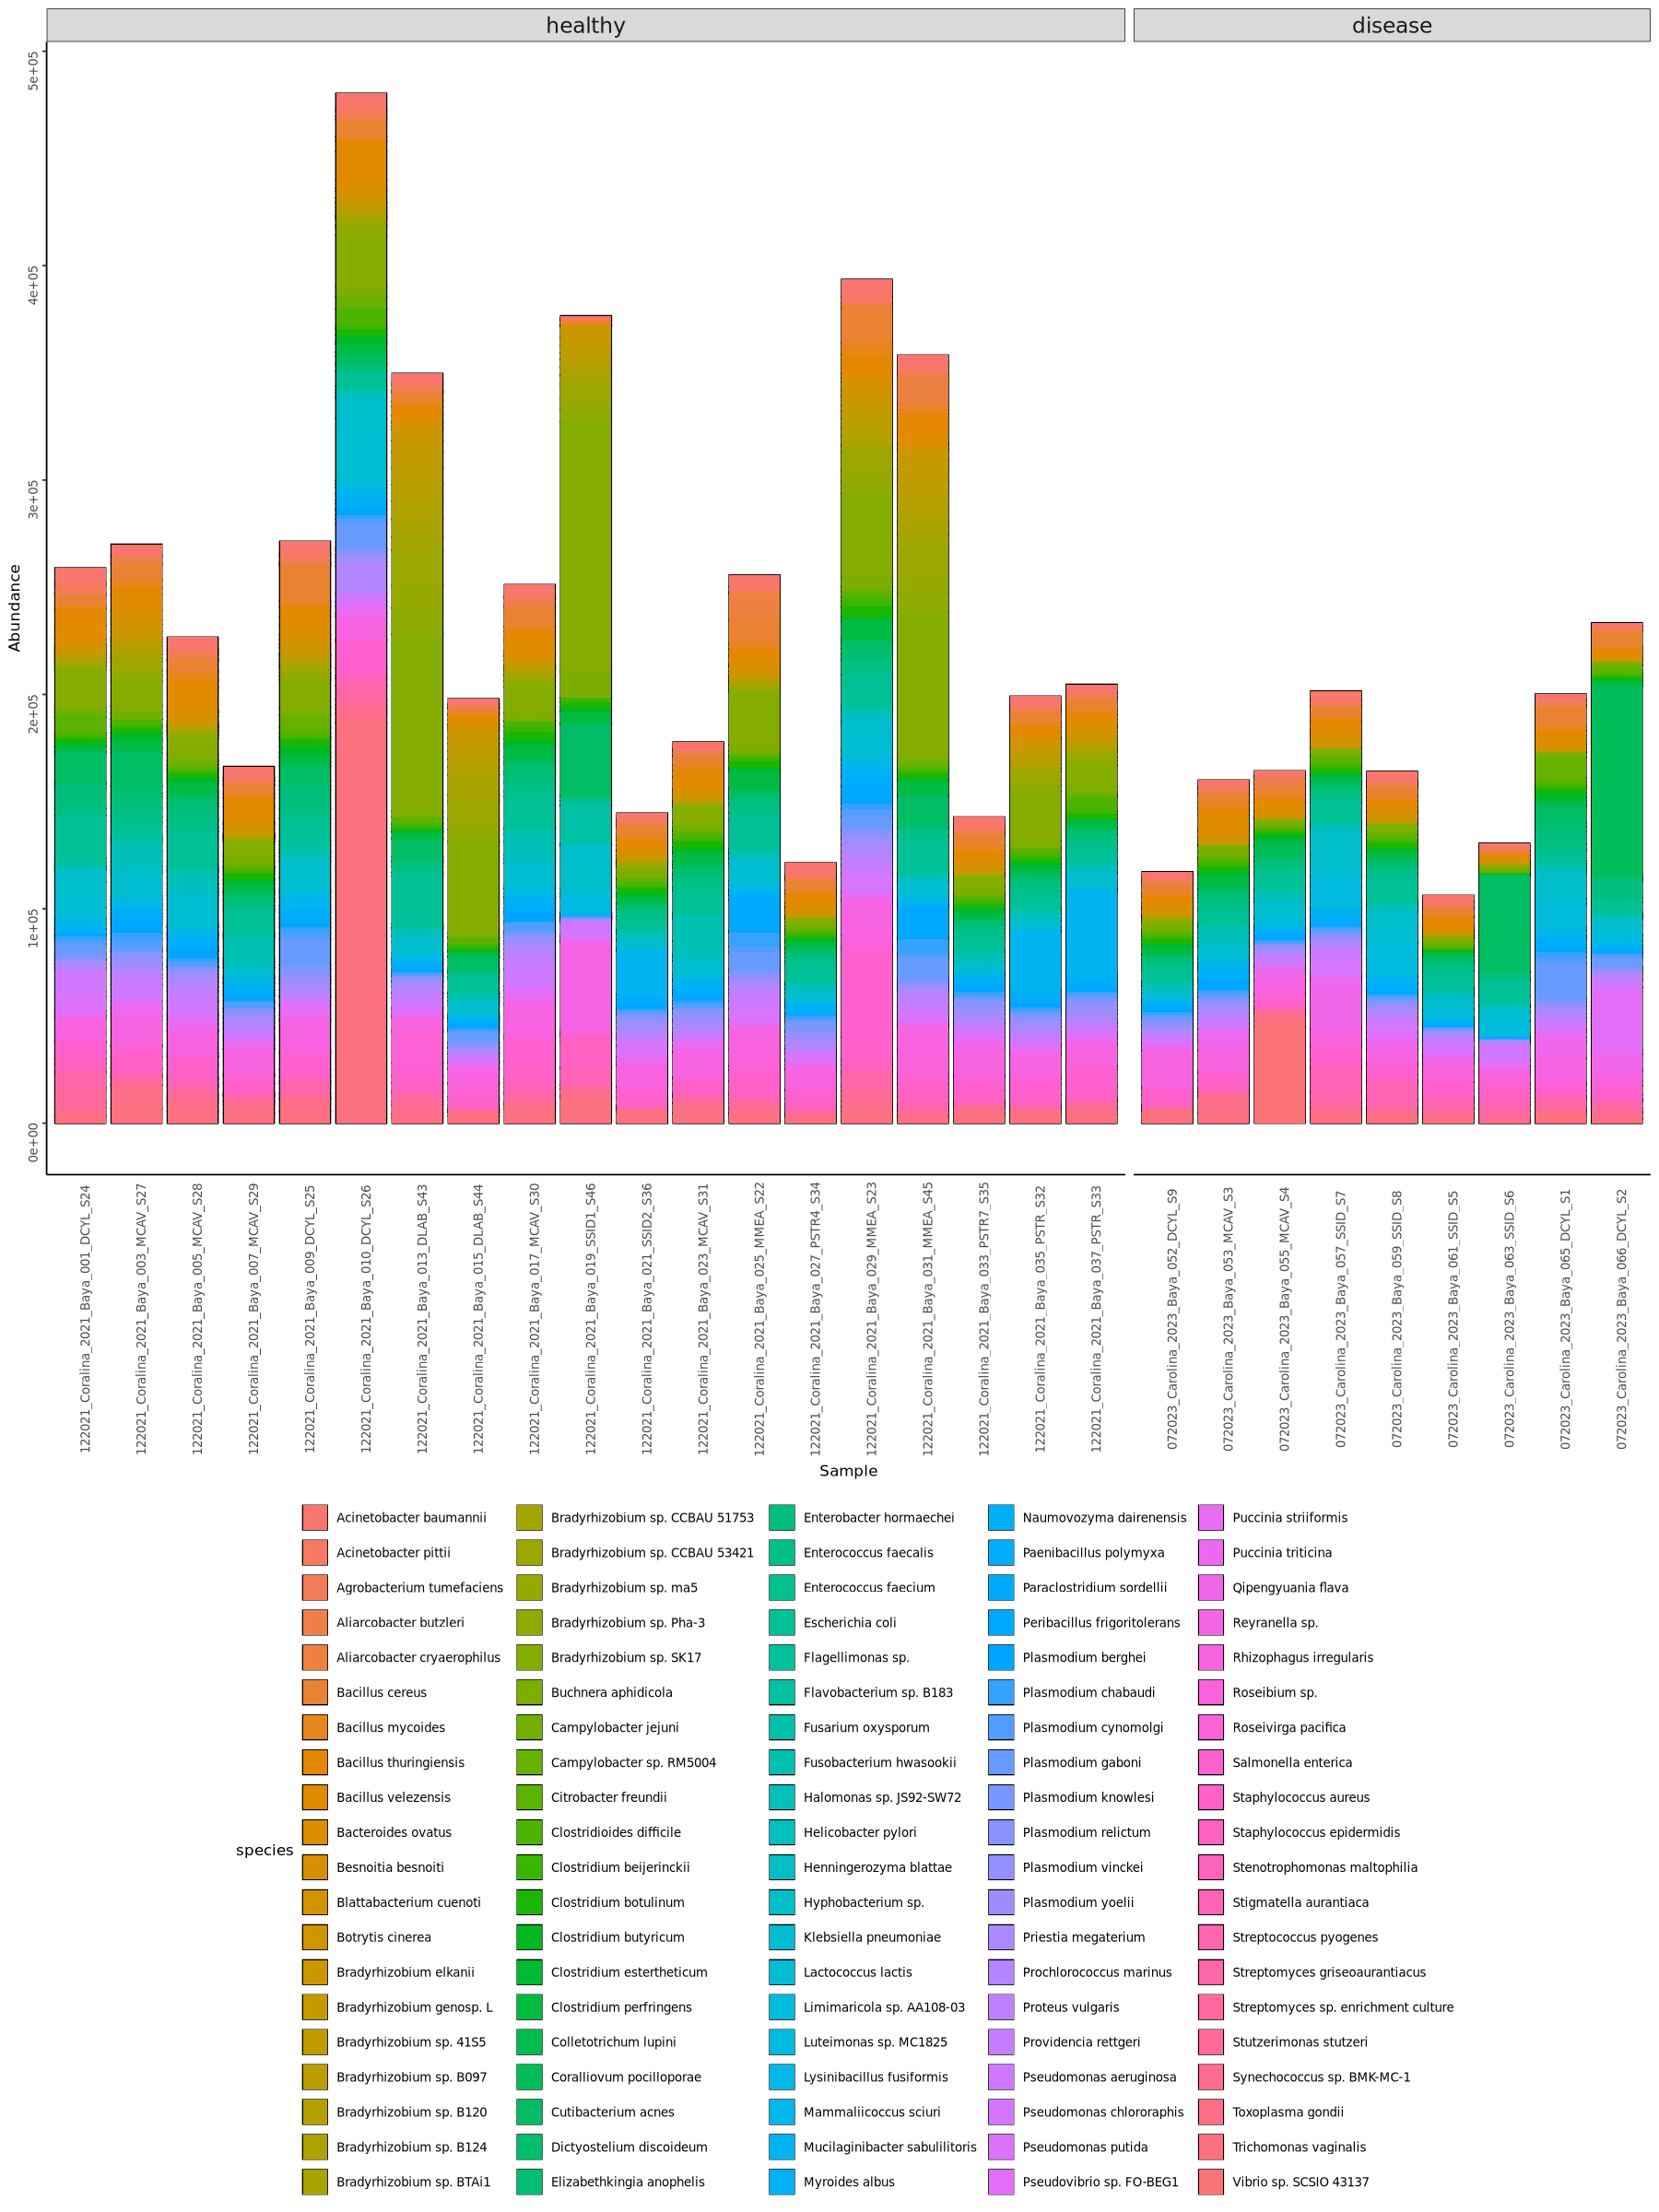

In [32]:
#taxa plot
all_100_bar<-plot_bar(DR_all,fill='species')+
facet_grid(~Status_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
#scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(), 
          panel.grid.minor.y = element_blank(),
          strip.text = element_text(size = 14), 
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=10))
all_100_bar


In [33]:
ggsave(filename = "all_species_tax_100.png", plot = all_100_bar, 
      width = 15,
      height = 20,
      units = "in",
      dpi = 300)

In [31]:
DR_all_100_rel <- transform_sample_counts(DR_all, function(x) x / sum(x))

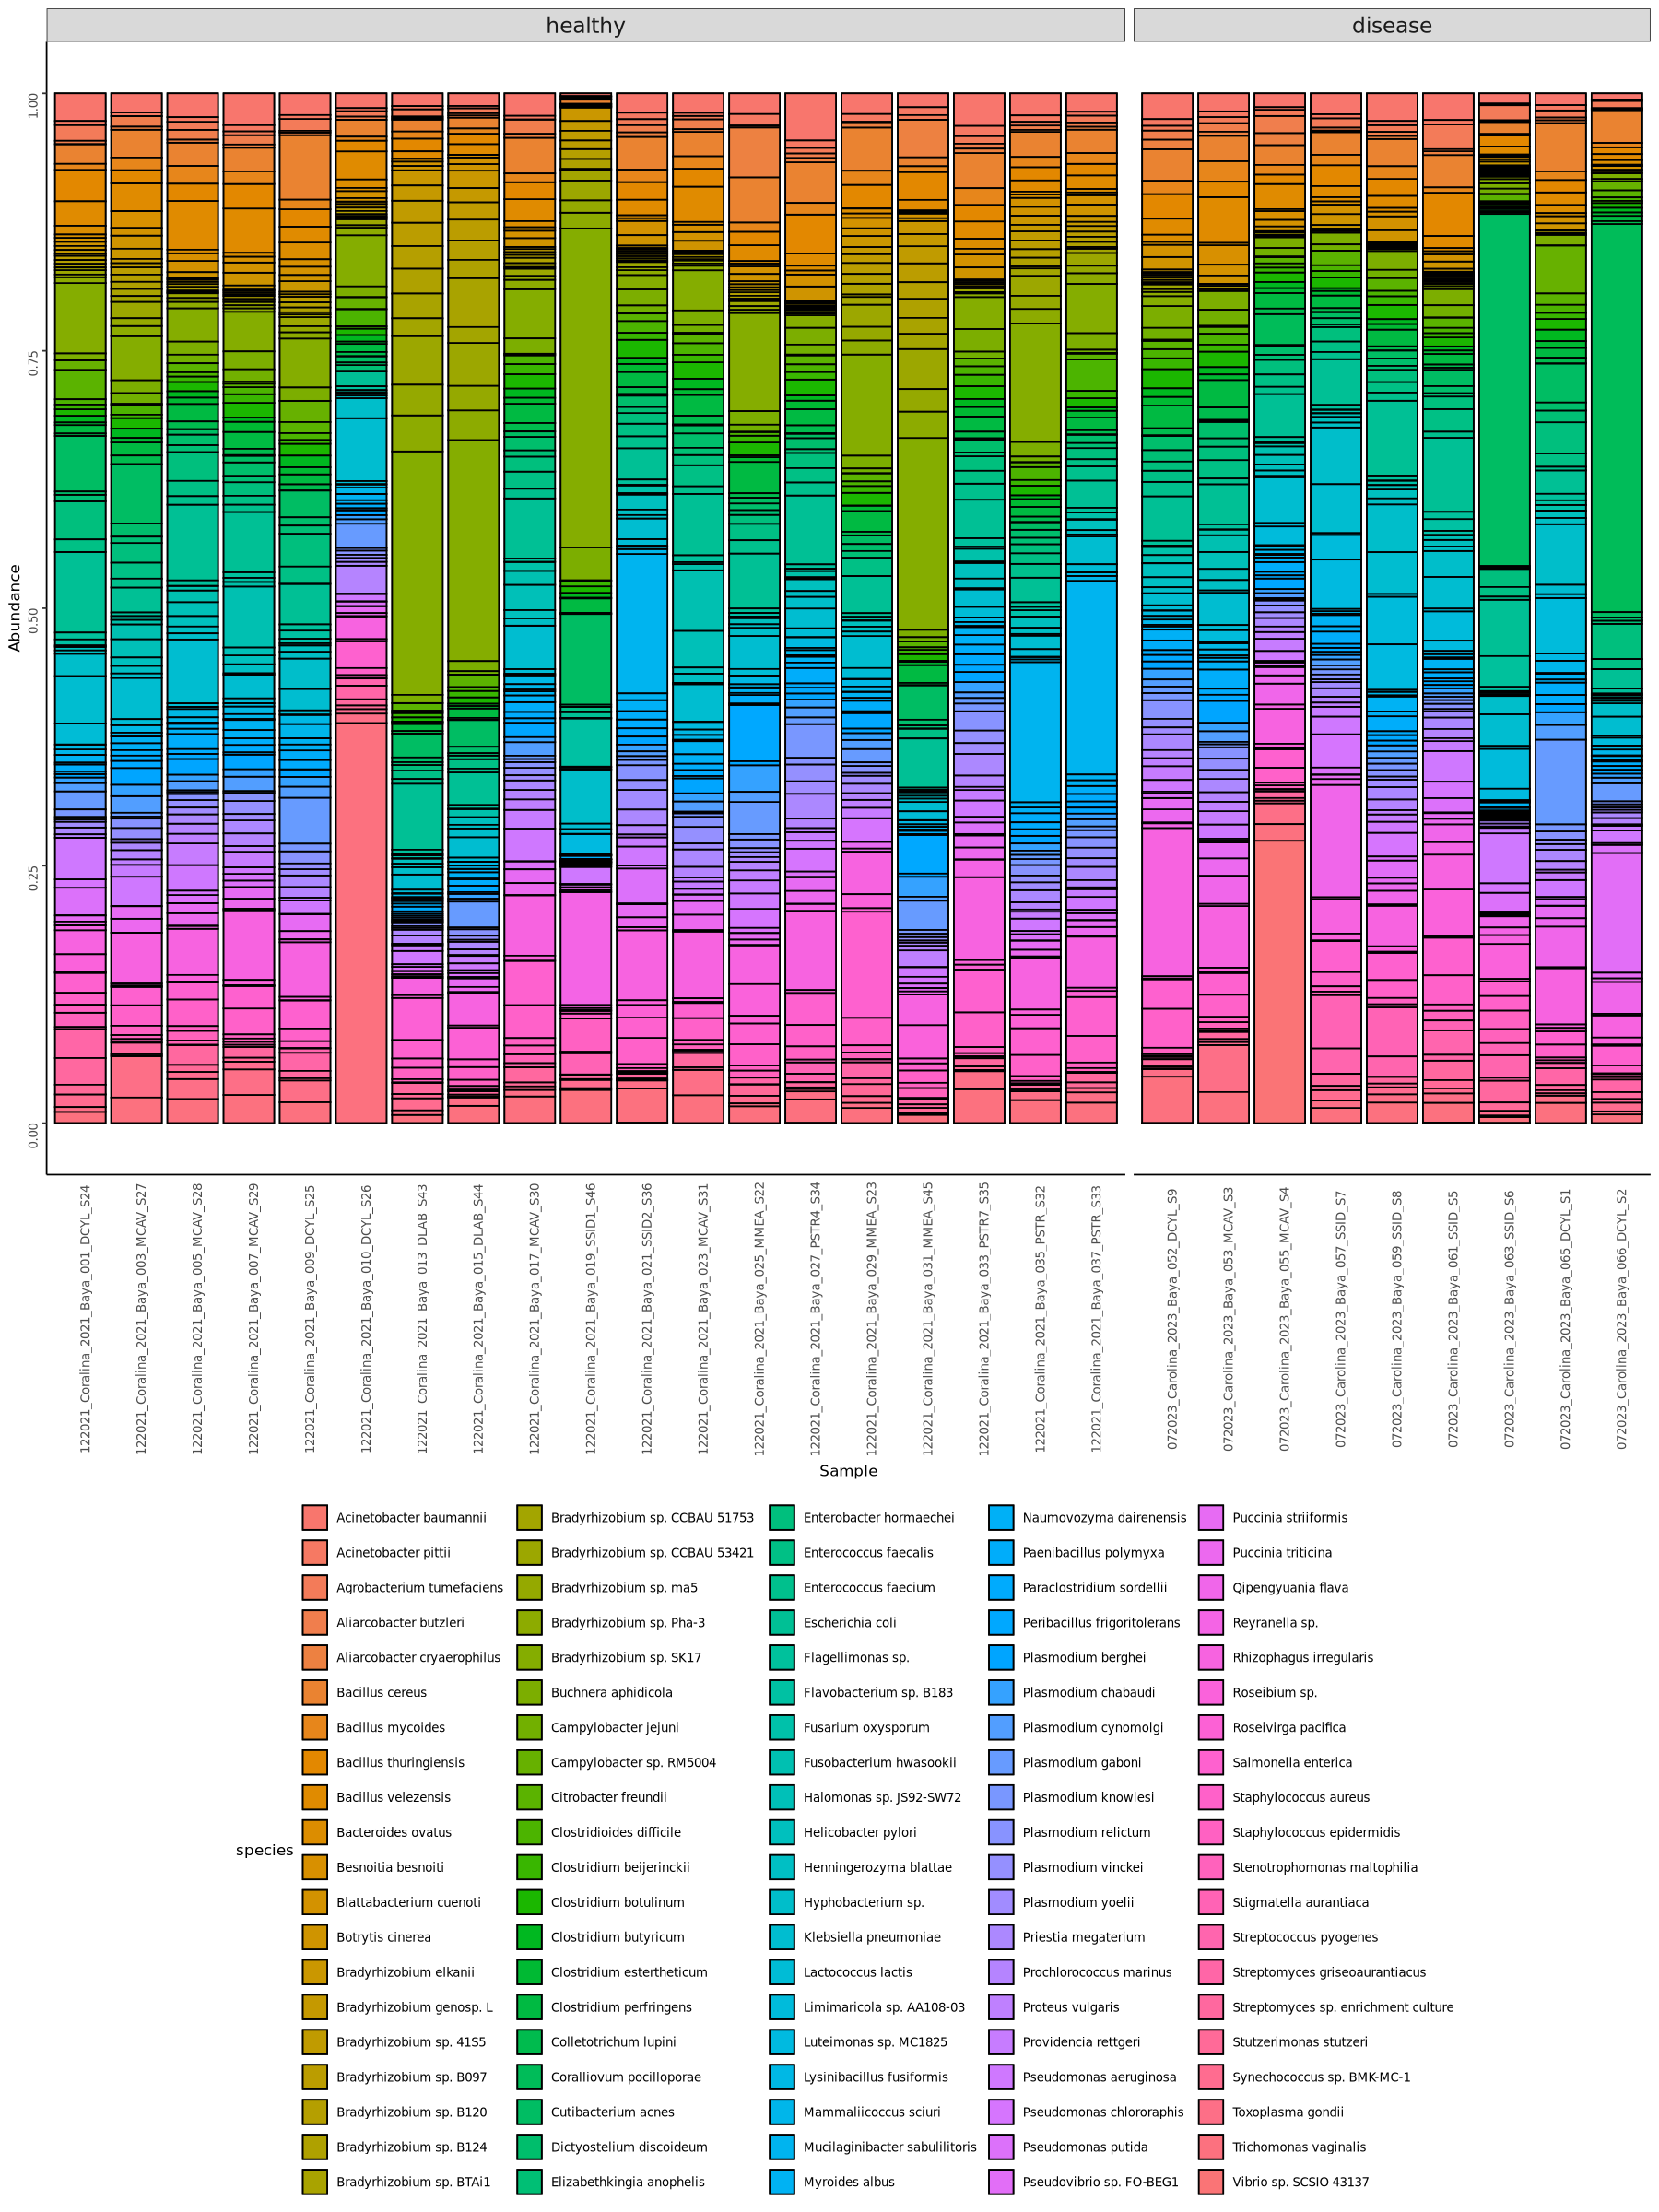

In [36]:
#taxa plot
all_100_rel_bar<-plot_bar(DR_all_100_rel,fill='species')+
facet_grid(~Status_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack", color="black")+
#scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(), 
          panel.grid.minor.y = element_blank(),
          strip.text = element_text(size = 14), 
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=10))
all_100_rel_bar

In [37]:
ggsave(filename = "all_species_tax_rel_100.png", plot = all_100_rel_bar, 
      width = 15,
      height = 20,
      units = "in",
      dpi = 300)

### MCAV

In [43]:
# pull out just mcavs from phyloseq object
DR_mcav <- subset_samples(DR_all, Species == "MCAV")
DR_mcav

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 12739 taxa and 7 samples ]
sample_data() Sample Data:       [ 7 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 12739 taxa by 1 taxonomic ranks ]

In [55]:
DR_mcav_12 = prune_taxa(names(sort(taxa_sums(DR_mcav),TRUE)[1:12]), DR_mcav)

In [56]:
sample_data(DR_mcav_12)$Status_m <- factor(sample_data(DR_mcav_12)$SCTLD_status, 
                                      levels = c("healthy", "disease"))

In [76]:
options(repr.plot.width=10, repr.plot.height=10)

In [50]:
install.packages("paletteer")
library(paletteer)

also installing the dependency ‘prismatic’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [54]:
#colors <- colorRampPalette(brewer.pal(15, "Set3"))

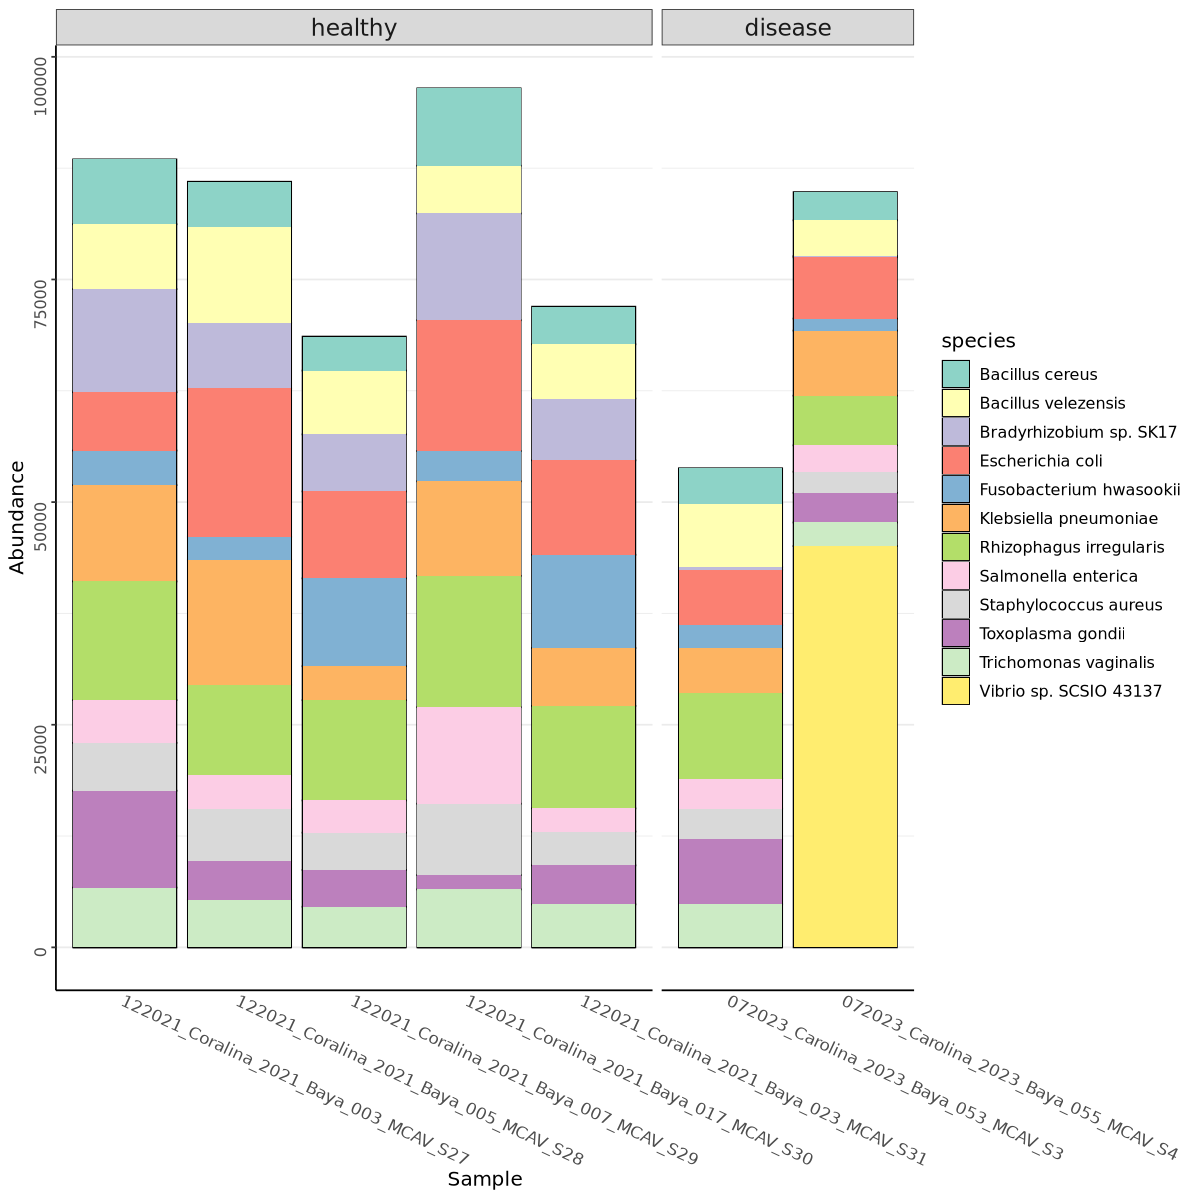

In [83]:
# bar plot of top 10 abundant taxa in MCAV samples
mcav_12_bar<-plot_bar(DR_mcav_12,fill='species')+
facet_grid(~Status_m, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Set3") +
theme_bw()+
theme(legend.position="right", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.text.x = element_text(angle = -25, hjust = 0, vjust = 1, size = 10),  # Adjust text size
          strip.text = element_text(size = 14),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=12))
mcav_12_bar

In [84]:
ggsave(filename = "DR_mcav_top_12_species_bar.png", plot = mcav_12_bar, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

In [63]:
DR_mcav_12_rel <- transform_sample_counts(DR_mcav_12, function(x) x / sum(x))

In [64]:
sample_data(DR_mcav_12_rel)$Status_mc <- factor(sample_data(DR_mcav_12_rel)$SCTLD_status, 
                                      levels = c("healthy", "disease"))

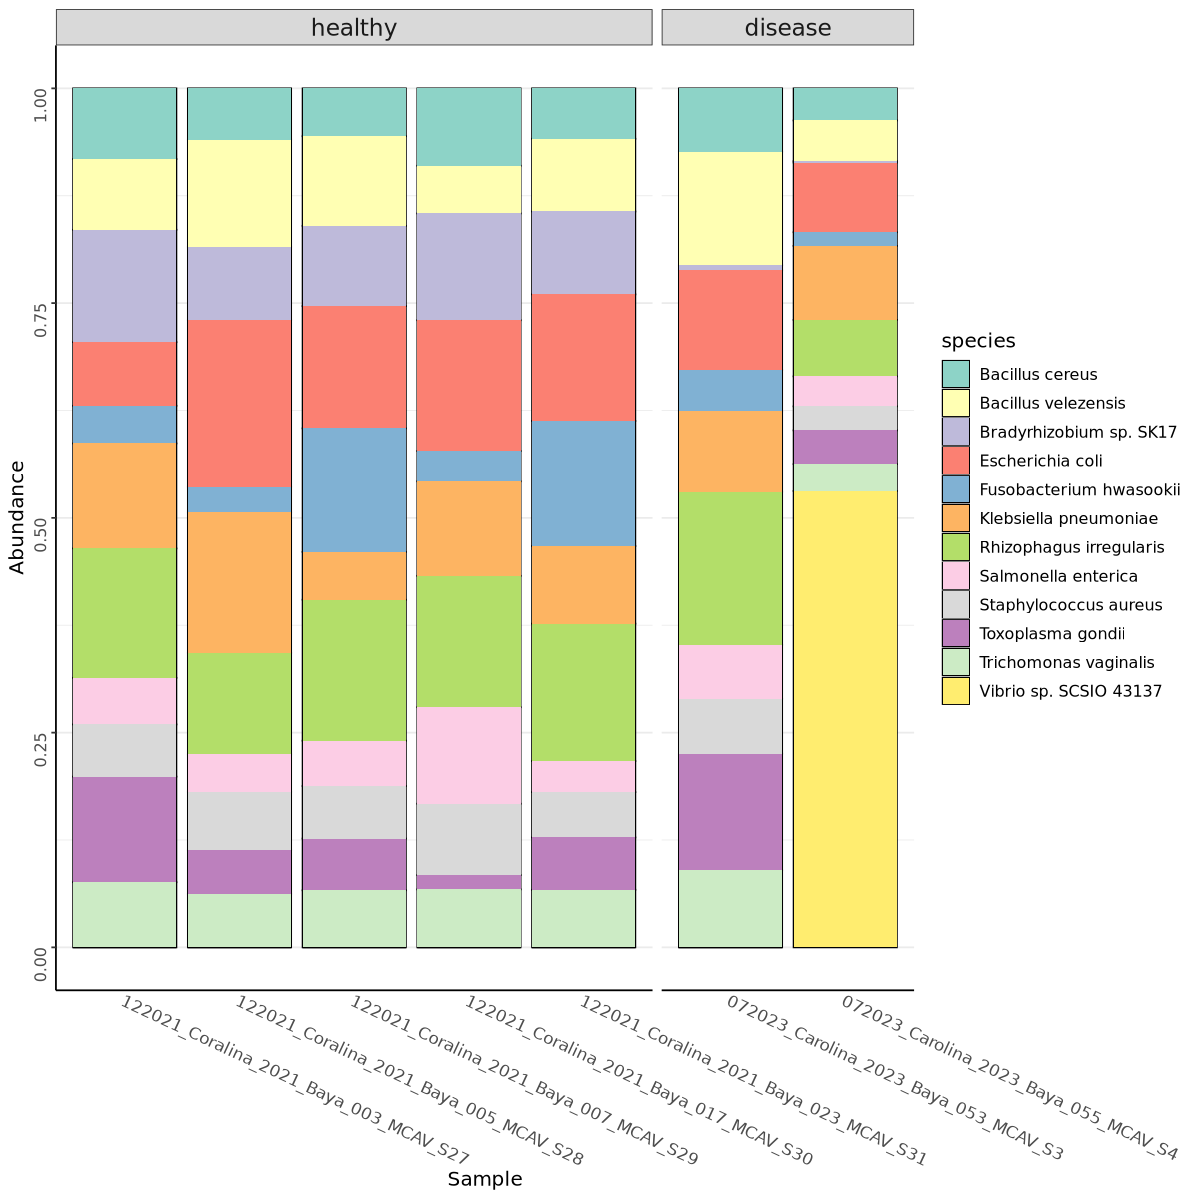

In [80]:
# bar plot of top 10 abundant taxa in MCAV samples
mcav_12_rel_bar<-plot_bar(DR_mcav_12_rel,fill='species')+
facet_grid(~Status_mc, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Set3") +
theme_bw()+
theme(legend.position="right", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.text.x = element_text(angle = -25, hjust = 0, vjust = 1, size = 10),  # Adjust text size
          strip.text = element_text(size = 14),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=12))
mcav_12_rel_bar

In [81]:
ggsave(filename = "DR_mcav_top_12_species_rel_bar.png", plot = mcav_12_rel_bar, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

In [70]:
#run DESeq2 on mcav (on H vs DM sample types)
ds_mcav = phyloseq_to_deseq2(DR_mcav, ~ Sample_type)
ds_mcav = DESeq(ds_mcav, test="Wald", fitType="parametric")
res = results(ds_mcav, cooksCutoff = FALSE, contrast=c("Sample_type", "H", "DM"))
alpha = 0.0001
sigtab = res[which(res$padj < alpha), ]
sigtab_mcav = cbind(as(sigtab, "data.frame"), as(tax_table(DR_mcav)[rownames(sigtab), ], "matrix"))
res
head(sigtab_mcav)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing



log2 fold change (MLE): Sample_type H vs DM 
Wald test p-value: Sample type H vs DM 
DataFrame with 12739 rows and 6 columns
         baseMean log2FoldChange     lfcSE      stat      pvalue        padj
        <numeric>      <numeric> <numeric> <numeric>   <numeric>   <numeric>
2057741   5521.71       4.909128  0.346981 14.148129 1.91792e-45 1.57845e-42
5722      4877.83       0.122266  0.310024  0.394375 6.93304e-01 1.00000e+00
562      10097.07      -0.159130  0.619312 -0.256947 7.97220e-01 1.00000e+00
588596   10542.47       0.191120  0.371749  0.514111 6.07175e-01 1.00000e+00
573       8128.75      -0.665715  0.609303 -1.092585 2.74576e-01 5.88698e-01
...           ...            ...       ...       ...         ...         ...
2845680         0             NA        NA        NA          NA          NA
1923622         0             NA        NA        NA          NA          NA
3048237         0             NA        NA        NA          NA          NA
3060633         0           

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2057741,5521.7070,4.909128,0.3469808,14.148129,1.917924e-45,1.578451e-42,Bradyrhizobium sp. SK17
208375,901.5603,11.978913,2.1530360,5.563731,2.640669e-08,7.244235e-06,Bradyrhizobium sp. Pha-3
192812,1482.1043,-15.094472,1.0489798,-14.389668,6.008344e-47,5.769011e-44,Qipengyuania flava
3021011,10945.4919,-18.840242,1.0153912,-18.554664,7.477373e-77,4.307714e-73,Vibrio sp. SCSIO 43137
3425945,1004.9246,-14.933321,1.1114638,-13.435725,3.733950e-41,2.688910e-38,Limimaricola sp. AA108-03
2653203,749.9401,-14.237852,1.2010654,-11.854352,2.042975e-32,8.406844e-30,Sphingomonas sp. CL5.1


In [71]:
# sort by most significant 
sorted_sigtab <- sigtab_mcav %>%
  arrange(padj)
head(sorted_sigtab)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
3021011,10945.492,-18.84024,1.015391,-18.55466,7.477373e-77,4.307714e-73,Vibrio sp. SCSIO 43137
3003349,2219.084,-16.48656,1.014998,-16.24294,2.505994e-59,7.218517e-56,Marinobacter sp. LM1
2743,2105.491,-16.46214,1.019212,-16.15182,1.102604e-58,2.117366e-55,Marinobacter nauticus
2829569,1506.976,-15.97963,1.048489,-15.24064,1.900089e-52,2.736603e-49,Bacterioplanoides sp. SCSIO 12839
2961520,1219.863,-15.67470,1.077036,-14.55355,5.545293e-48,6.389287e-45,Arcobacter roscoffensis
192812,1482.104,-15.09447,1.048980,-14.38967,6.008344e-47,5.769011e-44,Qipengyuania flava


In [72]:
#include just the top 20 for now
sorted_sigtab20 <- head(sorted_sigtab, 20)
sorted_sigtab20

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
3021011,10945.4919,-18.840242,1.0153912,-18.554664,7.477373e-77,4.307714e-73,Vibrio sp. SCSIO 43137
3003349,2219.0845,-16.486564,1.0149984,-16.242945,2.505994e-59,7.218517e-56,Marinobacter sp. LM1
2743,2105.4909,-16.462136,1.0192125,-16.151820,1.102604e-58,2.117366e-55,Marinobacter nauticus
2829569,1506.9757,-15.979634,1.0484886,-15.240637,1.900089e-52,2.736603e-49,Bacterioplanoides sp. SCSIO 12839
2961520,1219.8633,-15.674696,1.0770362,-14.553545,5.545293e-48,6.389287e-45,Arcobacter roscoffensis
192812,1482.1043,-15.094472,1.0489798,-14.389668,6.008344e-47,5.769011e-44,Qipengyuania flava
2057741,5521.7070,4.909128,0.3469808,14.148129,1.917924e-45,1.578451e-42,Bradyrhizobium sp. SK17
3425945,1004.9246,-14.933321,1.1114638,-13.435725,3.733950e-41,2.688910e-38,Limimaricola sp. AA108-03
1775881,1005.4446,-14.705958,1.1114011,-13.231909,5.741079e-40,3.674929e-37,Sulfitobacter faviae


In [85]:
write.csv(sorted_sigtab20, file="mcav_sorted_sigtab20.csv")

In [86]:
m_sorted_sigtab20 <- read.csv("mcav_sorted_sigtab20.csv")

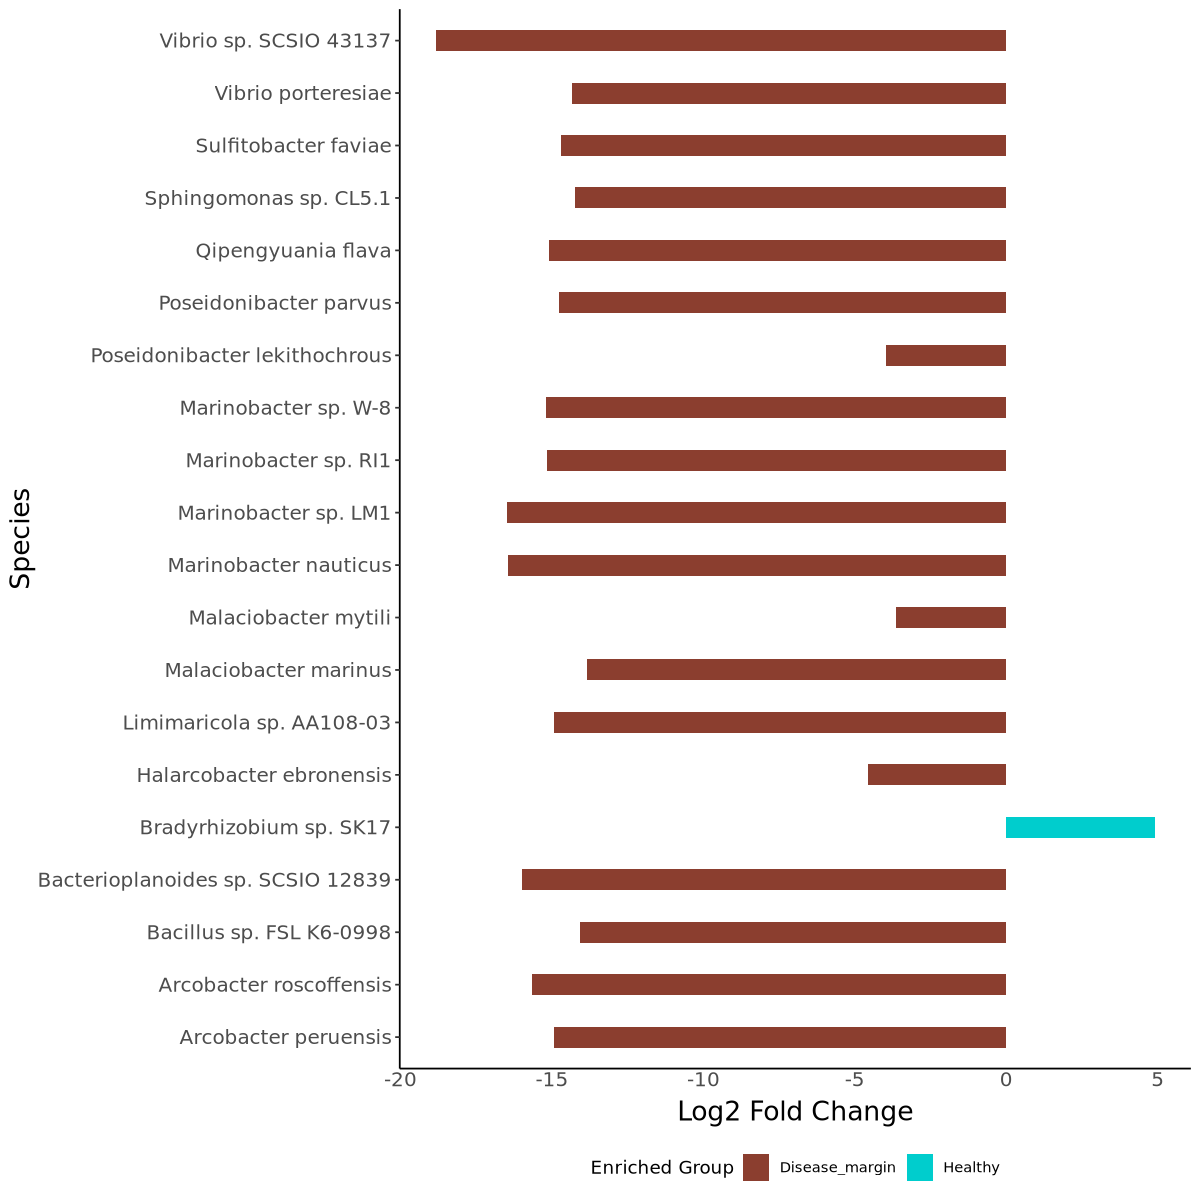

In [87]:
#plot significantly different OTUs top 20
m_sorted_sigtab20_plot <- ggplot(m_sorted_sigtab20, aes(x = species, y = log2FoldChange, fill = enriched)) +
  geom_bar(stat = "identity", width = 0.4) +
  coord_flip() + # Rotates the bars horizontally
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(),
          panel.grid.minor.y = element_blank(),
          axis.text.x = element_text(size = 12),
          axis.text.y = element_text(size = 12),  # Adjust y-axis text size
          axis.title.x = element_text(size = 16, margin = margin(t = 5)),  # Adjust x-axis title size and margin
          axis.title.y = element_text(size = 16),   # Adjust y-axis title size and add margin
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"))+
  labs(x = "Species", y = "Log2 Fold Change", fill = "Enriched Group") +
scale_fill_manual(values= c("Healthy"="cyan3", "Disease_margin"="coral4"))

m_sorted_sigtab20_plot

In [88]:
ggsave(filename = "DR_mcav_lfc_HvDM.png", plot = m_sorted_sigtab20_plot, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

In [71]:
#include just the top 30 for now
sorted_sigtab30 <- head(sorted_sigtab, 30)
sorted_sigtab30

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
3021011,10945.4919,-18.840242,1.0153912,-18.554664,7.477373e-77,4.307714e-73,Vibrio sp. SCSIO 43137
3003349,2219.0845,-16.486564,1.0149984,-16.242945,2.505994e-59,7.218517e-56,Marinobacter sp. LM1
2743,2105.4909,-16.462136,1.0192125,-16.151820,1.102604e-58,2.117366e-55,Marinobacter nauticus
2829569,1506.9757,-15.979634,1.0484886,-15.240637,1.900089e-52,2.736603e-49,Bacterioplanoides sp. SCSIO 12839
2961520,1219.8633,-15.674696,1.0770362,-14.553545,5.545293e-48,6.389287e-45,Arcobacter roscoffensis
192812,1482.1043,-15.094472,1.0489798,-14.389668,6.008344e-47,5.769011e-44,Qipengyuania flava
2057741,5521.7070,4.909128,0.3469808,14.148129,1.917924e-45,1.578451e-42,Bradyrhizobium sp. SK17
3425945,1004.9246,-14.933321,1.1114638,-13.435725,3.733950e-41,2.688910e-38,Limimaricola sp. AA108-03
1775881,1005.4446,-14.705958,1.1114011,-13.231909,5.741079e-40,3.674929e-37,Sulfitobacter faviae


In [72]:
# subset taxa that are assoc with healthy
healthy_mcav_otu<-sorted_sigtab[sorted_sigtab$log2FoldChange>0,]
healthy_mcav_otu

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2057741,5521.7070,4.909128,0.3469808,14.148129,1.917924e-45,1.578451e-42,Bradyrhizobium sp. SK17
208375,901.5603,11.978913,2.1530360,5.563731,2.640669e-08,7.244235e-06,Bradyrhizobium sp. Pha-3


In [73]:
# subset taxa that are assoc with disease margin
disease_mcav_otu<-sorted_sigtab[sorted_sigtab$log2FoldChange<0,]
disease_mcav_otu

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
3021011,10945.4919,-18.840242,1.0153912,-18.554664,7.477373e-77,4.307714e-73,Vibrio sp. SCSIO 43137
3003349,2219.0845,-16.486564,1.0149984,-16.242945,2.505994e-59,7.218517e-56,Marinobacter sp. LM1
2743,2105.4909,-16.462136,1.0192125,-16.151820,1.102604e-58,2.117366e-55,Marinobacter nauticus
2829569,1506.9757,-15.979634,1.0484886,-15.240637,1.900089e-52,2.736603e-49,Bacterioplanoides sp. SCSIO 12839
2961520,1219.8633,-15.674696,1.0770362,-14.553545,5.545293e-48,6.389287e-45,Arcobacter roscoffensis
192812,1482.1043,-15.094472,1.0489798,-14.389668,6.008344e-47,5.769011e-44,Qipengyuania flava
3425945,1004.9246,-14.933321,1.1114638,-13.435725,3.733950e-41,2.688910e-38,Limimaricola sp. AA108-03
1775881,1005.4446,-14.705958,1.1114011,-13.231909,5.741079e-40,3.674929e-37,Sulfitobacter faviae
3369658,873.9682,-15.193623,1.1518426,-13.190712,9.924363e-40,5.717426e-37,Marinobacter sp. W-8


In [91]:
#run DESeq2 on mcav on disease status
ds_mcav_d = phyloseq_to_deseq2(DR_mcav, ~ SCTLD_status)
ds_mcav_d = DESeq(ds_mcav_d, test="Wald", fitType="parametric")
res_mcav_d = results(ds_mcav_d, cooksCutoff = FALSE, contrast=c("SCTLD_status", "healthy", "disease"))
alpha = 0.0001
sigtab_mcav_d = res_mcav_d[which(res_mcav_d$padj < alpha), ]
sigtab_mcav_d = cbind(as(sigtab_mcav_d, "data.frame"), as(tax_table(DR_mcav)[rownames(sigtab_mcav_d), ], "matrix"))
res_mcav_d
head(sigtab_mcav_d)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing



log2 fold change (MLE): SCTLD_status healthy vs disease 
Wald test p-value: SCTLD status healthy vs disease 
DataFrame with 12739 rows and 6 columns
         baseMean log2FoldChange     lfcSE       stat      pvalue        padj
        <numeric>      <numeric> <numeric>  <numeric>   <numeric>   <numeric>
2057741   5521.71      4.6817574  0.330591 14.1617929 1.57913e-45 4.42394e-42
5722      4877.83      0.0256975  0.297225  0.0864583 9.31102e-01 9.99681e-01
562      10097.07      0.1940807  0.503240  0.3856626 6.99747e-01 9.99681e-01
588596   10542.47      0.1387932  0.406541  0.3414003 7.32802e-01 9.99681e-01
573       8128.75     -0.1808853  0.485509 -0.3725688 7.09469e-01 9.99681e-01
...           ...            ...       ...        ...         ...         ...
2845680         0             NA        NA         NA          NA          NA
1923622         0             NA        NA         NA          NA          NA
3048237         0             NA        NA         NA          NA      

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2057741,5521.7070,4.681757,0.3305907,14.161793,1.579133e-45,4.423940e-42,Bradyrhizobium sp. SK17
208375,901.5603,12.318716,1.5495428,7.949904,1.866567e-15,5.394294e-13,Bradyrhizobium sp. Pha-3
192812,1482.1043,-14.955560,1.0069968,-14.851647,6.788073e-50,3.803357e-46,Qipengyuania flava
3344828,546.0641,11.595288,1.6320360,7.104799,1.204978e-12,7.760334e-11,Bradyrhizobium sp. ma5
3021011,10945.4919,-30.000000,3.9244716,-7.644341,2.100177e-14,1.838639e-12,Vibrio sp. SCSIO 43137
3425945,1004.9246,-14.394915,2.7120736,-5.307716,1.110076e-07,1.615521e-06,Limimaricola sp. AA108-03


In [92]:
# sort by most significant 
sorted_sigtab_d <- sigtab_mcav_d %>%
  arrange(padj)
head(sorted_sigtab_d)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
192812,1482.1043,-14.955560,1.0069968,-14.851647,6.788073e-50,3.803357e-46,Qipengyuania flava
2057741,5521.7070,4.681757,0.3305907,14.161793,1.579133e-45,4.423940e-42,Bradyrhizobium sp. SK17
1775881,1005.4446,-14.395657,1.0572063,-13.616696,3.186600e-42,5.951507e-39,Sulfitobacter faviae
2653203,749.9401,-13.972700,1.1096256,-12.592265,2.328927e-36,3.262245e-33,Sphingomonas sp. CL5.1
2819104,234.1593,-26.853745,2.7204000,-9.871249,5.546977e-23,6.215942e-20,Vibrio sp. SCSIO 43097
2912314,227.1151,-26.804985,2.7825726,-9.633167,5.791665e-22,5.408450e-19,Vibrio sp. JC009


In [97]:
#include just the top 20 all for now
sorted_sigtab20_d <- head(sorted_sigtab_d, 20)
sorted_sigtab20_d

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
192812,1482.10428,-14.955560,1.0069968,-14.851647,6.788073e-50,3.803357e-46,Qipengyuania flava
2057741,5521.70695,4.681757,0.3305907,14.161793,1.579133e-45,4.423940e-42,Bradyrhizobium sp. SK17
1775881,1005.44459,-14.395657,1.0572063,-13.616696,3.186600e-42,5.951507e-39,Sulfitobacter faviae
2653203,749.94007,-13.972700,1.1096256,-12.592265,2.328927e-36,3.262245e-33,Sphingomonas sp. CL5.1
2819104,234.15934,-26.853745,2.7204000,-9.871249,5.546977e-23,6.215942e-20,Vibrio sp. SCSIO 43097
2912314,227.11513,-26.804985,2.7825726,-9.633167,5.791665e-22,5.408450e-19,Vibrio sp. JC009
2906515,213.02671,-26.719798,2.9207962,-9.148121,5.793222e-20,4.637060e-17,Arcobacter iocasae
3096994,204.28217,-26.666920,3.0157569,-8.842530,9.357546e-19,6.553791e-16,Thalassobius sp. MITS945101
208375,901.56026,12.318716,1.5495428,7.949904,1.866567e-15,5.394294e-13,Bradyrhizobium sp. Pha-3


In [99]:
write.csv(sorted_sigtab20_d, file="mcav_top_20_lfc_HvD_status.csv")

In [100]:
sorted_sigtab20_d <- read.csv("mcav_top_20_lfc_HvD_status.csv")

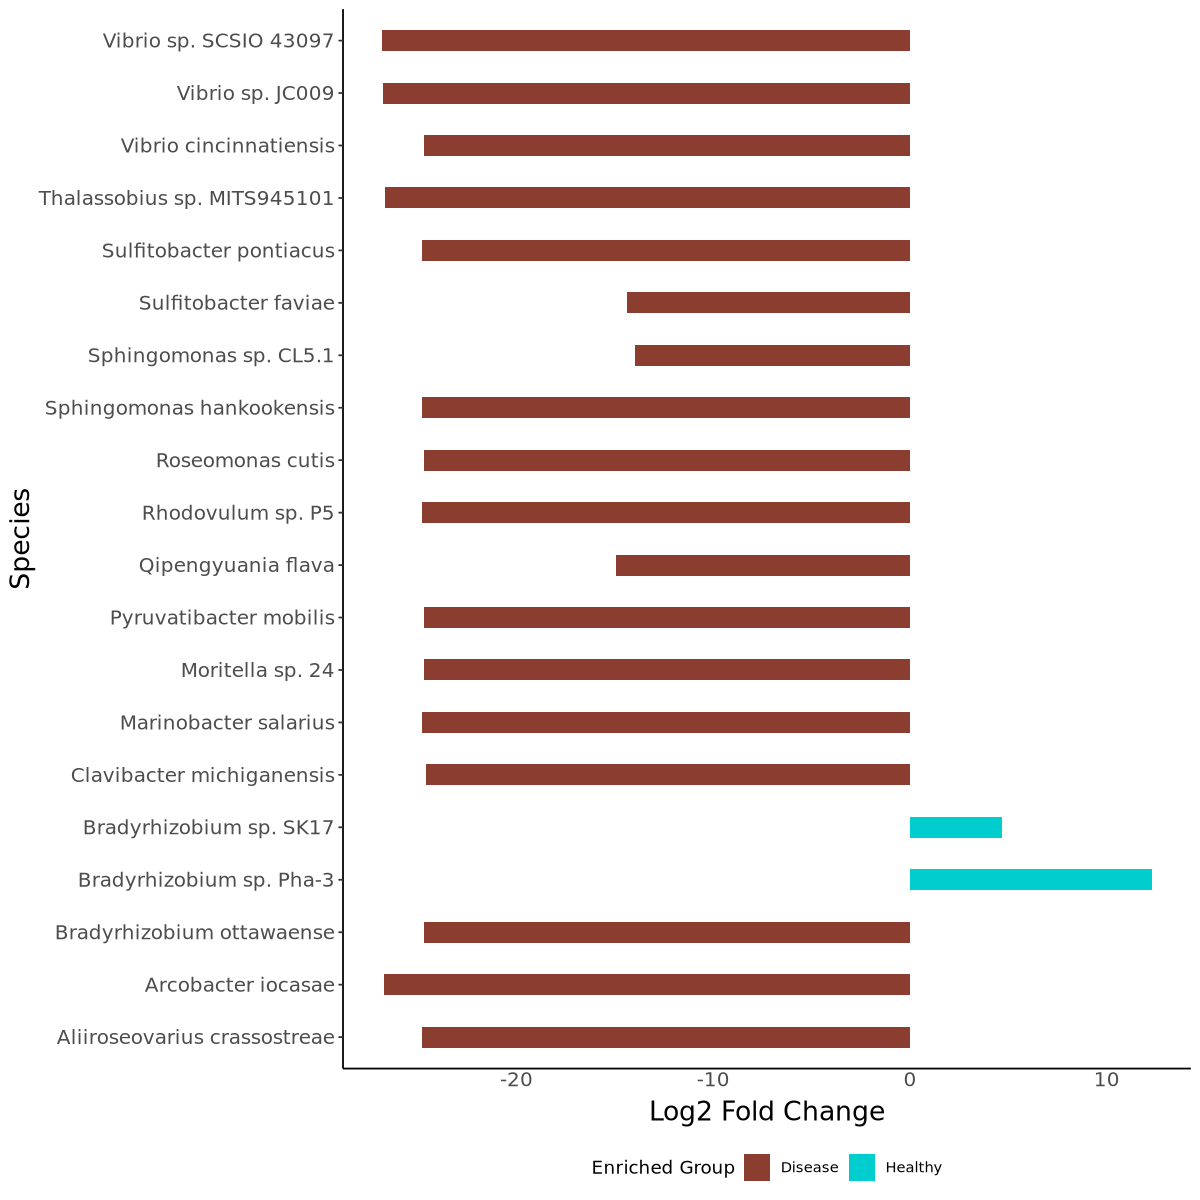

In [101]:
#plot significantly different OTUs top 20 Healthy v Disease
sorted_sigtab20_d_plot <- ggplot(sorted_sigtab20_d, aes(x = species, y = log2FoldChange, fill = enriched)) +
  geom_bar(stat = "identity", width = 0.4) +
  coord_flip() + # Rotates the bars horizontally
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(),
          panel.grid.minor.y = element_blank(),
          axis.text.x = element_text(size = 12),
          axis.text.y = element_text(size = 12),  # Adjust y-axis text size
          axis.title.x = element_text(size = 16, margin = margin(t = 5)),  # Adjust x-axis title size and margin
          axis.title.y = element_text(size = 16),   # Adjust y-axis title size and add margin
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"))+
  labs(x = "Species", y = "Log2 Fold Change", fill = "Enriched Group") +
scale_fill_manual(values= c("Healthy"="cyan3", "Disease"="coral4"))

sorted_sigtab20_d_plot

In [102]:
ggsave(filename = "DR_mcav_lfc_HvD_status.png", plot = sorted_sigtab20_d_plot, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

In [98]:
# subset taxa that are assoc with healthy
healthy_mcav_otu<-sorted_sigtab_d[sorted_sigtab_d$log2FoldChange>0,]
dim(healthy_mcav_otu)
#include just the top 20 h for now
healthy_mcav_otu <- head(healthy_mcav_otu, 20)
healthy_mcav_otu

[1] 568   7

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2057741,5521.70695,4.681757,0.3305907,14.161793,1.579133e-45,4.423940e-42,Bradyrhizobium sp. SK17
208375,901.56026,12.318716,1.5495428,7.949904,1.866567e-15,5.394294e-13,Bradyrhizobium sp. Pha-3
3344828,546.06410,11.595288,1.6320360,7.104799,1.204978e-12,7.760334e-11,Bradyrhizobium sp. ma5
1892404,225.77950,23.077941,3.2723855,7.052330,1.759468e-12,1.071554e-10,Bacillus sp. ABP14
2921604,223.33655,23.062028,3.3017313,6.984829,2.852033e-12,1.647417e-10,Paenibacillus sp. FSL L8-0638
1241978,215.74706,23.012247,3.3783550,6.811672,9.647072e-12,5.099297e-10,Chryseobacterium bernardetii
3410088,457.81579,11.340980,1.7005138,6.669149,2.572901e-11,1.264558e-09,Bradyrhizobium sp. B120
1675036,203.75534,22.929282,3.4723821,6.603329,4.020252e-11,1.877123e-09,Megasphaera hexanoica
712368,200.51960,22.912384,3.5011084,6.544323,5.976548e-11,2.744803e-09,Leptotrichia sp. oral taxon 498


In [103]:
write.csv(healthy_mcav_otu, file="mcav_top_20_lfc_healthy.csv")

In [106]:
healthy_mcav_otu <- read.csv("mcav_top_20_lfc_healthy.csv")

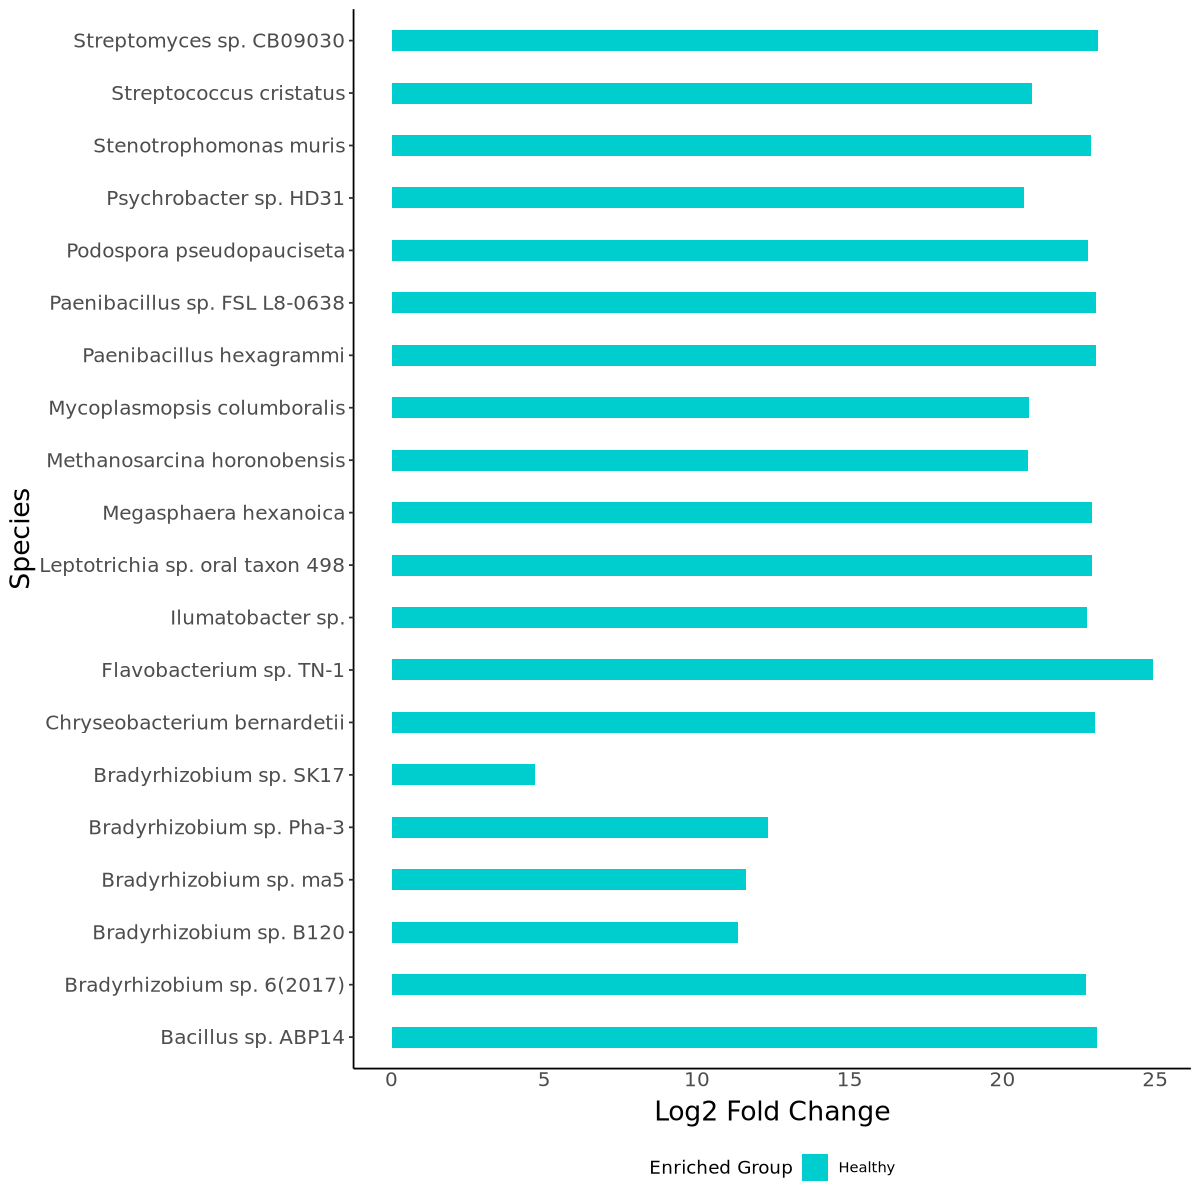

In [107]:
#plot top 20 healthy OTUs in Healthy v Disease
healthy_mcav_otu_plot <- ggplot(healthy_mcav_otu, aes(x = species, y = log2FoldChange, fill = enriched)) +
  geom_bar(stat = "identity", width = 0.4) +
  coord_flip() + # Rotates the bars horizontally
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(),
          panel.grid.minor.y = element_blank(),
          axis.text.x = element_text(size = 12),
          axis.text.y = element_text(size = 12),  # Adjust y-axis text size
          axis.title.x = element_text(size = 16, margin = margin(t = 5)),  # Adjust x-axis title size and margin
          axis.title.y = element_text(size = 16),   # Adjust y-axis title size and add margin
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"))+
  labs(x = "Species", y = "Log2 Fold Change", fill = "Enriched Group") +
scale_fill_manual(values= c("Healthy"="cyan3", "Disease"="coral4"))

healthy_mcav_otu_plot

In [108]:
ggsave(filename = "DR_mcav_lfc_H_top20_status.png", plot = healthy_mcav_otu_plot, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

### SSIDs

In [83]:
DR_ssid <- subset_samples(DR_all, Species == "SSID")
DR_ssid

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 100 taxa and 6 samples ]
sample_data() Sample Data:       [ 6 samples by 6 sample variables ]
tax_table()   Taxonomy Table:    [ 100 taxa by 1 taxonomic ranks ]

In [102]:
DR_ssid_10 = prune_taxa(names(sort(taxa_sums(DR_ssid),TRUE)[1:10]), DR_ssid)

In [103]:
sample_data(DR_ssid_10)$Type_o <- factor(sample_data(DR_ssid_10)$Sample_type, 
                                      levels = c("H", "DT", "DM"))

In [90]:
options(repr.plot.width=15, repr.plot.height=15)

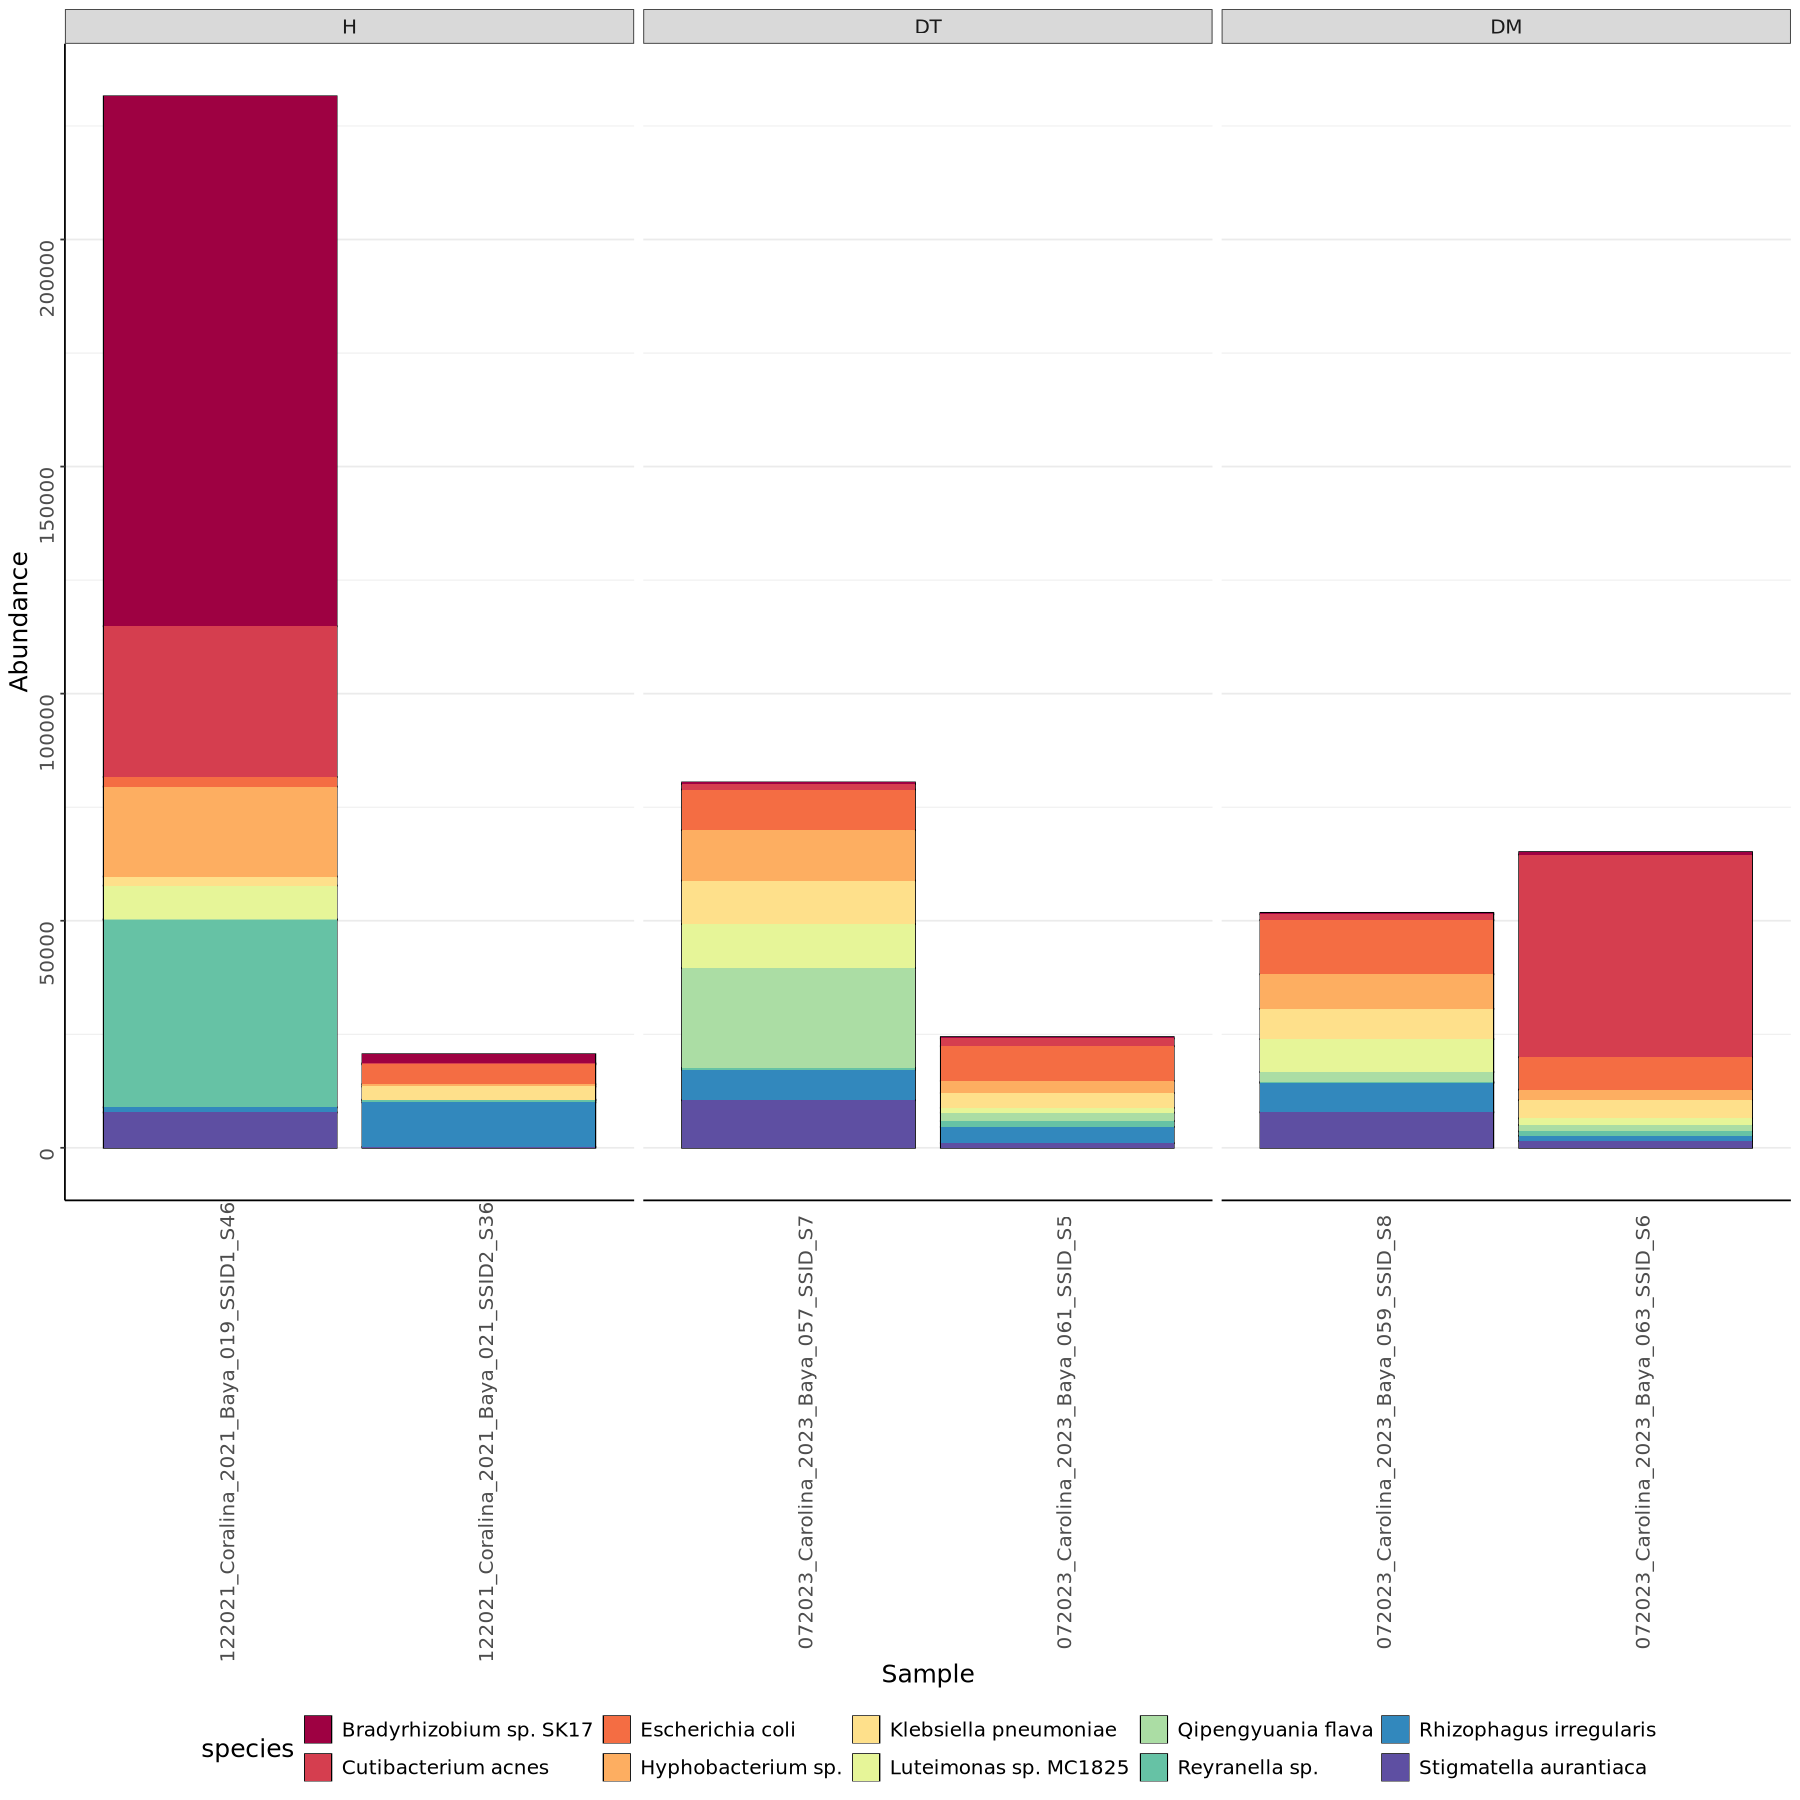

In [105]:
# bar plot of top 10 abundant taxa in ssid samples
ssid_10_bar<-plot_bar(DR_ssid_10,fill='species')+
facet_grid(~Type_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
ssid_10_bar

In [106]:
ggsave(filename = "DR_ssid_top_10_species_bar_samplet.png", plot = ssid_10_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 100)

In [107]:
DR_ssid_10_rel <- transform_sample_counts(DR_ssid_10, function(x) x / sum(x))

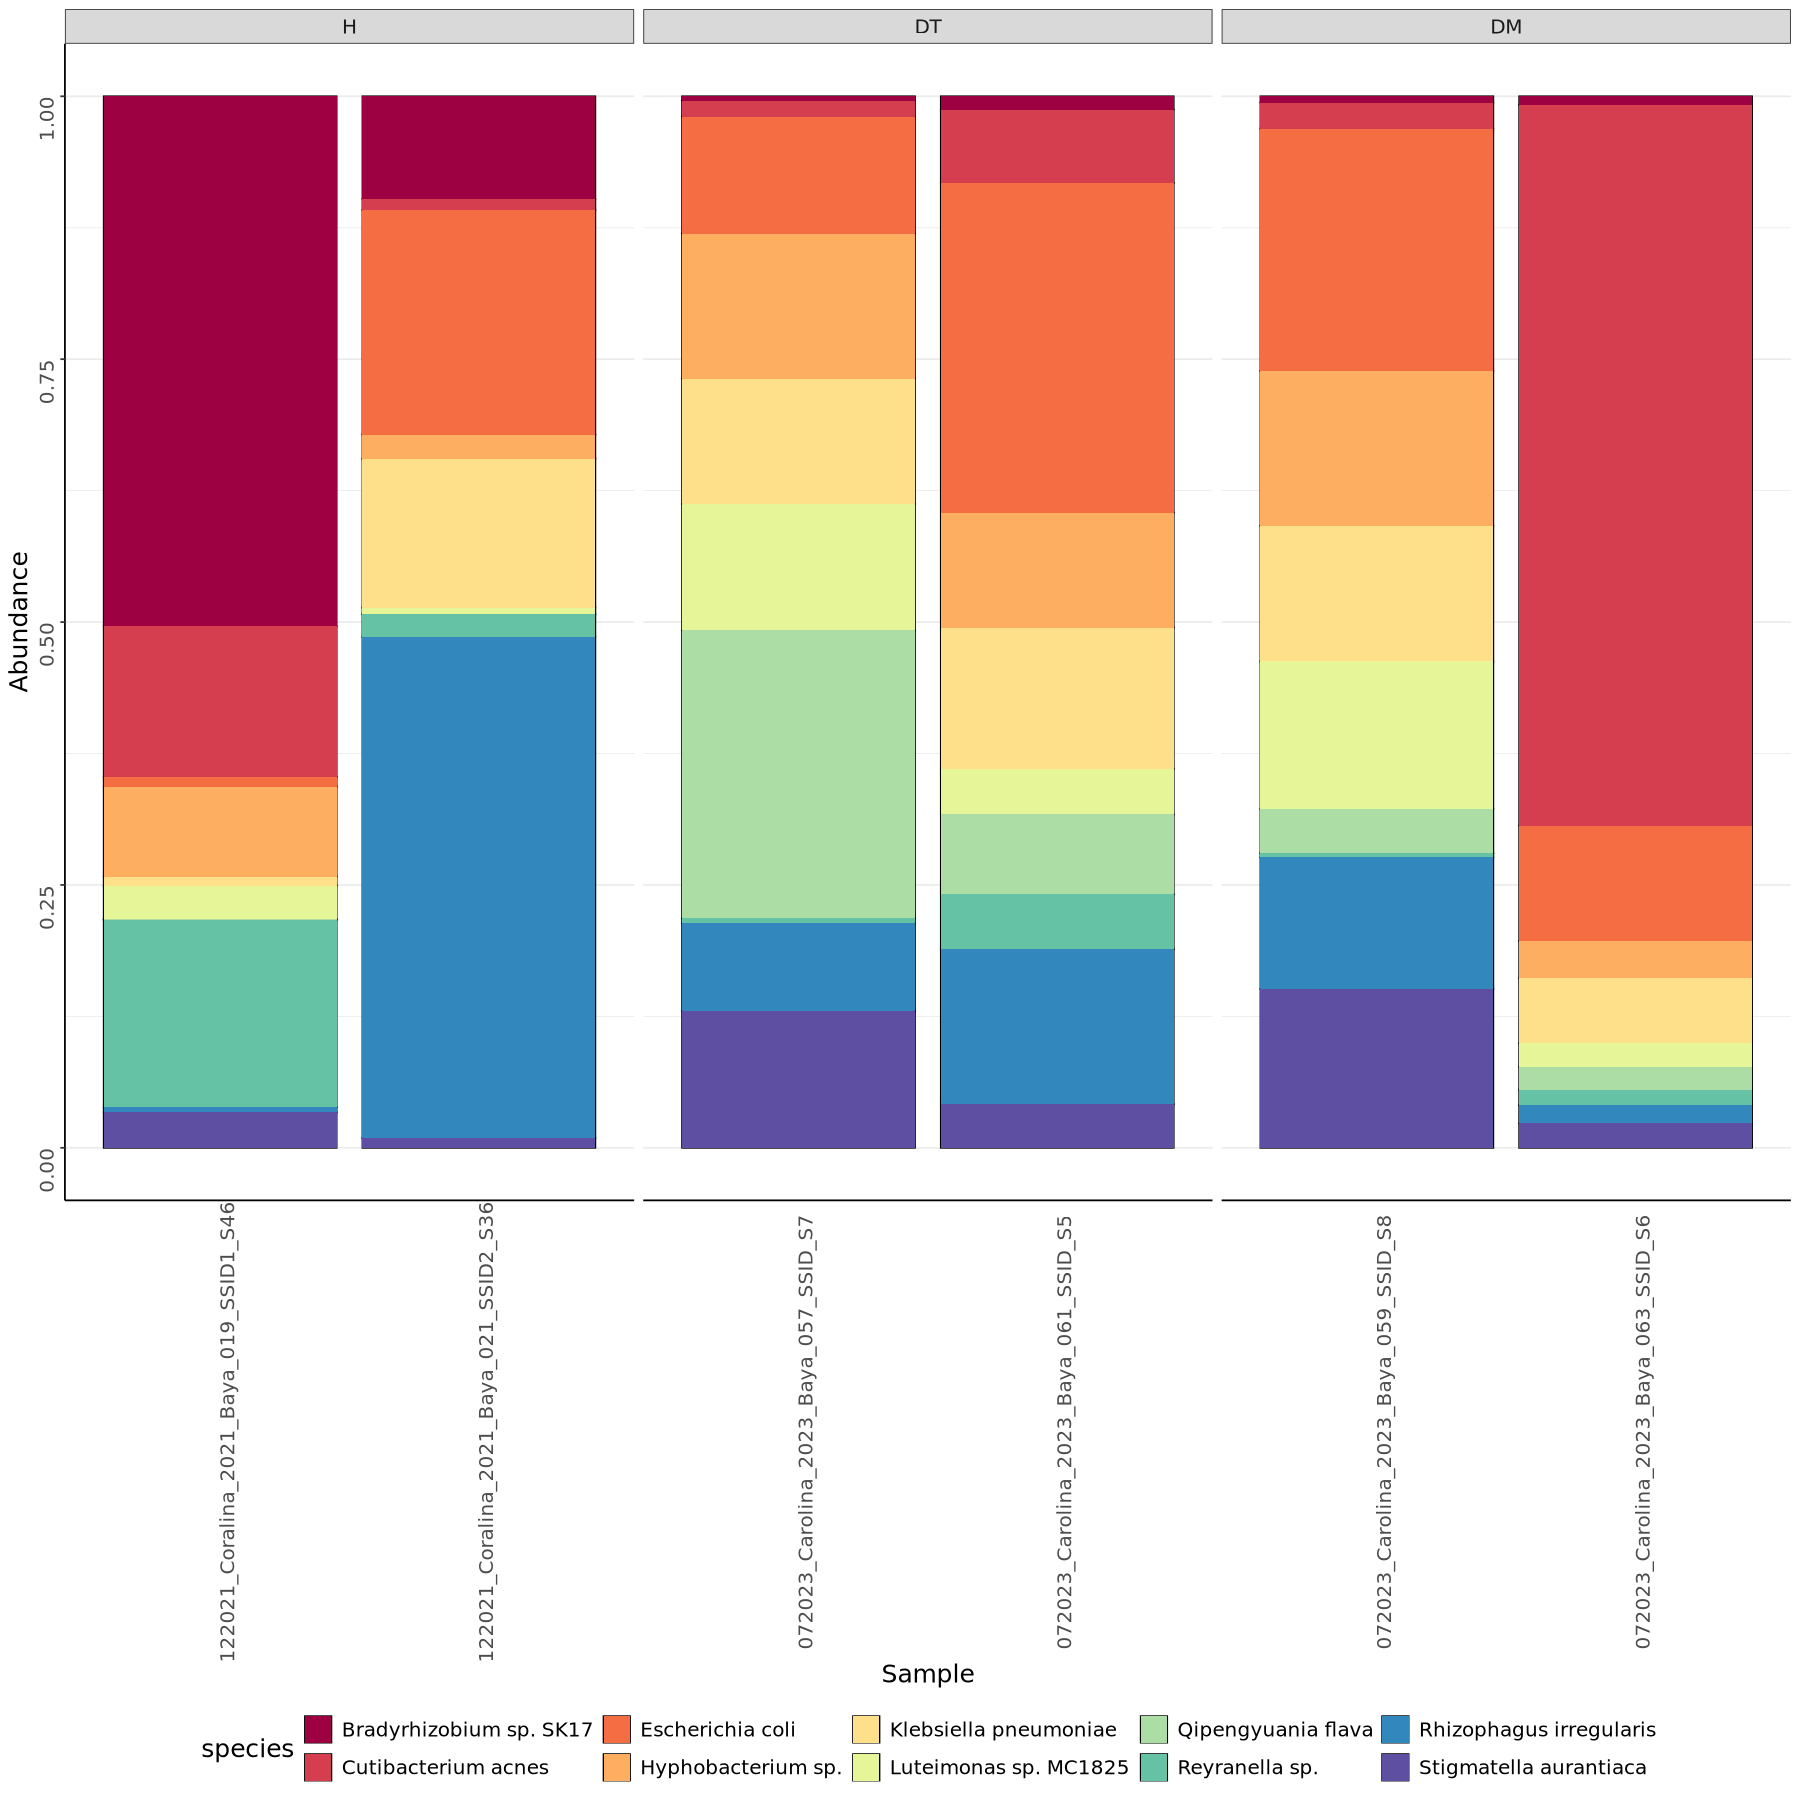

In [108]:
# bar plot of top 10 abundant taxa in ssid samples
ssid_10_rel_bar<-plot_bar(DR_ssid_10_rel,fill='species')+
facet_grid(~Type_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
ssid_10_rel_bar

In [109]:
ggsave(filename = "DR_ssid_top_10_species_rel_bar_samplet.png", plot = ssid_10_rel_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 100)

In [110]:
#run DESeq2 on ssid (on H vs DM sample types)
ds_ssid = phyloseq_to_deseq2(DR_ssid, ~ Sample_type)
ds_ssid = DESeq(ds_ssid, test="Wald", fitType="parametric")
res_ssid = results(ds_ssid, cooksCutoff = FALSE, contrast=c("Sample_type", "H", "DM"))
alpha = 0.0001
sigtab_ssid = res_ssid[which(res_ssid$padj < alpha), ]
sigtab_ssid = cbind(as(sigtab_ssid, "data.frame"), as(tax_table(DR_ssid)[rownames(sigtab_ssid), ], "matrix"))
res_ssid
head(sigtab_ssid)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing



log2 fold change (MLE): Sample_type H vs DM 
Wald test p-value: Sample type H vs DM 
DataFrame with 100 rows and 6 columns
         baseMean log2FoldChange     lfcSE      stat      pvalue        padj
        <numeric>      <numeric> <numeric> <numeric>   <numeric>   <numeric>
2057741  34119.44       7.073498  2.090373   3.38384 0.000714784  0.00822001
5722      5339.26       2.649732  1.068397   2.48010 0.013134538  0.08696686
562       7573.39      -1.939181  0.812604  -2.38638 0.017015255  0.08696686
588596    3860.58       0.295283  0.831711   0.35503 0.722566812  0.81068472
573       4815.33      -1.400488  0.831895  -1.68349 0.092279987  0.22341471
...           ...            ...       ...       ...         ...         ...
1505      393.950       0.649653  0.861126  0.754423 4.50595e-01          NA
5850      433.569      -0.401132  0.761887 -0.526498 5.98542e-01          NA
28116     307.982      -1.409124  1.908920 -0.738179 4.60406e-01          NA
5507      453.536       0.4279

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
587753,1957.622,-3.173958,0.6767682,-4.689876,2.733711e-06,6.287536e-05,Pseudomonas chlororaphis
1314,2526.749,-5.382943,0.8435469,-6.381321,1.755671e-10,8.076085e-09,Streptococcus pyogenes


In [111]:
#run DESeq2 on ssid (on H vs DM sample types)
ds_ssid_dt = phyloseq_to_deseq2(DR_ssid, ~ Sample_type)
ds_ssid_dt = DESeq(ds_ssid_dt, test="Wald", fitType="parametric")
res_ssid_dt = results(ds_ssid_dt, cooksCutoff = FALSE, contrast=c("Sample_type", "H", "DT"))
alpha = 0.0001
sigtab_ssid_dt = res_ssid_dt[which(res_ssid_dt$padj < alpha), ]
sigtab_ssid_dt = cbind(as(sigtab_ssid_dt, "data.frame"), as(tax_table(DR_ssid)[rownames(sigtab_ssid_dt), ], "matrix"))
res_ssid_dt
head(sigtab_ssid_dt)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing



log2 fold change (MLE): Sample_type H vs DT 
Wald test p-value: Sample_type H vs DT 
DataFrame with 100 rows and 6 columns
         baseMean log2FoldChange     lfcSE      stat      pvalue        padj
        <numeric>      <numeric> <numeric> <numeric>   <numeric>   <numeric>
2057741  34119.44      8.5318093  2.090651  4.080934 4.48551e-05 0.000897101
5722      5339.26      2.5617977  1.068211  2.398213 1.64753e-02 0.096913515
562       7573.39     -1.0958273  0.812604 -1.348537 1.77486e-01 0.432891823
588596    3860.58      0.0289274  0.831558  0.034787 9.72250e-01 0.983100226
573       4815.33     -0.8406155  0.831871 -1.010512 3.12250e-01 0.612254906
...           ...            ...       ...       ...         ...         ...
1505      393.950       0.301390  0.859431  0.350685 7.25824e-01 9.21608e-01
5850      433.569      -0.659533  0.760616 -0.867103 3.85885e-01 6.65319e-01
28116     307.982      -1.724951  1.908266 -0.903936 3.66029e-01 6.62588e-01
5507      453.536       0.2825

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
587753,1957.6216,-3.342217,0.6765402,-4.940161,7.805829e-07,1.951457e-05,Pseudomonas chlororaphis
68213,260.2021,-24.223456,4.7851051,-5.062262,4.143112e-07,1.381037e-05,Streptomyces griseoaurantiacus
2306583,260.9297,-11.255374,1.8013921,-6.248153,4.153342e-10,4.153342e-08,Halomonas sp. JS92-SW72
1314,2526.7489,-4.746172,0.8435189,-5.626634,1.837598e-08,9.187992e-07,Streptococcus pyogenes


### DCYL

In [114]:
DR_dcyl <- subset_samples(DR_all, Species == "DCYL")
DR_dcyl

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 12739 taxa and 6 samples ]
sample_data() Sample Data:       [ 6 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 12739 taxa by 1 taxonomic ranks ]

In [115]:
DR_dcyl_10 = prune_taxa(names(sort(taxa_sums(DR_dcyl),TRUE)[1:10]), DR_dcyl)

In [120]:
sample_data(DR_dcyl_10)$Type_o <- factor(sample_data(DR_dcyl_10)$Sample_type, 
                                      levels = c("H", "DT", "DM"))

In [117]:
options(repr.plot.width=15, repr.plot.height=15)

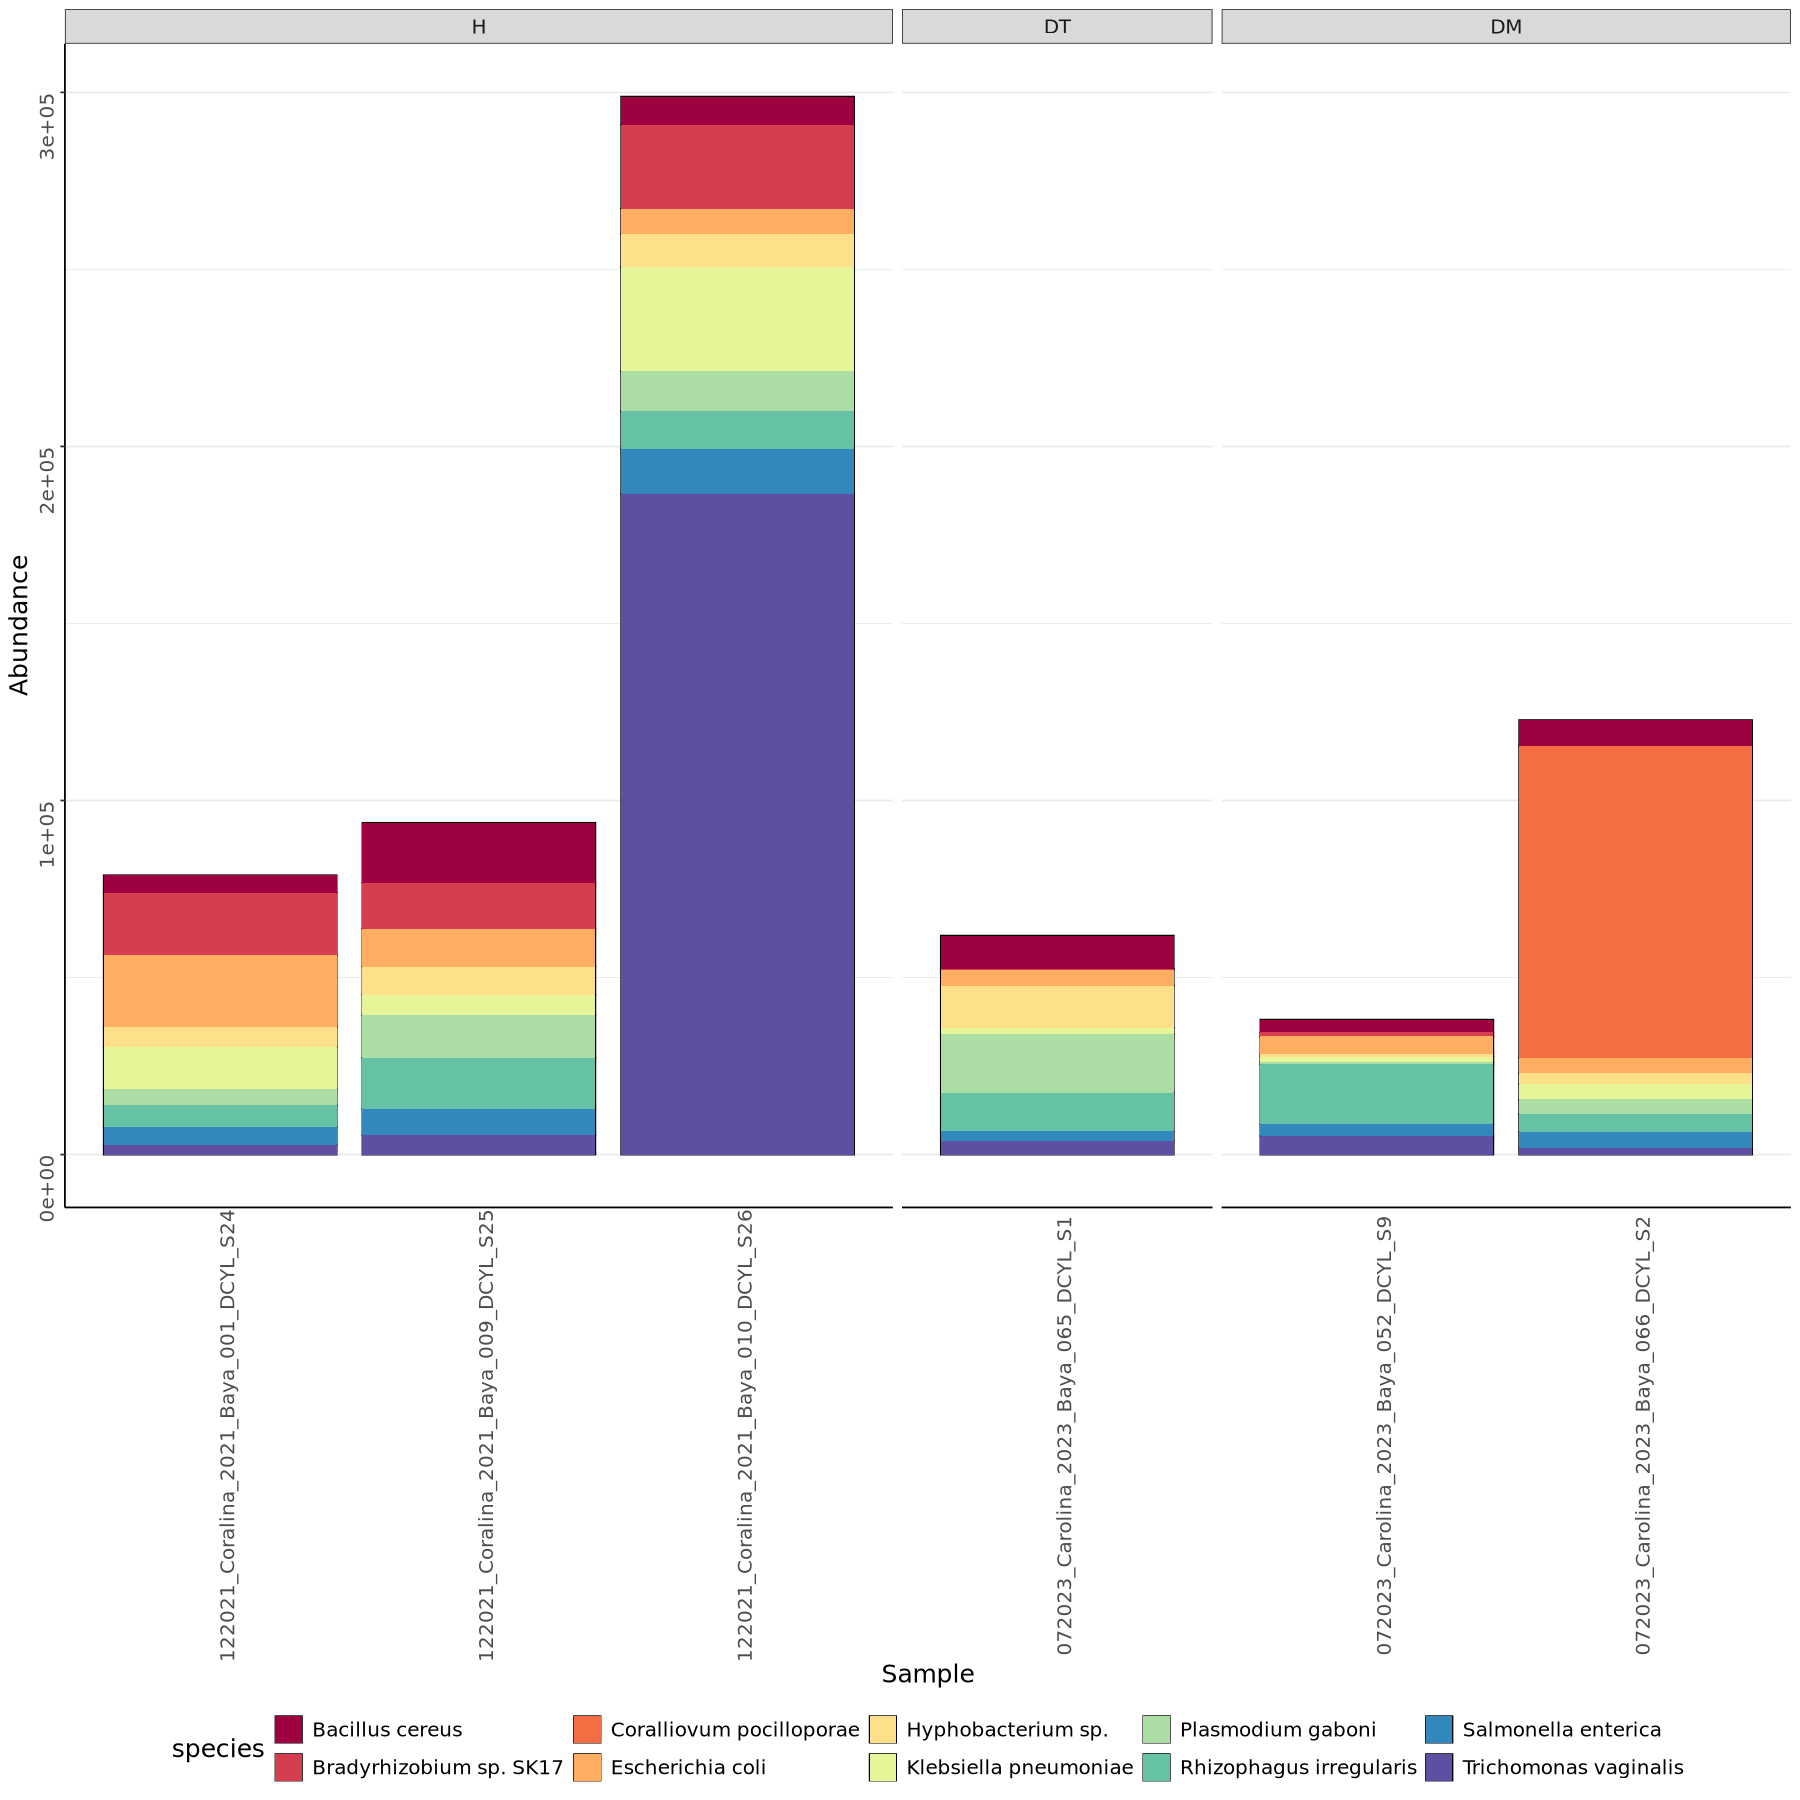

In [121]:
# bar plot of top 10 abundant taxa in dcyl samples
dcyl_10_bar<-plot_bar(DR_dcyl_10,fill='species')+
facet_grid(~Type_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
dcyl_10_bar

In [122]:
ggsave(filename = "DR_dcyl_top_10_species_bar.png", plot = dcyl_10_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 100)

In [123]:
DR_dcyl_10_rel <- transform_sample_counts(DR_dcyl_10, function(x) x / sum(x))

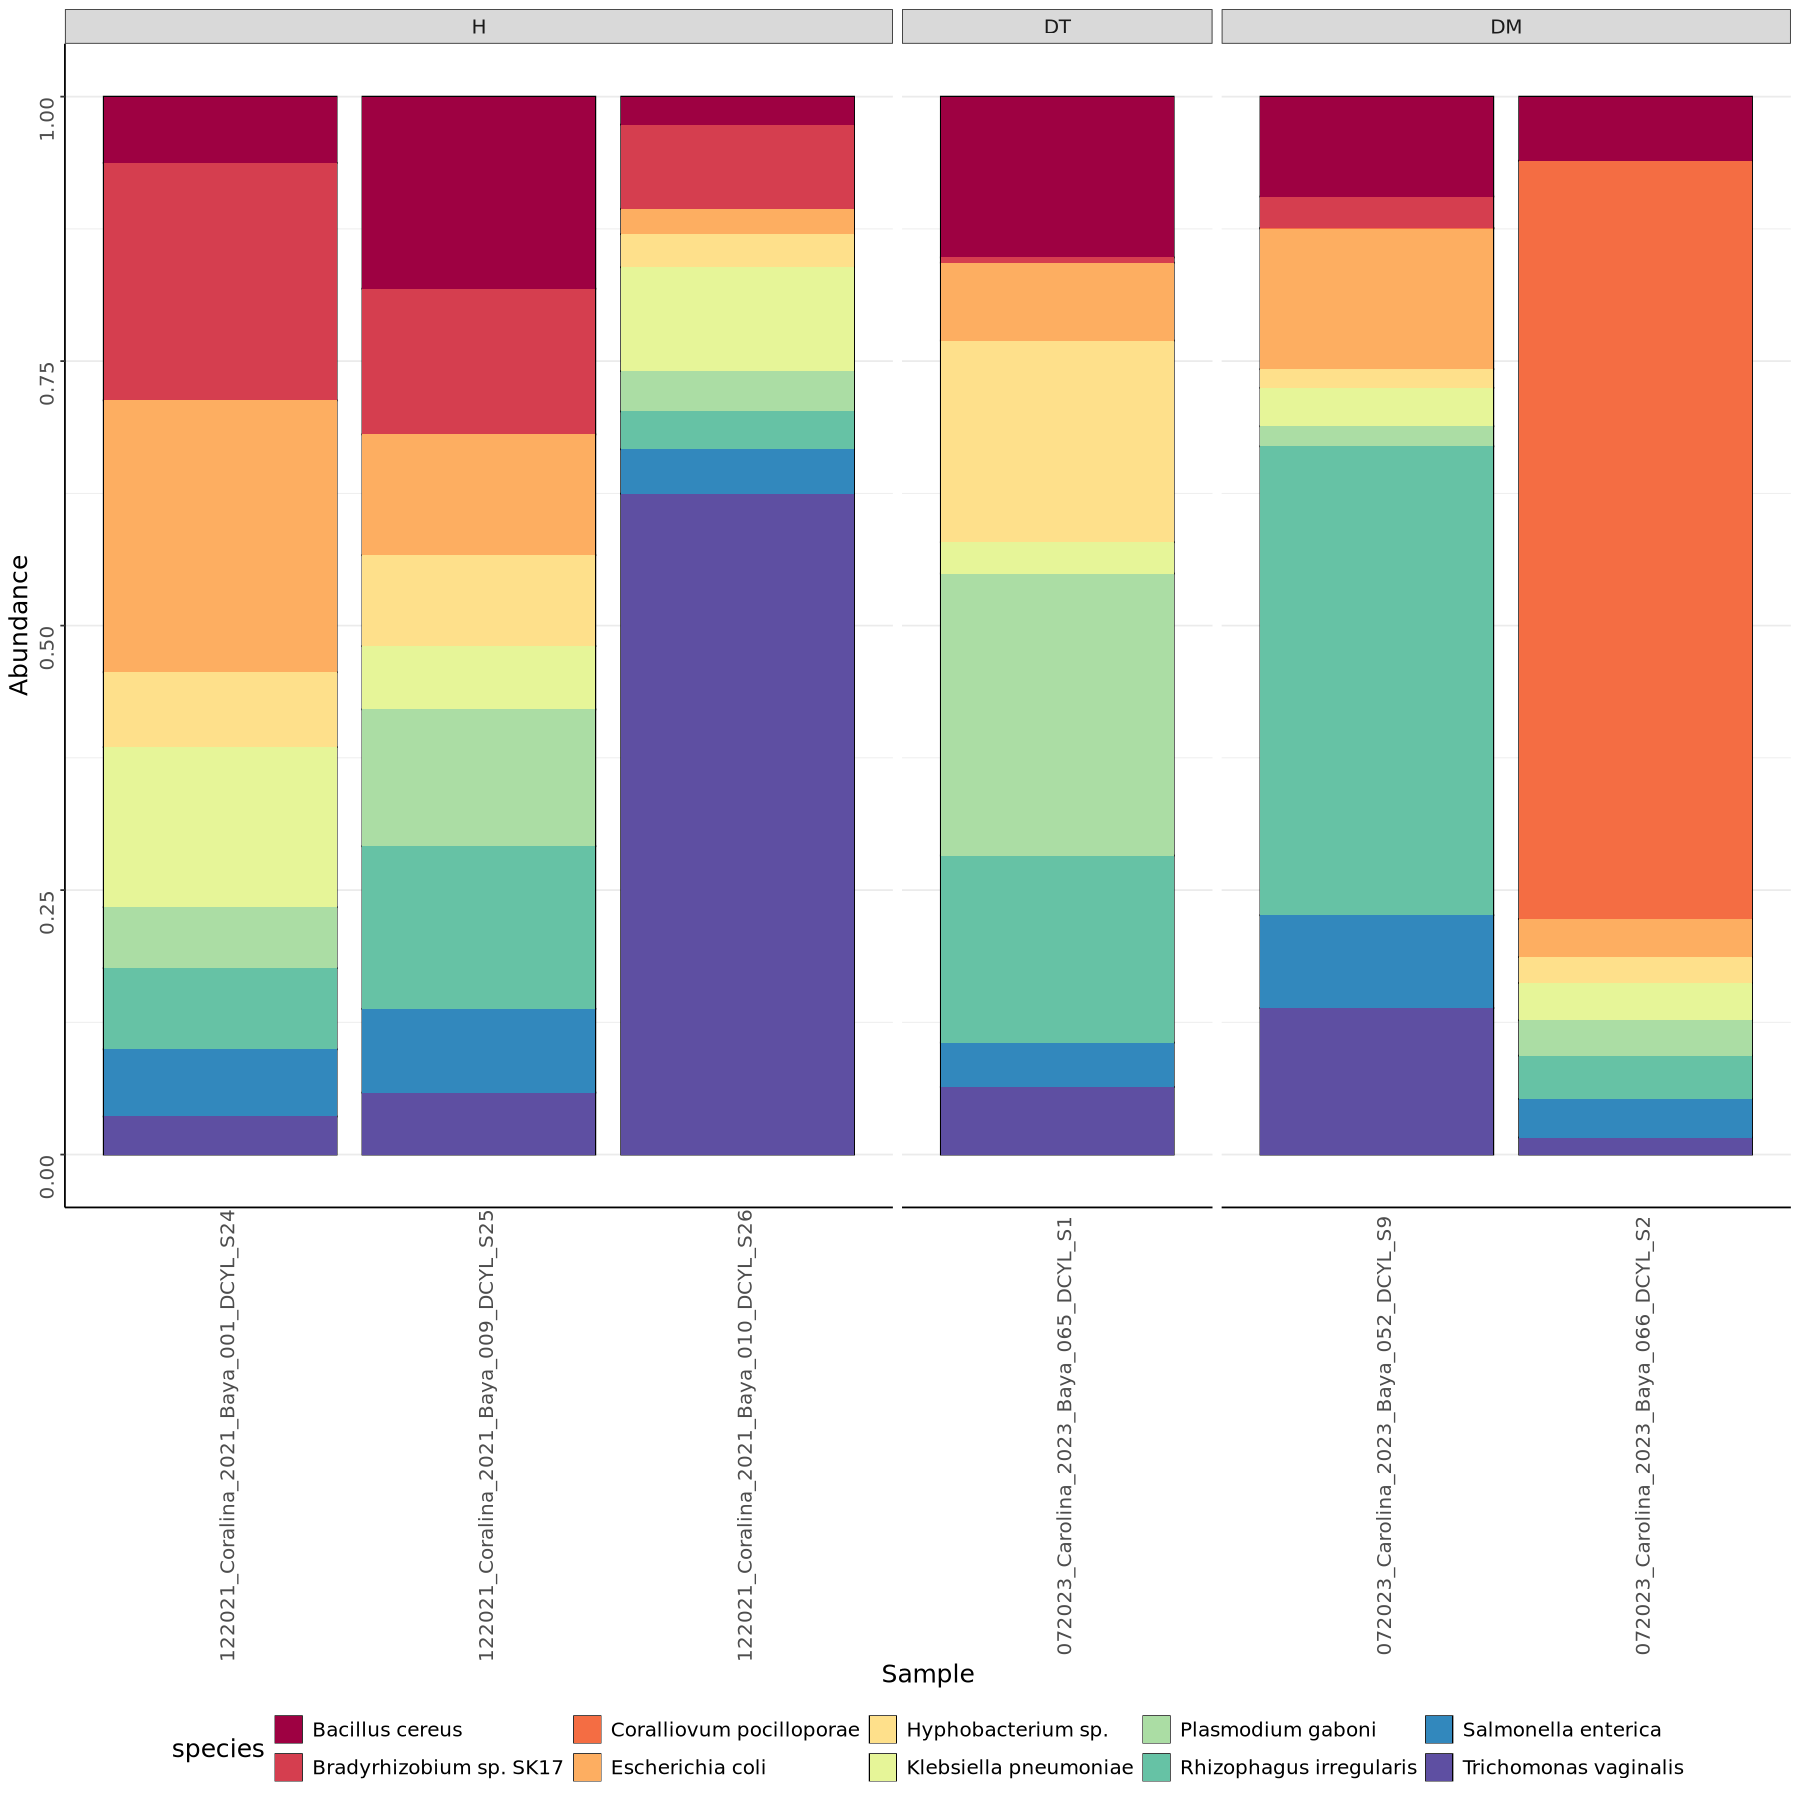

In [125]:
# bar plot of top 10 abundant taxa in dcyl samples
dcyl_10_rel_bar<-plot_bar(DR_dcyl_10_rel,fill='species')+
facet_grid(~Type_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
dcyl_10_rel_bar

In [127]:
#run DESeq2 on dcyl (on H vs DM sample types)
ds_dcyl = phyloseq_to_deseq2(DR_dcyl, ~ Sample_type)
ds_dcyl = DESeq(ds_dcyl, test="Wald", fitType="parametric")
res_dcyl = results(ds_dcyl, cooksCutoff = FALSE, contrast=c("Sample_type", "H", "DM"))
alpha = 0.0001
sigtab = res[which(res$padj < alpha), ]
sigtab_dcyl = cbind(as(sigtab, "data.frame"), as(tax_table(DR_dcyl)[rownames(sigtab), ], "matrix"))
res
head(sigtab_dcyl)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing



log2 fold change (MLE): Sample type H vs DM 
Wald test p-value: Sample type H vs DM 
DataFrame with 12739 rows and 6 columns
         baseMean log2FoldChange     lfcSE      stat    pvalue      padj
        <numeric>      <numeric> <numeric> <numeric> <numeric> <numeric>
2057741   7116.72       3.626518   2.52004   1.43907  0.150130  0.195343
5722     22406.83       2.564913   1.89183   1.35579  0.175168  0.227809
562       8724.76       0.337664   1.18808   0.28421  0.776250  0.891804
588596   11966.22      -1.502261   1.25030  -1.20152  0.229550  0.298243
573       7372.53       1.233675   1.16284   1.06092  0.288728  0.373912
...           ...            ...       ...       ...       ...       ...
2845680    2.8891       -6.02947   4.35209  -1.38542  0.165925        NA
1923622    2.8891       -6.02947   4.35209  -1.38542  0.165925        NA
3048237    2.8891       -6.02947   4.35209  -1.38542  0.165925        NA
3060633    2.8891       -6.02947   4.35209  -1.38542  0.165925        NA

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
3066369,22836.4905,-30.00000,4.327957,-6.931677,4.158810e-12,8.297469e-09,Coralliovum pocilloporae
192812,3117.1099,-15.39255,3.248775,-4.737956,2.158843e-06,2.482359e-05,Qipengyuania flava
587,1015.9580,-14.12500,1.800864,-7.843457,4.383076e-15,1.748847e-11,Providencia rettgeri
3425945,2124.5080,-27.18614,4.328103,-6.281307,3.357390e-10,1.071679e-07,Limimaricola sp. AA108-03
1352,635.2744,-27.34111,4.328086,-6.317136,2.664554e-10,8.862563e-08,Enterococcus faecium
2761107,201.9163,-25.37311,4.328300,-5.862143,4.569308e-09,2.450284e-07,Luteimonas sp. MC1825


In [128]:
# sort by most significant 
sorted_sigtab_dcyl <- sigtab_dcyl %>%
  arrange(padj)
head(sorted_sigtab_dcyl)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1392,1402.3787,-14.07711,1.759320,-8.001449,1.229633e-15,9.812473e-12,Bacillus anthracis
587,1015.9580,-14.12500,1.800864,-7.843457,4.383076e-15,1.748847e-11,Providencia rettgeri
3066369,22836.4905,-30.00000,4.327957,-6.931677,4.158810e-12,8.297469e-09,Coralliovum pocilloporae
911045,7046.3222,-30.00000,4.327964,-6.931666,4.159133e-12,8.297469e-09,Pseudovibrio sp. FO-BEG1
158,703.2808,-13.80894,2.046466,-6.747702,1.502051e-11,2.397274e-08,Treponema denticola
3003349,1639.5183,-28.75452,4.328002,-6.643833,3.056291e-11,3.794440e-08,Marinobacter sp. LM1


In [129]:
#include just the top 20 for now
sorted_sigtab20_dcyl <- head(sorted_sigtab_dcyl, 20)
sorted_sigtab20_dcyl

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1392,1402.37875,-14.07711,1.759320,-8.001449,1.229633e-15,9.812473e-12,Bacillus anthracis
587,1015.95800,-14.12500,1.800864,-7.843457,4.383076e-15,1.748847e-11,Providencia rettgeri
3066369,22836.49049,-30.00000,4.327957,-6.931677,4.158810e-12,8.297469e-09,Coralliovum pocilloporae
911045,7046.32218,-30.00000,4.327964,-6.931666,4.159133e-12,8.297469e-09,Pseudovibrio sp. FO-BEG1
158,703.28078,-13.80894,2.046466,-6.747702,1.502051e-11,2.397274e-08,Treponema denticola
3003349,1639.51832,-28.75452,4.328002,-6.643833,3.056291e-11,3.794440e-08,Marinobacter sp. LM1
28213,1598.31642,-28.70005,4.327998,-6.631255,3.328456e-11,3.794440e-08,Sphingomonas parapaucimobilis
1184,567.40983,-13.54935,2.068837,-6.549260,5.782288e-11,5.767833e-08,Leptolyngbya boryana
3035452,1012.14936,-28.22564,4.328023,-6.521600,6.956115e-11,6.167756e-08,Pseudoalteromonas apostichopi


In [131]:
# subset taxa that are assoc with DT (none)
DT_dcyl_otu<-sorted_sigtab_dcyl[sorted_sigtab_dcyl$log2FoldChange>0,]
head(DT_dcyl_otu)
dim(DT_dcyl_otu)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2903657,768.4864,24.35372,4.407388,5.525658,3.282533e-08,4.508539e-07,Streptomyces sp. NBC_00490
2880934,465.0871,24.29692,4.407413,5.512740,3.532897e-08,4.714468e-07,Mesorhizobium sp. PAMC28654
758802,374.4259,23.59402,4.407428,5.353241,8.639281e-08,1.128338e-06,Mycolicibacterium litorale
904039,271.9838,23.45249,4.407457,5.321092,1.031463e-07,1.342753e-06,Arthrobacter sp. NEB 688
3383314,311.4240,23.26524,4.407444,5.278624,1.301578e-07,1.688877e-06,Streptomyces sp. Inha503
458197,200.9572,23.18920,4.407495,5.261310,1.430324e-07,1.852920e-06,Serratia nematodiphila


[1] 63  7

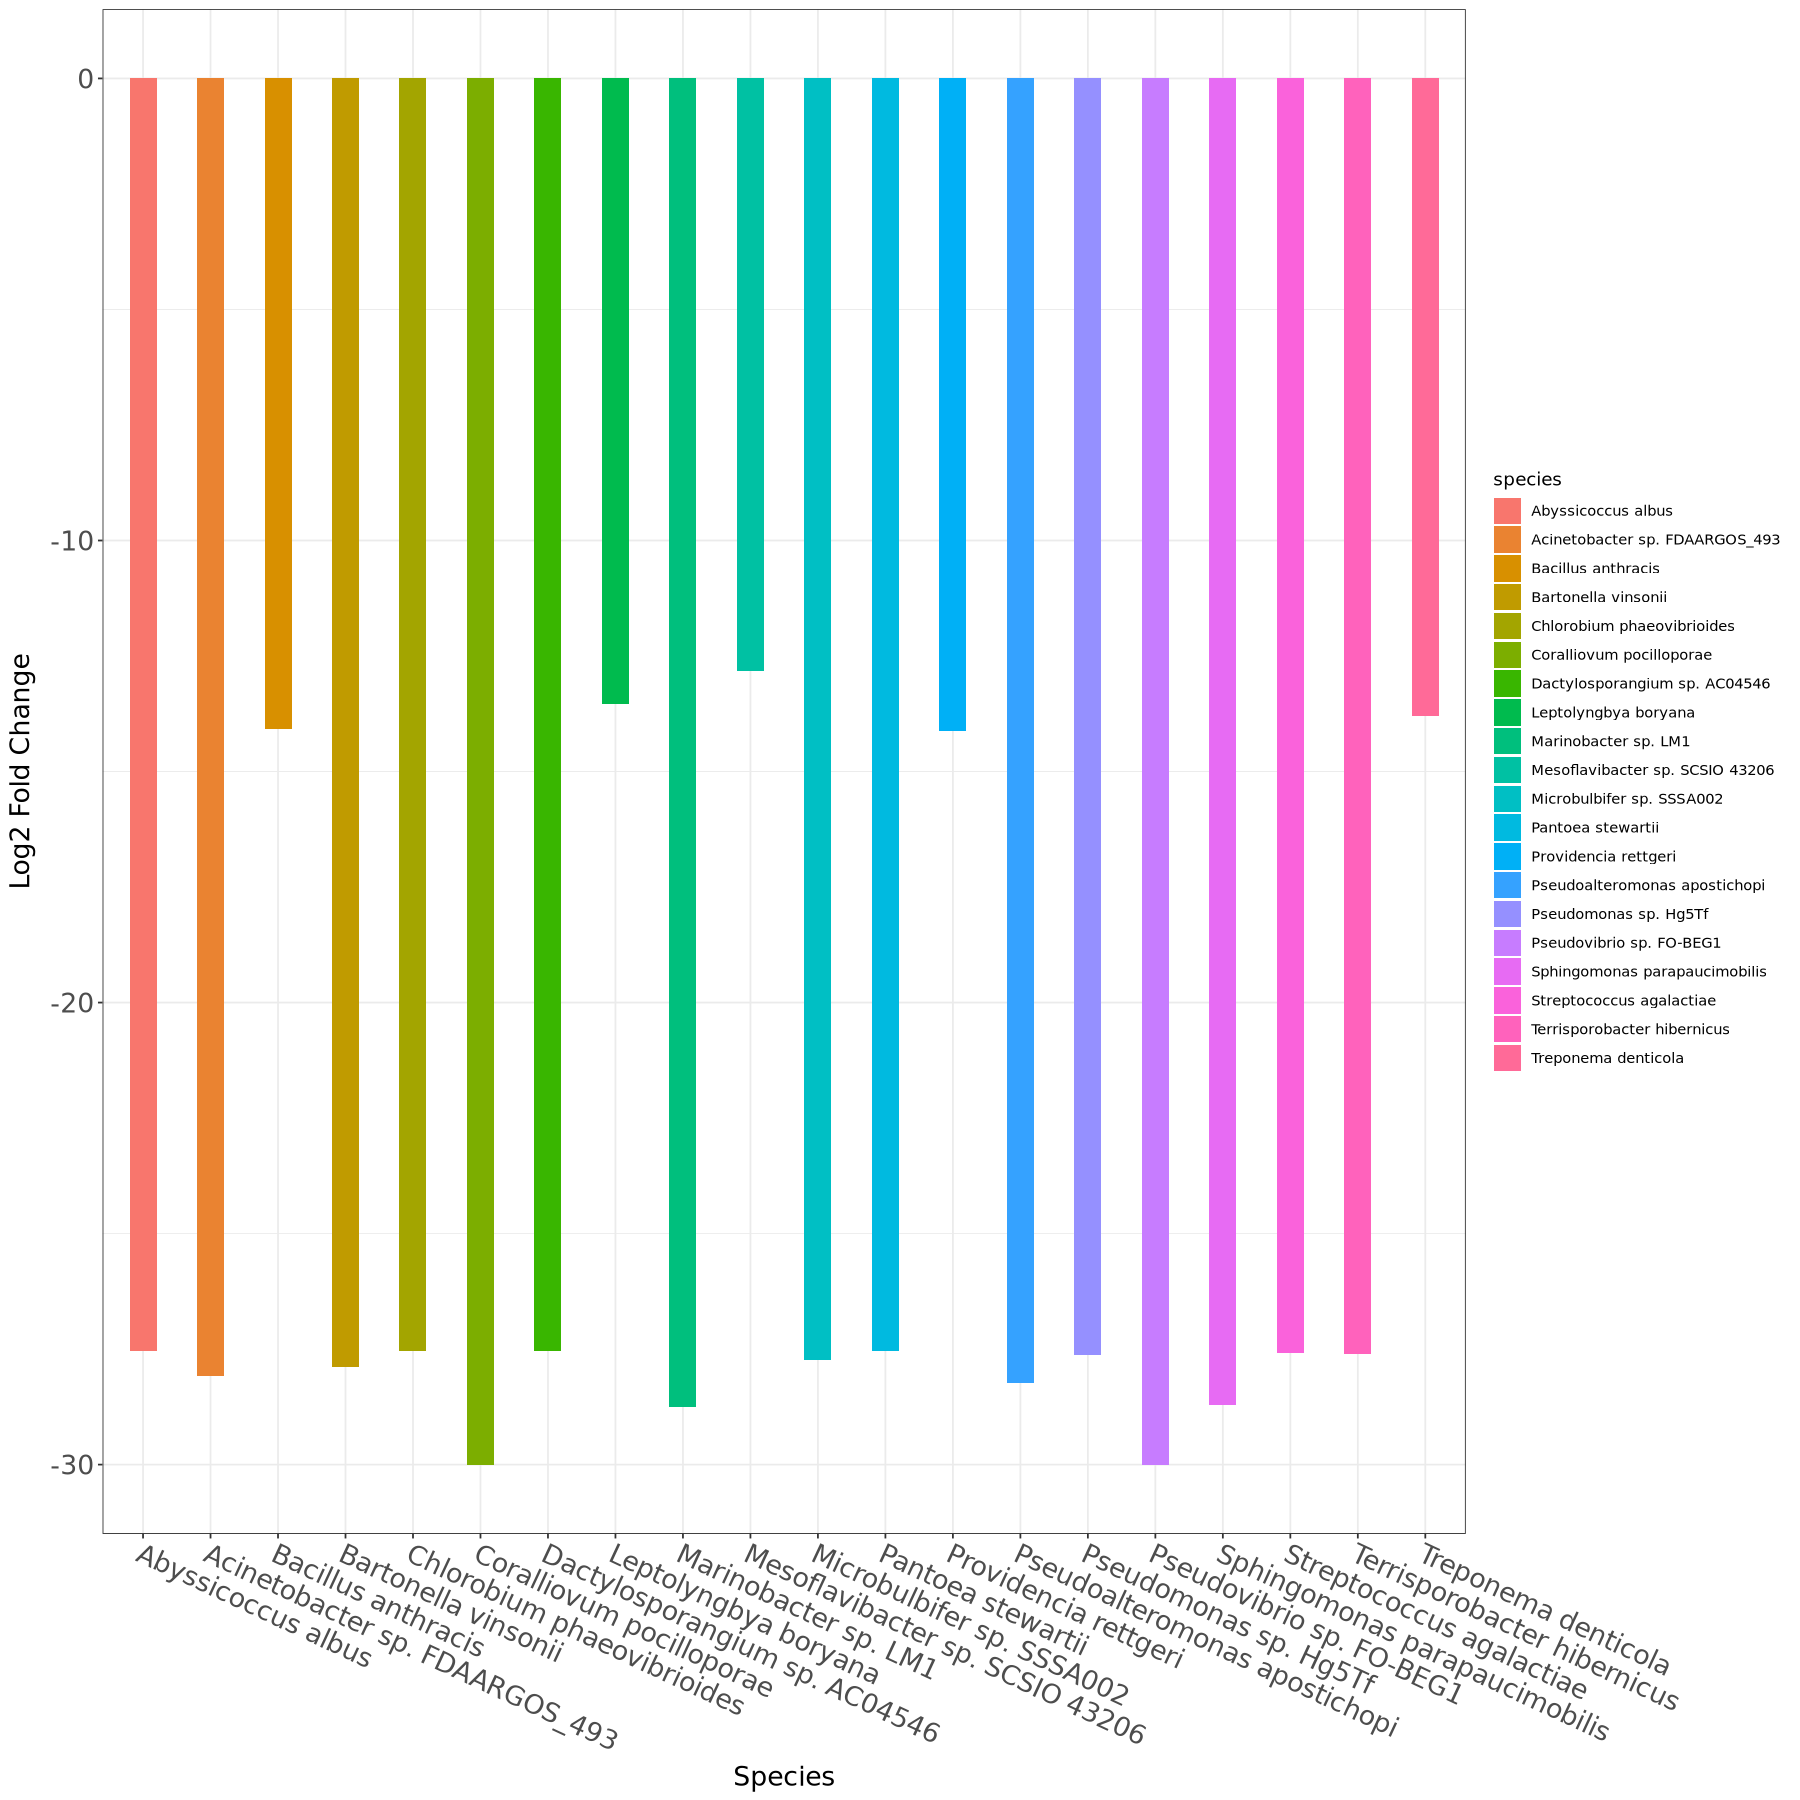

In [132]:
# plot significantly different OTUs top 20
ds_dcyl_plot <- ggplot(sorted_sigtab20_dcyl, aes(x = species, y = log2FoldChange, fill = species)) +
  geom_bar(stat = "identity", width = 0.4) +
theme_bw()+
  theme(
    axis.text.x = element_text(angle = -25, hjust = 0, vjust = 1, size = 16),  # Adjust text size
    axis.text.y = element_text(size = 16),  # Adjust y-axis text size
    axis.title.x = element_text(size = 16, margin = margin(t = 5)),  # Adjust x-axis title size and margin
    axis.title.y = element_text(size = 16, margin = margin(r = 10)),   # Adjust y-axis title size and add margin
  ) +
  labs(x = "Species", y = "Log2 Fold Change")

ds_dcyl_plot

In [ ]:
#for later
#pseudo_search <- sorted_sigtab[grepl("Pseudoalteromonas", sorted_sigtab$species), ]
#pseudo_search
#vibrio_search <- sorted_sigtab[grepl("Vibrio", sorted_sigtab$species), ]
#vibrio_search

#### DESeq2 on DR_all just to see

In [55]:
#run DESeq2 on mcav
ds_all = phyloseq_to_deseq2(DR_all, ~ SCTLD_status)
ds_all = DESeq(ds_all, test="Wald", fitType="parametric")
res = results(ds_all, cooksCutoff = FALSE)
alpha = 0.0001
sigtab_a = res[which(res$padj < alpha), ]
sigtab_all = cbind(as(sigtab_a, "data.frame"), as(tax_table(DR_all)[rownames(sigtab_a), ], "matrix"))
res
head(sigtab_all)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 5846 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



log2 fold change (MLE): SCTLD status healthy vs disease 
Wald test p-value: SCTLD status healthy vs disease 
DataFrame with 12739 rows and 6 columns
         baseMean log2FoldChange     lfcSE      stat      pvalue        padj
        <numeric>      <numeric> <numeric> <numeric>   <numeric>   <numeric>
2057741  13420.97      4.8638021  0.921409  5.278659 1.30133e-07 2.21558e-06
5722      3662.87     -0.0643109  0.457879 -0.140454 8.88301e-01 9.82450e-01
562      10037.11     -0.3521598  0.639369 -0.550793 5.81776e-01 9.26587e-01
588596    8318.00     -0.0490679  0.488856 -0.100373 9.20048e-01 9.89005e-01
573       6456.22     -0.3734551  0.650851 -0.573795 5.66107e-01 9.22780e-01
...           ...            ...       ...       ...         ...         ...
2845680   0.32806       -2.80753   3.16702 -0.886491    0.375353          NA
1923622   0.32806       -2.80753   3.16702 -0.886491    0.375353          NA
3048237   0.32806       -2.80753   3.16702 -0.886491    0.375353          NA
3060

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2057741,13420.97234,4.863802,0.9214087,5.278659,1.301330e-07,2.215579e-06,Bradyrhizobium sp. SK17
2653203,2068.17628,-15.277517,1.7381787,-8.789382,1.503845e-18,1.033562e-16,Sphingomonas sp. CL5.1
3003349,1043.82120,-14.291071,1.9555097,-7.308105,2.709359e-13,4.946168e-12,Marinobacter sp. LM1
3240067,59.07754,21.972324,3.1632473,6.946129,3.754455e-12,6.697116e-11,Streptomyces sp. CA-253872
2759660,56.94552,23.337837,3.1632547,7.377793,1.609354e-13,2.961147e-12,Bartonella sp. HY038
3369658,399.98012,-12.907209,1.9730863,-6.541634,6.085009e-11,1.047451e-09,Marinobacter sp. W-8


**stopped here, do sample_type next**

In [77]:
# sort by most significant 
sorted_sigtab_all <- sigtab_all %>%
  arrange(padj)
sorted_sigtab_all

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2903826,82.74919,-27.06343,2.386922,-11.338211,8.486180e-30,8.960558e-26,Streptomyces sp. NBC_01324
2861775,56.99167,-26.55816,2.364958,-11.229866,2.909193e-29,1.535909e-25,Pseudomonas sp. YeP6b
2961995,219.74465,-28.40574,2.768778,-10.259306,1.074767e-24,3.782820e-21,Marinobacter metalliresistant
1926,91.38790,-27.20426,2.670125,-10.188383,2.234491e-24,5.898497e-21,Streptomyces reticuli
2860286,80.39328,-27.01944,2.685566,-10.060985,8.217239e-24,1.735317e-20,Achromobacter sp. ES-001
2979870,51.46594,-26.40580,2.666322,-9.903454,4.021398e-23,7.076990e-20,Aminobacter sp. NyZ550
2602067,49.38830,-26.35993,2.671177,-9.868284,5.713349e-23,8.618179e-20,Octadecabacter sp. SW4
2560029,34.60491,-25.83427,2.634033,-9.807876,1.041369e-22,1.221758e-19,Aeromonas sp. 2692-1
1263728,48.97731,-26.34226,2.684365,-9.813220,9.876604e-23,1.221758e-19,Paracoccus sp. TOH


In [30]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR/bracken_filtered/otu_table_species/mcav")

In [31]:
#taxonomy file should be ready to go (same from above)
#read in normalized otu table
otu_mcav = read.csv('otu_table_normtable_mcav.csv',header=TRUE)
head(otu_mcav)

,X,X072023_Carolina_2023_Baya_053_MCAV_S3,X072023_Carolina_2023_Baya_055_MCAV_S4,X122021_Coralina_2021_Baya_003_MCAV_S27,X122021_Coralina_2021_Baya_005_MCAV_S28,X122021_Coralina_2021_Baya_007_MCAV_S29,X122021_Coralina_2021_Baya_017_MCAV_S30,X122021_Coralina_2021_Baya_023_MCAV_S31
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2066072,46974.04197,31054.680,54117.052,46648.294,19921.73137,50005.848,24032.708
2,588596,18978.86829,12952.058,25200.458,19058.523,22294.30407,26497.381,23390.756
3,562,6470.91394,6157.647,4981.486,10973.089,7402.25176,7615.236,8177.104
4,5722,4375.92456,5776.040,7538.826,8308.341,4132.30376,8109.056,4998.504
5,1280,5830.43396,4073.485,6047.044,6210.991,5808.86344,5808.891,5883.526
6,2093777,53.71768,31587.575,0.000,0.000,74.41649,0.000,0.000


In [32]:
# rename first col as otu
names(otu_mcav)[1] <- "otu"
head(otu_mcav)
dim(otu_mcav)

,otu,X072023_Carolina_2023_Baya_053_MCAV_S3,X072023_Carolina_2023_Baya_055_MCAV_S4,X122021_Coralina_2021_Baya_003_MCAV_S27,X122021_Coralina_2021_Baya_005_MCAV_S28,X122021_Coralina_2021_Baya_007_MCAV_S29,X122021_Coralina_2021_Baya_017_MCAV_S30,X122021_Coralina_2021_Baya_023_MCAV_S31
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2066072,46974.04197,31054.680,54117.052,46648.294,19921.73137,50005.848,24032.708
2,588596,18978.86829,12952.058,25200.458,19058.523,22294.30407,26497.381,23390.756
3,562,6470.91394,6157.647,4981.486,10973.089,7402.25176,7615.236,8177.104
4,5722,4375.92456,5776.040,7538.826,8308.341,4132.30376,8109.056,4998.504
5,1280,5830.43396,4073.485,6047.044,6210.991,5808.86344,5808.891,5883.526
6,2093777,53.71768,31587.575,0.000,0.000,74.41649,0.000,0.000


[1] 13490     8

In [33]:
#remove X's from headers
names(otu_mcav) <- sub("^X", "", names(otu_mcav))
otu_table_mcav=as.data.frame(otu_mcav)
head(otu_table_mcav)

,otu,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2066072,46974.04197,31054.680,54117.052,46648.294,19921.73137,50005.848,24032.708
2,588596,18978.86829,12952.058,25200.458,19058.523,22294.30407,26497.381,23390.756
3,562,6470.91394,6157.647,4981.486,10973.089,7402.25176,7615.236,8177.104
4,5722,4375.92456,5776.040,7538.826,8308.341,4132.30376,8109.056,4998.504
5,1280,5830.43396,4073.485,6047.044,6210.991,5808.86344,5808.891,5883.526
6,2093777,53.71768,31587.575,0.000,0.000,74.41649,0.000,0.000


In [34]:
# make the index the otus
row.names(otu_table_mcav) <- otu_table_mcav$otu
otu_table_mcav$otu <- NULL
head(otu_table_mcav)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2066072,46974.04197,31054.680,54117.052,46648.294,19921.73137,50005.848,24032.708
588596,18978.86829,12952.058,25200.458,19058.523,22294.30407,26497.381,23390.756
562,6470.91394,6157.647,4981.486,10973.089,7402.25176,7615.236,8177.104
5722,4375.92456,5776.040,7538.826,8308.341,4132.30376,8109.056,4998.504
1280,5830.43396,4073.485,6047.044,6210.991,5808.86344,5808.891,5883.526
2093777,53.71768,31587.575,0.000,0.000,74.41649,0.000,0.000


In [35]:
# sort by most abundant OTUs
otus_sorted_mcav <- otu_table_mcav[order(rowSums(otu_table_mcav), decreasing = TRUE), ]
head(otus_sorted_mcav)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2066072,46974.04197,31054.680,54117.052,46648.294,19921.73137,50005.848,24032.708
588596,18978.86829,12952.058,25200.458,19058.523,22294.30407,26497.381,23390.756
562,6470.91394,6157.647,4981.486,10973.089,7402.25176,7615.236,8177.104
5722,4375.92456,5776.040,7538.826,8308.341,4132.30376,8109.056,4998.504
1280,5830.43396,4073.485,6047.044,6210.991,5808.86344,5808.891,5883.526
2093777,53.71768,31587.575,0.000,0.000,74.41649,0.000,0.000


In [36]:
# Convert to matrix
otus_mcav=as.matrix(otus_sorted_mcav)
head(otus_mcav)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31
2066072,46974.04197,31054.680,54117.052,46648.294,19921.73137,50005.848,24032.708
588596,18978.86829,12952.058,25200.458,19058.523,22294.30407,26497.381,23390.756
562,6470.91394,6157.647,4981.486,10973.089,7402.25176,7615.236,8177.104
5722,4375.92456,5776.040,7538.826,8308.341,4132.30376,8109.056,4998.504
1280,5830.43396,4073.485,6047.044,6210.991,5808.86344,5808.891,5883.526
2093777,53.71768,31587.575,0.000,0.000,74.41649,0.000,0.000


In [37]:
#read in metadata
metadata_mcav=read.csv('DR_metadata_mcav.csv', header=TRUE)
head(metadata_mcav)
dim(metadata_mcav)

,SampleID,Year,Species,Sample_type,Tag_num,SCTLD_status
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,072023_Carolina_2023_Baya_053_MCAV_S3,2023,MCAV,DT,MCAV-3,disease
2,072023_Carolina_2023_Baya_055_MCAV_S4,2023,MCAV,DM,MCAV-3,disease
3,122021_Coralina_2021_Baya_003_MCAV_S27,2021,MCAV,H,MCAV-2,healthy
4,122021_Coralina_2021_Baya_005_MCAV_S28,2021,MCAV,H,MCAV-3,healthy
5,122021_Coralina_2021_Baya_007_MCAV_S29,2021,MCAV,H,MCAV-4,healthy
6,122021_Coralina_2021_Baya_017_MCAV_S30,2021,MCAV,H,MCAV-9,healthy


[1] 7 6

In [38]:
# index the SampleIDs
row.names(metadata_mcav) <- metadata_mcav$SampleID
metadata_mcav$SampleID <- NULL
head(metadata_mcav)

,Year,Species,Sample_type,Tag_num,SCTLD_status
,<int>,<chr>,<chr>,<chr>,<chr>
072023_Carolina_2023_Baya_053_MCAV_S3,2023,MCAV,DT,MCAV-3,disease
072023_Carolina_2023_Baya_055_MCAV_S4,2023,MCAV,DM,MCAV-3,disease
122021_Coralina_2021_Baya_003_MCAV_S27,2021,MCAV,H,MCAV-2,healthy
122021_Coralina_2021_Baya_005_MCAV_S28,2021,MCAV,H,MCAV-3,healthy
122021_Coralina_2021_Baya_007_MCAV_S29,2021,MCAV,H,MCAV-4,healthy
122021_Coralina_2021_Baya_017_MCAV_S30,2021,MCAV,H,MCAV-9,healthy


In [39]:
# classify phyloseq objects 
OTU_M=otu_table((otus_mcav), taxa_are_rows = TRUE)
TAX_M=tax_table(taxonomy)
SAMP_M=sample_data(metadata_mcav)

In [40]:
# Create phyloseq object
DR_mcav = phyloseq(OTU_M, SAMP_M, TAX_M)
DR_mcav

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13490 taxa and 7 samples ]
sample_data() Sample Data:       [ 7 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 13490 taxa by 1 taxonomic ranks ]

In [41]:
DR_mcav.ord <- ordinate(DR_mcav, "NMDS", "bray")

Square root transformation


Warning message in decostand(x, "max", 2, na.rm = na.rm):
“result contains NaN, perhaps due to impossible mathematical
                 operation
”
Warning message in decostand(x, "total", 1, na.rm = na.rm):
“result contains NaN, perhaps due to impossible mathematical
                 operation
”


Wisconsin double standardization
Run 0 stress 0.01215683 
Run 1 stress 0.008575588 
... New best solution
... Procrustes: rmse 0.1119286  max resid 0.2648545 
Run 2 stress 0.02349921 
Run 3 stress 0.157905 
Run 4 stress 0.01215683 
Run 5 stress 0.01235787 
Run 6 stress 0.01235789 
Run 7 stress 0.2124849 
Run 8 stress 0.01235792 
Run 9 stress 0.01215687 
Run 10 stress 0.008575594 
... Procrustes: rmse 0.000100494  max resid 0.0001691103 
... Similar to previous best
Run 11 stress 0.01215684 
Run 12 stress 0.01235792 
Run 13 stress 0.008575628 
... Procrustes: rmse 0.0001241158  max resid 0.0002088564 
... Similar to previous best
Run 14 stress 0.2124849 
Run 15 stress 0.02349921 
Run 16 stress 0.01215687 
Run 17 stress 0.01215687 
Run 18 stress 0.01235788 
Run 19 stress 0.01235795 
Run 20 stress 0.01235791 
*** Best solution repeated 2 times


Warning message in metaMDS(veganifyOTU(physeq), distance, ...):
“WA scores were not calculated due to missing values”


In [42]:
options(repr.plot.width=20, repr.plot.height=15)

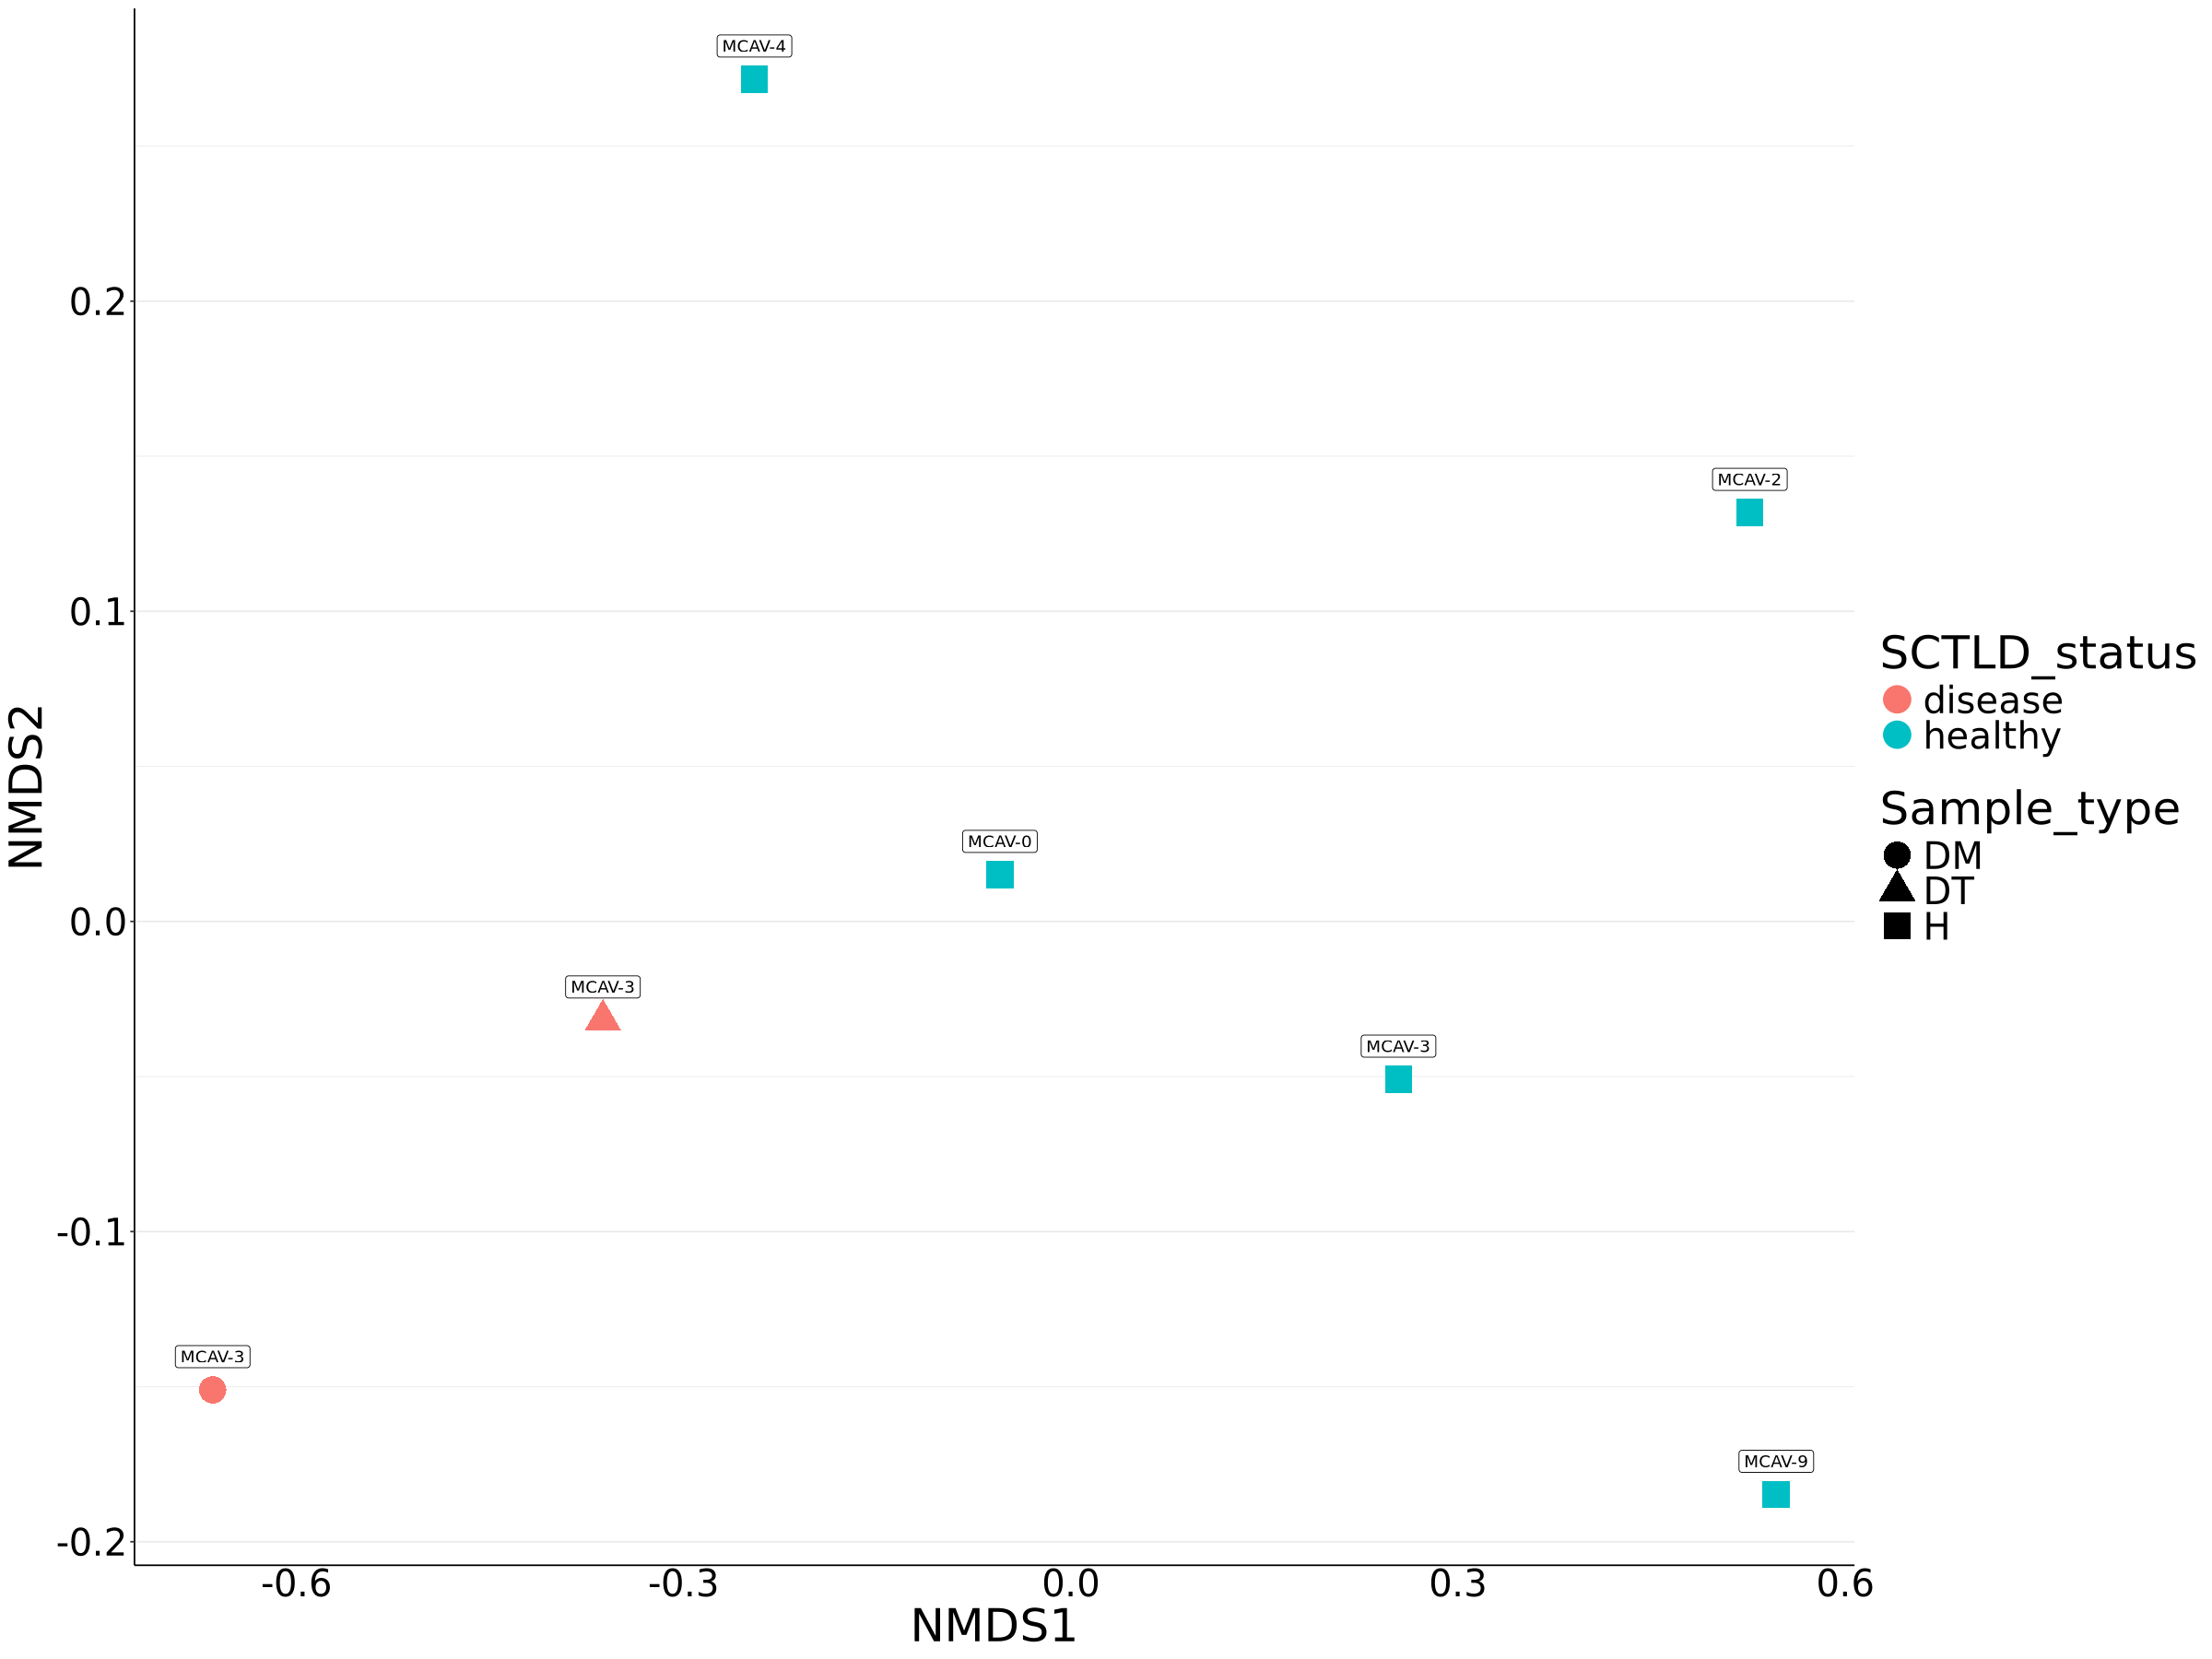

In [78]:
# visualize ordination plot
plot_ordination(DR_mcav, DR_mcav.ord, type="Samples", color="SCTLD_status", shape="Sample_type")+
geom_point(size=8)+
geom_label(aes(label = SAMP_M$Tag_num), vjust = -1, color = "black") +
theme_bw()+
 theme(legend.position="right", panel.border = element_blank(),
          panel.grid.major.x = element_blank(),
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(color="black"),
          text = element_text(size=30))

In [51]:
#run DESeq2 on mcav
ds_mcav = phyloseq_to_deseq2(DR_mcav, ~ SCTLD_status)
ds_mcav = DESeq(ds_mcav, test="Wald", fitType="parametric")
res = results(ds_mcav, cooksCutoff = FALSE)
alpha = 0.0001
sigtab = res[which(res$padj < alpha), ]
sigtab_mcav = cbind(as(sigtab, "data.frame"), as(tax_table(DR_mcav)[rownames(sigtab), ], "matrix"))
res
head(sigtab_mcav)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing



log2 fold change (MLE): SCTLD status healthy vs disease 
Wald test p-value: SCTLD status healthy vs disease 
DataFrame with 13490 rows and 6 columns
         baseMean log2FoldChange     lfcSE       stat    pvalue      padj
        <numeric>      <numeric> <numeric>  <numeric> <numeric> <numeric>
2066072  38001.36     -0.3678209  0.338236 -1.0874676  0.276830  0.715196
588596   20796.26      0.2245214  0.228493  0.9826201  0.325794  0.820176
562       7407.83     -0.0208798  0.287964 -0.0725083  0.942197  0.999989
5722      6066.81     -0.0208775  0.264777 -0.0788492  0.937153  0.999989
1280      5623.10     -0.0507102  0.201293 -0.2519224  0.801101  0.999989
...           ...            ...       ...        ...       ...       ...
2774776         0             NA        NA         NA        NA        NA
3378073         0             NA        NA         NA        NA        NA
2913501         0             NA        NA         NA        NA        NA
1967296         0             NA     

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
456999,2535.1468,4.802194,0.2416925,19.869022,7.545821e-88,5.275284e-84,Rhizoctonia solani
654,812.1445,1.971204,0.3709804,5.313498,1.075408e-07,9.281703e-06,Aeromonas veronii
2034170,1011.5967,-28.465023,3.9245113,-7.253138,4.072239e-13,2.588093e-10,Trichoderma breve
584,421.4557,11.408241,1.5273859,7.469128,8.072788e-14,7.054608e-11,Proteus mirabilis
2704462,516.0504,-13.364421,2.7121245,-4.927658,8.322127e-07,2.887537e-05,Paenibacillus lycopersici
28183,486.4441,-13.279087,1.0085806,-13.166114,1.374945e-39,4.806119e-36,Leptospira santarosai


In [59]:
# sort by most significant 
sorted_sigtab <- sigtab_mcav %>%
  arrange(padj)
sorted_sigtab

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
456999,2535.14683,4.802194,0.2416925,19.869022,7.545821e-88,5.275284e-84,Rhizoctonia solani
28183,486.44415,-13.279087,1.0085806,-13.166114,1.374945e-39,4.806119e-36,Leptospira santarosai
28090,343.86118,-12.778664,1.0543501,-12.119944,8.281528e-34,1.929872e-30,Acinetobacter lwoffii
2806443,309.20479,-12.625673,1.0692469,-11.808005,3.548810e-32,6.202433e-29,Turicibacter sp. TJ11
2932268,223.60674,-12.158139,1.2052878,-10.087333,6.285390e-24,8.788232e-21,Psychroserpens ponticola
196914,169.08129,-11.754755,1.4070005,-8.354478,6.572263e-17,7.657782e-14,Actinoplanes friuliensis
3402687,74.85588,-25.207641,3.2156462,-7.839059,4.539346e-15,4.533510e-12,Mucilaginibacter sp. NFX135
584,421.45569,11.408241,1.5273859,7.469128,8.072788e-14,7.054608e-11,Proteus mirabilis
2924034,68.41259,-25.064005,3.3762324,-7.423661,1.139263e-13,8.849540e-11,Alkalihalobacillus sp. LMS6


In [60]:
#include just the top 20 for now
sorted_sigtab20 <- head(sorted_sigtab, 20)
sorted_sigtab20

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
456999,2535.14683,4.802194,0.2416925,19.869022,7.545821e-88,5.275284e-84,Rhizoctonia solani
28183,486.44415,-13.279087,1.0085806,-13.166114,1.374945e-39,4.806119e-36,Leptospira santarosai
28090,343.86118,-12.778664,1.0543501,-12.119944,8.281528e-34,1.929872e-30,Acinetobacter lwoffii
2806443,309.20479,-12.625673,1.0692469,-11.808005,3.548810e-32,6.202433e-29,Turicibacter sp. TJ11
2932268,223.60674,-12.158139,1.2052878,-10.087333,6.285390e-24,8.788232e-21,Psychroserpens ponticola
196914,169.08129,-11.754755,1.4070005,-8.354478,6.572263e-17,7.657782e-14,Actinoplanes friuliensis
3402687,74.85588,-25.207641,3.2156462,-7.839059,4.539346e-15,4.533510e-12,Mucilaginibacter sp. NFX135
584,421.45569,11.408241,1.5273859,7.469128,8.072788e-14,7.054608e-11,Proteus mirabilis
2924034,68.41259,-25.064005,3.3762324,-7.423661,1.139263e-13,8.849540e-11,Alkalihalobacillus sp. LMS6


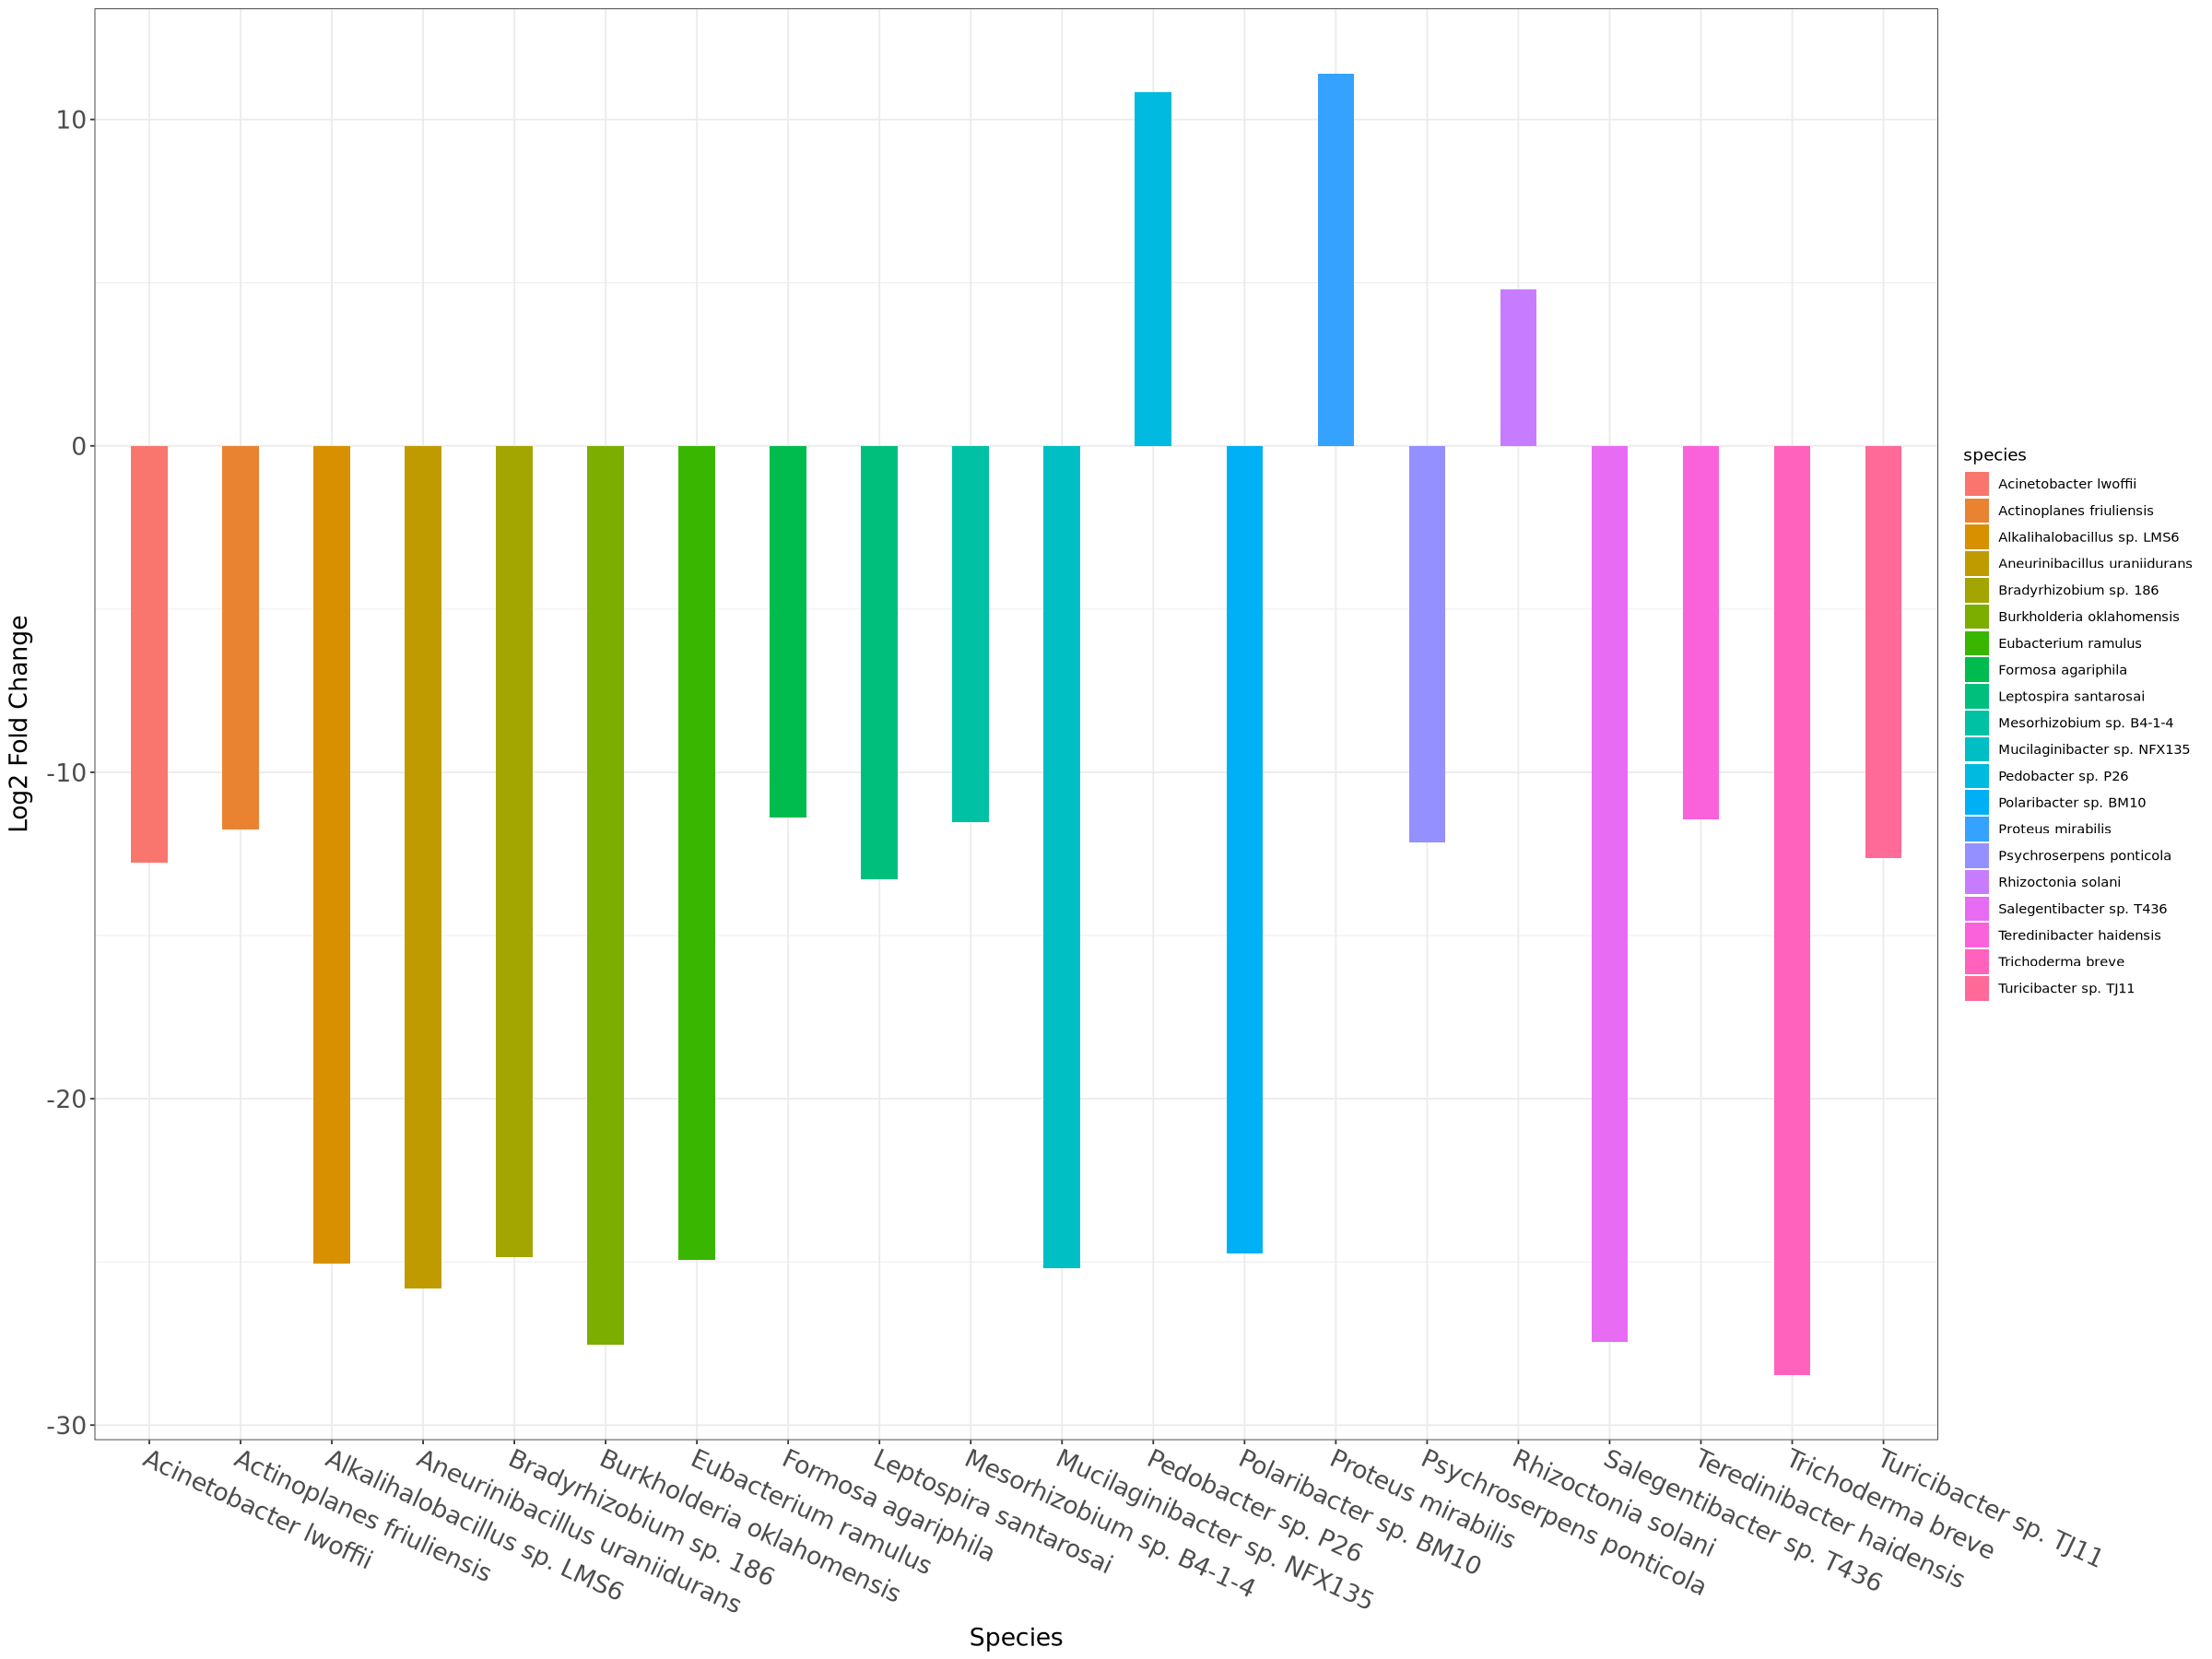

In [65]:
# plot significantly different OTUs top 20
ds_mcav <- ggplot(sorted_sigtab20, aes(x = species, y = log2FoldChange, fill = species)) +
  geom_bar(stat = "identity", width = 0.4) +
theme_bw()+
  theme(
    axis.text.x = element_text(angle = -25, hjust = 0, vjust = 1, size = 16),  # Adjust text size
    axis.text.y = element_text(size = 16),  # Adjust y-axis text size
    axis.title.x = element_text(size = 16, margin = margin(t = 5)),  # Adjust x-axis title size and margin
    axis.title.y = element_text(size = 16, margin = margin(r = 10)),   # Adjust y-axis title size and add margin
  ) +
  labs(x = "Species", y = "Log2 Fold Change")

ds_mcav

In [66]:
#include just the top 30 for now
sorted_sigtab30 <- head(sorted_sigtab, 30)
sorted_sigtab30

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
456999,2535.14683,4.802194,0.2416925,19.869022,7.545821e-88,5.275284e-84,Rhizoctonia solani
28183,486.44415,-13.279087,1.0085806,-13.166114,1.374945e-39,4.806119e-36,Leptospira santarosai
28090,343.86118,-12.778664,1.0543501,-12.119944,8.281528e-34,1.929872e-30,Acinetobacter lwoffii
2806443,309.20479,-12.625673,1.0692469,-11.808005,3.548810e-32,6.202433e-29,Turicibacter sp. TJ11
2932268,223.60674,-12.158139,1.2052878,-10.087333,6.285390e-24,8.788232e-21,Psychroserpens ponticola
196914,169.08129,-11.754755,1.4070005,-8.354478,6.572263e-17,7.657782e-14,Actinoplanes friuliensis
3402687,74.85588,-25.207641,3.2156462,-7.839059,4.539346e-15,4.533510e-12,Mucilaginibacter sp. NFX135
584,421.45569,11.408241,1.5273859,7.469128,8.072788e-14,7.054608e-11,Proteus mirabilis
2924034,68.41259,-25.064005,3.3762324,-7.423661,1.139263e-13,8.849540e-11,Alkalihalobacillus sp. LMS6


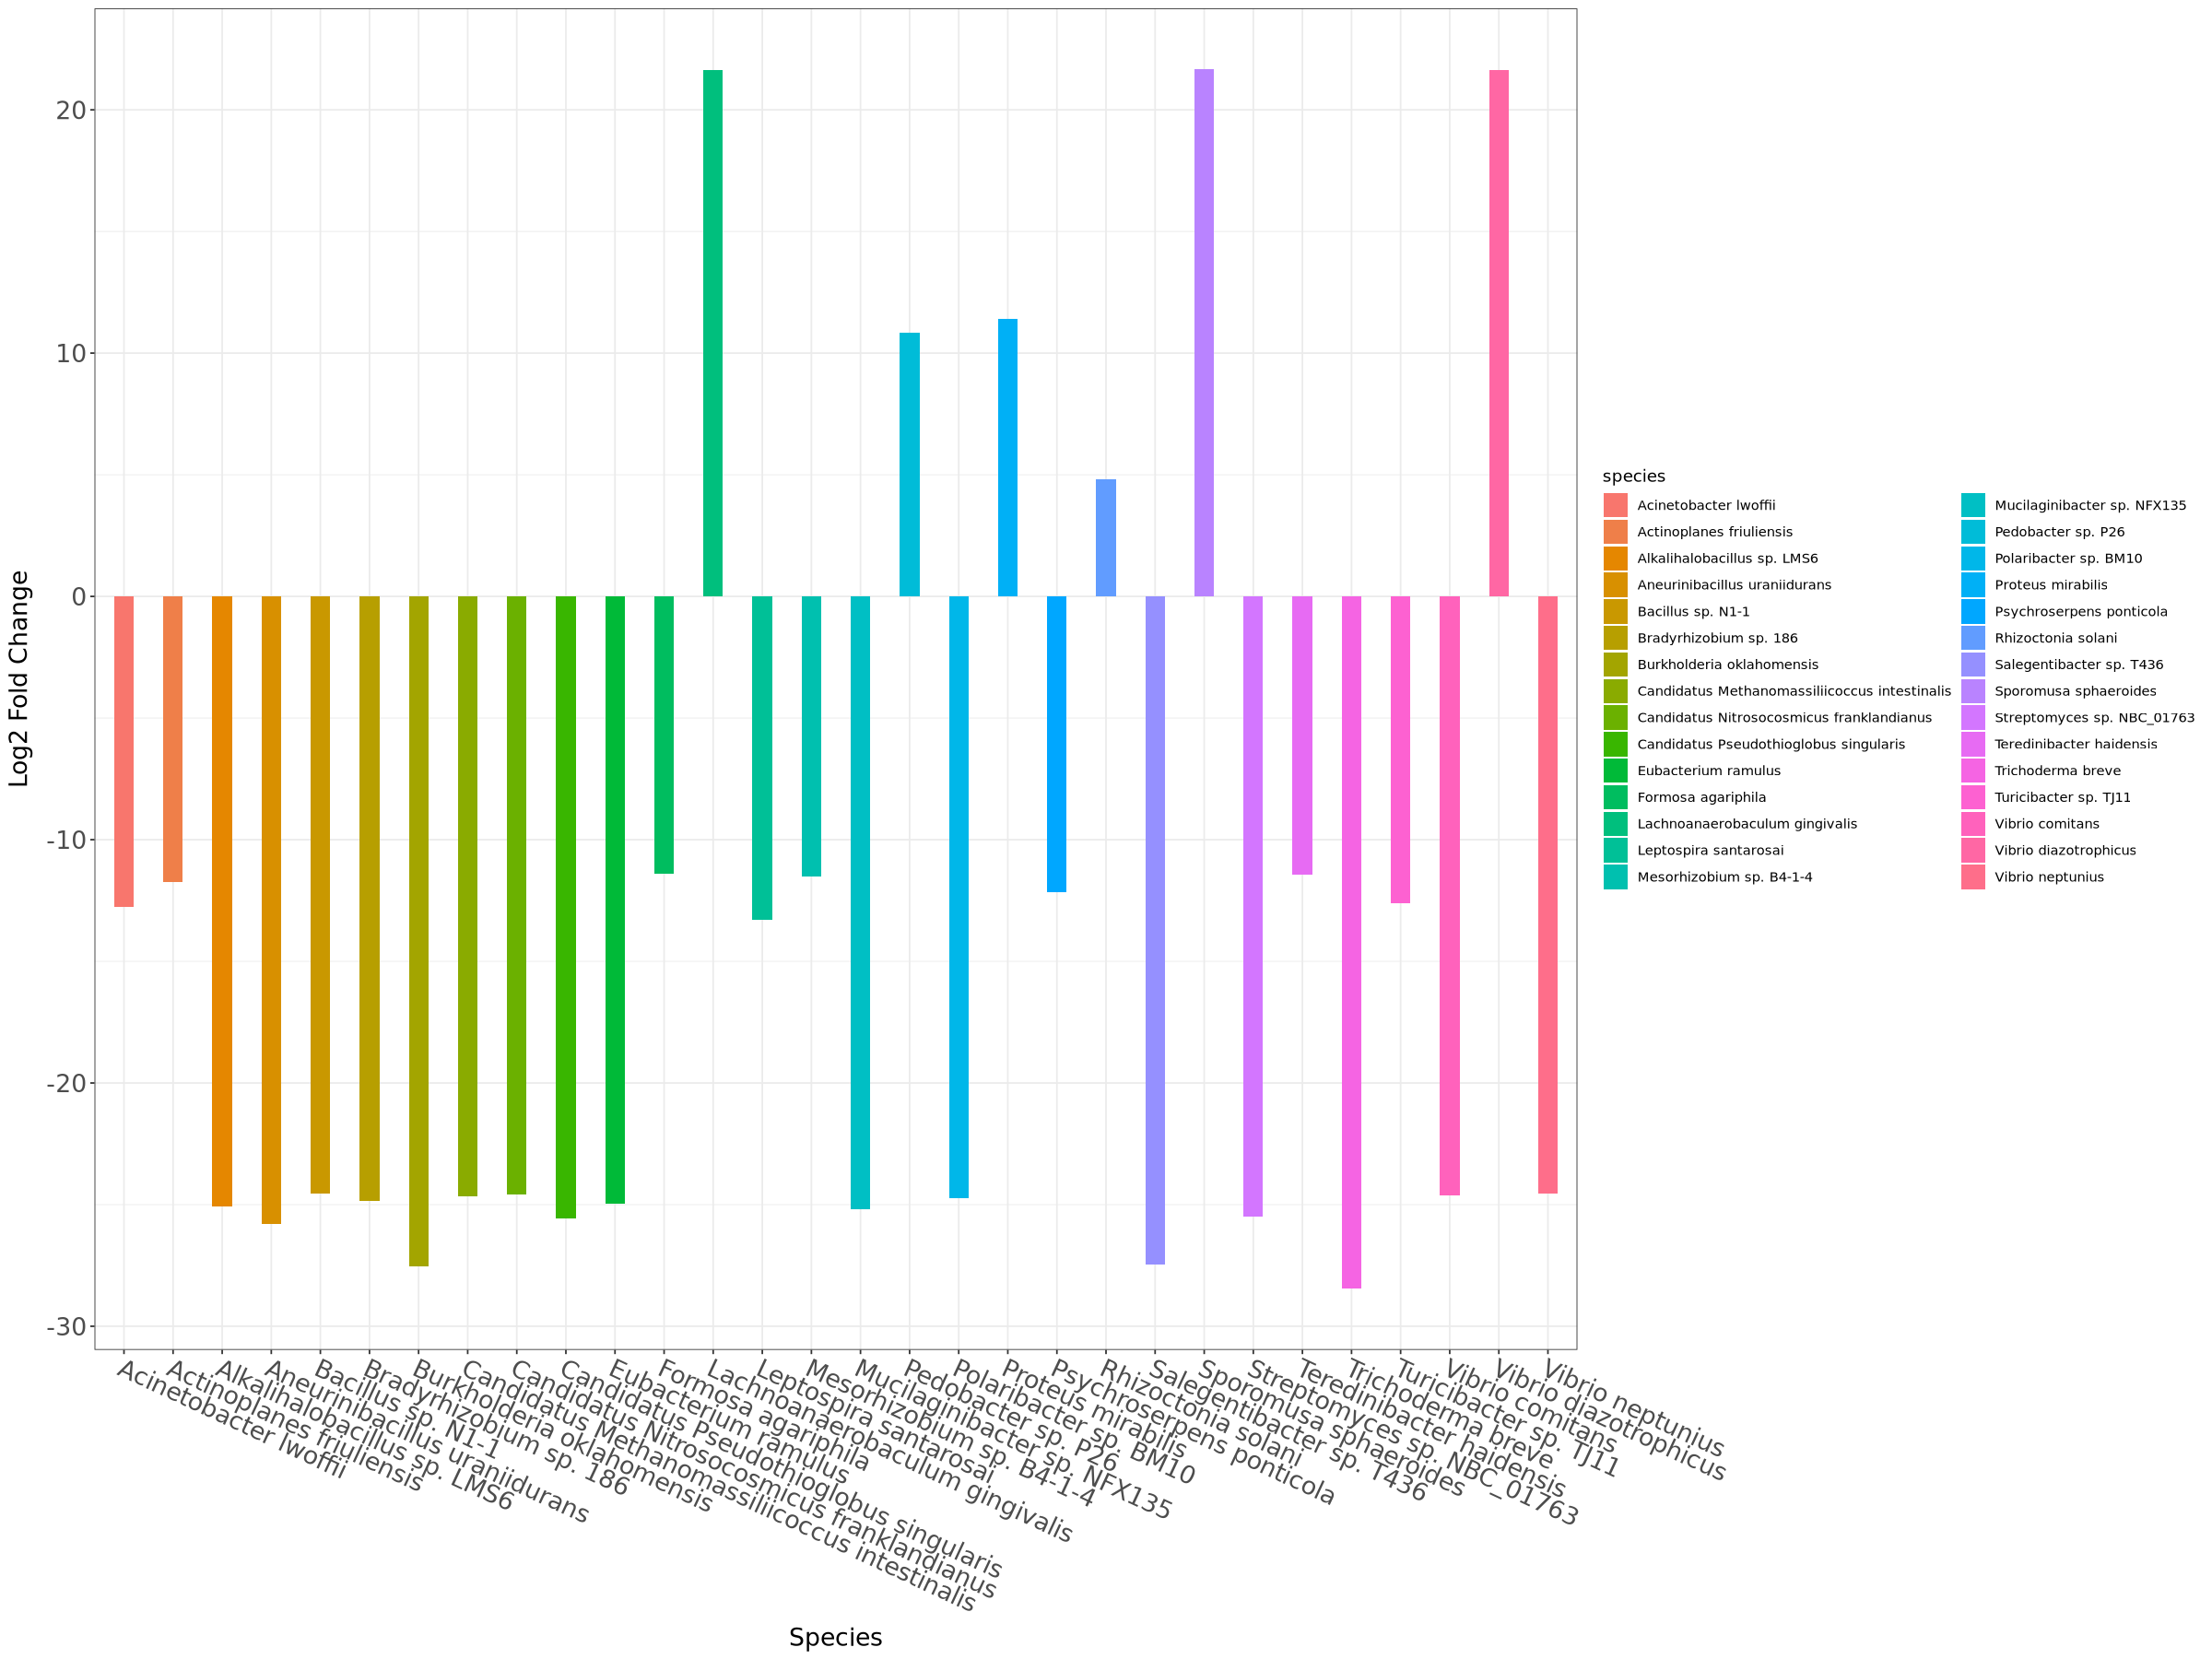

In [67]:
# plot significantly different OTUs top 30
ds_mcav_30 <- ggplot(sorted_sigtab30, aes(x = species, y = log2FoldChange, fill = species)) +
  geom_bar(stat = "identity", width = 0.4) +
theme_bw()+
  theme(
    axis.text.x = element_text(angle = -25, hjust = 0, vjust = 1, size = 16),  # Adjust text size
    axis.text.y = element_text(size = 16),  # Adjust y-axis text size
    axis.title.x = element_text(size = 16, margin = margin(t = 5)),  # Adjust x-axis title size and margin
    axis.title.y = element_text(size = 16, margin = margin(r = 10)),   # Adjust y-axis title size and add margin
  ) +
  labs(x = "Species", y = "Log2 Fold Change")

ds_mcav_30

In [71]:
# subset taxa that are assoc with healthy
healthy_mcav_otu<-sorted_sigtab[sorted_sigtab$log2FoldChange>0,]
healthy_mcav_otu

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
456999,2535.14683,4.802194,0.2416925,19.869022,7.545821e-88,5.275284e-84,Rhizoctonia solani
584,421.45569,11.408241,1.5273859,7.469128,8.072788e-14,7.054608e-11,Proteus mirabilis
3423956,282.19532,10.829433,1.5691897,6.901290,5.153243e-12,2.251645e-09,Pedobacter sp. P26
47679,73.53401,21.661404,3.5825332,6.046393,1.481244e-09,3.698350e-07,Sporomusa sphaeroides
685,72.68488,21.645287,3.6006770,6.011449,1.838721e-09,4.432586e-07,Vibrio diazotrophicus
2490855,71.97654,21.632330,3.6159531,5.982470,2.197791e-09,5.121587e-07,Lachnoanaerobaculum gingivalis
1211326,71.33096,21.615639,3.6245179,5.963728,2.465468e-09,5.560029e-07,Spirosoma aerolatum
3077937,69.40902,21.584884,3.6528147,5.909110,3.439612e-09,7.514477e-07,Rickettsiella endosymbiont of Rhagonycha lignosa
251701,69.13542,21.571363,3.6661287,5.883962,4.005592e-09,8.485786e-07,Pseudomonas syringae group genomosp. 3


In [70]:
# subset taxa that are assoc with disease
disease_mcav_otu<-sorted_sigtab[sorted_sigtab$log2FoldChange<0,]
disease_mcav_otu

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
28183,486.44415,-13.27909,1.008581,-13.166114,1.374945e-39,4.806119e-36,Leptospira santarosai
28090,343.86118,-12.77866,1.054350,-12.119944,8.281528e-34,1.929872e-30,Acinetobacter lwoffii
2806443,309.20479,-12.62567,1.069247,-11.808005,3.548810e-32,6.202433e-29,Turicibacter sp. TJ11
2932268,223.60674,-12.15814,1.205288,-10.087333,6.285390e-24,8.788232e-21,Psychroserpens ponticola
196914,169.08129,-11.75475,1.407000,-8.354478,6.572263e-17,7.657782e-14,Actinoplanes friuliensis
3402687,74.85588,-25.20764,3.215646,-7.839059,4.539346e-15,4.533510e-12,Mucilaginibacter sp. NFX135
2924034,68.41259,-25.06401,3.376232,-7.423661,1.139263e-13,8.849540e-11,Alkalihalobacillus sp. LMS6
2589888,143.80086,-11.52107,1.583213,-7.277017,3.412832e-13,2.385911e-10,Mesorhizobium sp. B4-1-4
2034170,1011.59670,-28.46502,3.924511,-7.253138,4.072239e-13,2.588093e-10,Trichoderma breve


In [72]:
endo_search <- sorted_sigtab[grepl("Endozoicomonas", sorted_sigtab$species), ]
endo_search

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2872754,13.69932,19.32814,4.038746,4.785678,1.704108e-06,3.599219e-05,Endozoicomonas sp. 4G


In [73]:
pseudo_search <- sorted_sigtab[grepl("Pseudoalteromonas", sorted_sigtab$species), ]
pseudo_search

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
28107,44.74674,20.97150,4.081214,5.138545,2.768736e-07,1.433795e-05,Pseudoalteromonas espejiana
28109,15.42464,19.49318,4.019456,4.849705,1.236450e-06,2.900678e-05,Pseudoalteromonas nigrifaciens
2907156,13.43929,18.70593,4.046588,4.622642,3.788827e-06,6.572627e-05,Pseudoalteromonas sp. N1230-9


In [75]:
vibrio_search <- sorted_sigtab[grepl("Vibrio", sorted_sigtab$species), ]
vibrio_search

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
413401,48.70370,-24.62073,3.802484,-6.474908,9.486944e-11,2.763468e-08,Vibrio comitans
170651,45.86107,-24.54374,3.827452,-6.412553,1.431029e-10,3.705306e-08,Vibrio neptunius
685,72.68488,21.64529,3.600677,6.011449,1.838721e-09,4.432586e-07,Vibrio diazotrophicus
2912314,51.46638,21.16644,4.081114,5.186436,2.143569e-07,1.198855e-05,Vibrio sp. JC009
3232307,44.74674,20.97150,4.081214,5.138545,2.768736e-07,1.433795e-05,Vibrio sp. HB236076
446372,35.43086,20.64311,4.081414,5.057833,4.240482e-07,1.989611e-05,Vibrio celticus
2819096,85.38113,20.35577,4.080851,4.988118,6.097027e-07,2.680774e-05,Vibrio sp. SCSIO 43135
3098914,25.19916,20.17505,4.081804,4.942680,7.705576e-07,2.887537e-05,Vibrio iocasae
664643,22.48011,20.01476,4.081968,4.903212,9.428204e-07,2.887537e-05,Vibrio plantisponsor


### Try running Lefse on this phyloseq object
https://rdrr.io/github/yiluheihei/microbiomeMarker/man/run_lefse.html

In [ ]:
#get other libraries loaded


#install this package
install.packages("remotes")
remotes::install_github("yiluheihei/microbiomeMarker")

maybe filter the asv table a bit more for taxa, to keep in mind:
https://david-barnett.github.io/microViz/reference/tax_filter.html